In [ ]:
!pip install geoviews
!pip install movingpandas
!pip install hvplot
!pip install osmnx
!pip install contextily
!pip install matplotlib-scalebar
!pip install esda
!pip install libpysal
!pip install osmnx --quiet
!pip install h3==3.7.6
import os
import pandas as pd
from glob import glob
import geopandas as gpd
from shapely.geometry import MultiPolygon, Polygon
from collections import defaultdict
from pathlib import Path
from google.colab import drive
import time
import warnings
import shutil
import numpy as np
import h3
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patches as mpatches
from shapely.geometry import Point
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree
from pyproj import Transformer
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString, Point
from shapely.ops import linemerge
from tqdm import tqdm
from matplotlib.lines import Line2D
from scipy.stats import entropy as shannon_entropy
from libpysal.weights import Queen
from esda.moran import Moran
from shapely.geometry import MultiLineString
import textwrap
import math
import random
from math import radians, cos, sin, sqrt, atan2
from matplotlib.ticker import FuncFormatter
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import ast


print("CUDA Available:", torch.cuda.is_available())

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Thesis/'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.7/548.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


CUDA Available: False
Mounted at /content/drive


## Processing Locomizer Raw Data

### Mobility Data


To facilitate more efficient analysis, I first consolidated the daily mobility data into three separate monthly datasets for July, August, and September. These were then merged into a single file named combined_human_mobility.csv. This unified dataset contains timestamped GPS coordinates (latitude and longitude) for each user, providing the foundation for subsequent analyses such as next-location prediction. The corresponding section of code is designed to automate the merging of the individual monthly CSV files into this comprehensive output file.

In [ ]:


base_folder = "/content/drive/My Drive/Thesis/Data/Human Mobility/Tabular Data"
output_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/combined_human_mobility.csv"
first_file = True
for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path)
                df.to_csv(output_file, mode='a', index=False, header=first_file)
                first_file = False
            except Exception as e:
                print(f"Failed to process {file_path}: {e}")

#(OpenAI, 2025ag)

✅ All CSVs appended to: /content/drive/My Drive/Thesis/Data/Human Mobility/combined_human_mobility.csv


### Affinity Score

This code follows the same logic as the previous section, but is applied to the monthly affinity datasets. These datasets contain affinity scores for each user, indicating their level of engagement with specific categories of amenities such as restaurants, museums, and other points of interest. The code merges the monthly affinity data from July, August, and September into a single dataset that captures users’ overall affinity scores across the entire period.

In [ ]:


base_dir = "/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data"
month_folders = {
    "July": "scores 7",
    "August": "scores 8",
    "September": "scores 9"
}

output_dir = base_dir
os.makedirs(output_dir, exist_ok=True)

def read_csvs_in_chunks(file_paths):
    chunks = []
    for path in file_paths:
        try:
            for chunk in pd.read_csv(path, chunksize=100_000):
                chunks.append(chunk)
        except Exception as e:
            print(f"Error reading {path}: {e}")
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

monthly_dfs = {}
for month, folder in month_folders.items():
    folder_path = os.path.join(base_dir, folder)
    all_csvs = glob(os.path.join(folder_path, "*.csv"))
    monthly_df = read_csvs_in_chunks(all_csvs)
    monthly_dfs[month] = monthly_df
    out_path = os.path.join(output_dir, f"scores_{month.lower()}.csv")
    monthly_df.to_csv(out_path, index=False)

#(OpenAI, 2025ai)

### POI

This code serves a similar purpose to the previous sections, aiming to combine the Points of Interest (POI) data that appear in each monthly dataset. The Locomizer data consists of two files: one containing micodes and another containing brand information. In this analysis, the micodes file was used, as it provides a more detailed classification of POIs. Following the same approach as with the mobility and affinity data, all monthly POI files were merged into a single dataset named Combined_POIs_for_JCD_Finland_(micodes).csv.

In [ ]:



base_dir = "/content/drive/My Drive/Thesis/Data/POI"
output_dir = os.path.join(base_dir, "Combined_POI")
os.makedirs(output_dir, exist_ok=True)
months = ["POIs_2024-07", "POIs_2024-08", "POIs_2024-09"]
file_types = ["micodes", "brands"]
file_prefix = "POIs_for_JCD_Finland_"

for ftype in file_types:
    combined_df = pd.DataFrame()
    for month in months:
        file_path = os.path.join(base_dir, month, f"{file_prefix}({ftype}).csv")
        if os.path.exists(file_path):
            try:
                df = pd.read_csv(file_path, delimiter='\t', engine='python')
                combined_df = pd.concat([combined_df, df], ignore_index=True)
                print(f"Loaded: {file_path}")
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
        else:
            print(f"File not found: {file_path}")

    output_file = os.path.join(output_dir, f"Combined_{file_prefix}({ftype}).csv")
    combined_df.to_csv(output_file, index=False)
    print(f"Saved combined file to: {output_file}")

#(OpenAI, 2025z)

✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-07/POIs_for_JCD_Finland_(micodes).csv
✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-08/POIs_for_JCD_Finland_(micodes).csv
✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-09/POIs_for_JCD_Finland_(micodes).csv
💾 Saved combined file to: /content/drive/My Drive/Thesis/Data/POI/Combined_POI/Combined_POIs_for_JCD_Finland_(micodes).csv
✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-07/POIs_for_JCD_Finland_(brands).csv
✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-08/POIs_for_JCD_Finland_(brands).csv
✅ Loaded: /content/drive/My Drive/Thesis/Data/POI/POIs_2024-09/POIs_for_JCD_Finland_(brands).csv
💾 Saved combined file to: /content/drive/My Drive/Thesis/Data/POI/Combined_POI/Combined_POIs_for_JCD_Finland_(brands).csv


## Loading Data

### Socioeconomic Data


This section of the code is designed to merge spatial and tabular socioeconomic data in order to map income levels across postal code areas in Helsinki and classify each area into simplified economic categories for subsequent analysis.

The process begins by importing a CSV file containing median income data for residents across Finnish postal code areas. Median income is used as the primary metric to distinguish between economically disadvantaged ("poor") and more affluent ("rich") neighbourhoods. In Finland, poverty is typically assessed in relative terms, in line with the at-risk-of-poverty (AROP) framework. Under this framework, the poverty threshold is set at 60 percent of the national yearly median disposable household income, meaning that a household is considered at risk of poverty if its net income falls below this level (Järvinen and Saarinen, 2021).

Based on supplementary data from Statistics Finland (2024), the threshold of 60 percent corresponds to an annual disposable household income of €30,000. This threshold is used to classify both postal code areas and individual users. Areas where the median income falls below €30,000 are labelled as "Below Median Income", while those above are classified as "Above Median Income". It is important to acknowledge the limitations of this area-level approach, as it may introduce ecological fallacies. Not all individuals in lower-income areas are necessarily poor and not all individuals in higher-income areas are affluent.

This classification will be used in later stages of the study to analyse spatial patterns of socioeconomic segregation in Helsinki. It will also serve as an input feature in the development of next-location prediction models that incorporate segregation-aware metrics.

In [ ]:


socioeconomic_data = pd.read_csv("/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Finland Income of Inhabitants.csv", encoding='ISO-8859-1')
helsinki_shp = gpd.read_file("/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Shapefile/PKS_postinumeroalueet_2023_manner_shp.shp")
socioeconomic_data["Code"] = socioeconomic_data["Code"].astype(str)
helsinki_shp["Posno"] = helsinki_shp["Posno"].astype(str).str.replace(r"^0{1,2}", "", regex=True)

merged_data = pd.merge(socioeconomic_data, helsinki_shp, left_on="Code", right_on="Posno")
merged_data = gpd.GeoDataFrame(merged_data, geometry="geometry", crs=helsinki_shp.crs)
merged_data["geometry"] = merged_data["geometry"].apply(
    lambda geom: MultiPolygon([geom]) if isinstance(geom, Polygon) else geom
)

merged_data["Median income of inhabitants (HR)"] = pd.to_numeric(
    merged_data["Median income of inhabitants (HR)"], errors="coerce"
).fillna(0)

merged_data["Economic Category"] = merged_data["Median income of inhabitants (HR)"].apply(
    lambda x: "Poor" if x < 30000 else "Rich"
)
merged_data

#(OpenAI, 2025o)

,Code,Detailed Code,"Aged 18 or over, total (HR)",Average income of inhabitants (HR),Median income of inhabitants (HR),Inhabitants belonging to the lowest income category (HR),Inhabitants belonging to the middle income category (HR),Inhabitants belonging to the highest income category (HR),Accumulated purchasing power of inhabitants (HR),Posno,Toimip,Toimip_ru,Nimi,Nimi_Ru,Kunta,Kunta_nro,geometry,Economic Category
0,100,00100 Helsinki keskusta - Etu-Töölö (Helsinki),16365,46001,32509,2871,6730,6764,752810418,100,HELSINKI,HELSINGFORS,Helsinki Keskusta - Etu-Töölö,Helsingfors centrum - Främre Tölö,Helsinki,091,"MULTIPOLYGON (((25494852.004 6673751.321, 2549...",Rich
1,120,00120 Punavuori - Bulevardi (Helsinki),6219,55463,33557,1056,2423,2740,344922291,120,HELSINKI,HELSINGFORS,Punavuori,Rödbergen,Helsinki,091,"MULTIPOLYGON (((25495938.931 6671969.614, 2549...",Rich
2,130,00130 Kaartinkaupunki (Helsinki),1467,73745,35917,270,490,707,108183289,130,HELSINKI,HELSINGFORS,Kaartinkaupunki,Gardesstaden,Helsinki,091,"MULTIPOLYGON (((25497686.744 6672111.924, 2549...",Rich
3,140,00140 Kaivopuisto - Ullanlinna (Helsinki),6590,74178,34775,1101,2457,3032,488833803,140,HELSINKI,HELSINGFORS,Kaivopuisto - Ullanlinna,Brunnsparken - Ulrikasborg,Helsinki,091,"MULTIPOLYGON (((25498208.112 6670802.701, 2549...",Rich
4,150,00150 Punavuori - Eira - Hernesaari (Helsinki),8402,48256,31790,1437,3625,3340,405444212,150,HELSINKI,HELSINGFORS,Eira - Hernesaari,Eira - Ärtholmen,Helsinki,091,"MULTIPOLYGON (((25496919.993 6671049.6, 254969...",Rich
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2940,02940 Lippajärvi-Järvenperä (Espoo),8449,35555,31130,1280,4244,2925,300403808,2940,ESPOO,ESBO,Lippajärvi-Järvenperä,Klappträsk-Träskända,Espoo,049,"MULTIPOLYGON (((25485566.07 6680208.06, 254855...",Rich
168,2970,02970 Kalajärvi (Espoo),2777,36056,32630,399,1318,1060,100126380,2970,ESPOO,ESBO,Kalajärvi,Kalajärvi,Espoo,049,"MULTIPOLYGON (((25486502.58 6690226.845, 25486...",Rich
169,2980,02980 Lakisto (Espoo),203,28644,25386,38,123,42,5814714,2980,ESPOO,ESBO,Lakisto,Lakisto,Espoo,049,"MULTIPOLYGON (((25480218.12 6688342.2, 2548019...",Poor
170,4260,04260 Savio (Kerava),5260,28959,27358,861,3280,1119,152325783,4260,KERAVA,KERVO,Savio,Savio,Vantaa,092,"MULTIPOLYGON (((25504160.49 6695316.135, 25504...",Poor


### Parametric Score (Home-location data)



This section of the code is responsible for combining users' home location data from July, August, and September. The logic for identifying home locations relies on a parametric scoring system, which assigns weights to user signals based on the time of day. All location signals are first time-zone adjusted and spatially assigned to hexagonal grid cells. Each signal is then given a weight according to the hour in which it was recorded. Signals recorded between 00:00 and 01:59 are assigned a weight of 2.0, those between 02:00 and 03:59 receive a weight of 3.0, while signals from 04:00 to 05:59 are weighted at 2.0. Signals between 06:00 and 06:59, as well as those from 23:00 to 23:59, are assigned a weight of 1.0. For each user, the residential score of a given hexagon is calculated as the sum of all signal weights occurring within that hexagon over the course of a month. The hexagon with the highest cumulative score is then designated as the user’s inferred home location (Locomizer, 2025).

Once all monthly files have been read, the code checks whether any data was successfully loaded. If so, it merges the data into a single DataFrame and exports the results as combined_parametric_score.csv, which will be used in subsequent stages of analysis.

In [ ]:


base_dir = "/content/drive/My Drive/Thesis/Data/PARAMETRIC SCORE"
source = "loco_residents"
months = ["07", "08", "09"]

all_file_paths = []
for month in months:
    folder_path = os.path.join(base_dir, source, month)
    files = glob(os.path.join(folder_path, "part-*"))
    all_file_paths.extend(files)

print(f"Found {len(all_file_paths)} files from '{source}'.")

combined_chunks = []
for file_path in all_file_paths:
    try:
        df = pd.read_csv(file_path, sep="\t", header=None, names=["user_id", "h3_index"])
        combined_chunks.append(df)
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")

if combined_chunks:
    combined_df = pd.concat(combined_chunks, ignore_index=True)
    out_path = os.path.join(base_dir, "combined_parametric_score.csv")
    combined_df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}, shape: {combined_df.shape}")
else:
    print("No valid data was loaded.")

#(OpenAI, 2025w)

🔍 Found 3 files from 'loco_residents'.
✅ Saved to /content/drive/My Drive/Thesis/Data/PARAMETRIC SCORE/combined_parametric_score.csv, shape: (558174, 2)


### Visitor Data

This section of the code is used to combine monthly visitor data, originally stored as tab-separated text files, into a single consolidated CSV file. The raw data is organised within a VISITORS directory, which contains subfolders for each month (07, 08, and 09), corresponding to July, August, and September respectively.

Visitor classification is based on a rule-based algorithm with the following parameters. A minimum interval of five consecutive days is required between visits. Only visits that occur within the 30 days preceding the user's last recorded signal are considered. A maximum stay of five consecutive days is permitted for an event to qualify as a visit. A user is classified as a visitor if they have made at least one such visit (Locomizer, 2025).

This classification logic is consistent with prior research. For example, Lin et al. (2023), in a study of visitor mobility patterns in Jeju, found that most visitors stayed fewer than five days. They also noted that nearly all visitors could be identified within a two-week observational window. These findings support the parameters used in this study and affirm their applicability to short-term mobility analysis.

In [ ]:


base_dir = "/content/drive/My Drive/Thesis/Data/VISITORS"
months = ["07", "08", "09"]

all_file_paths = []
for month in months:
        folder_path = os.path.join(base_dir, month)
        files = glob(os.path.join(folder_path, "part-*"))
        all_file_paths.extend(files)

print(f"Found {len(all_file_paths)} files.")

combined_chunks = []
for file_path in all_file_paths:
    try:
        df = pd.read_csv(file_path, sep="\t", header=None, names=["user_id"])
        combined_chunks.append(df)
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")

if combined_chunks:
    combined_df = pd.concat(combined_chunks, ignore_index=True)
    out_path = os.path.join(base_dir, "combined_visitor.csv")
    combined_df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}, shape: {combined_df.shape}")
else:
    print("No valid data was loaded.")

#(OpenAI, 2025w)

### Mobility Data

This code is part of a broader data cleaning and filtering process designed to identify a high-quality subset of local users with consistent daily mobility records in Helsinki during July, August, and September. The primary objective is to exclude transient visitors and retain only habitual residents whose movement patterns can be meaningfully analysed for spatial behaviour, socio-economic inference, or trajectory-based modelling. The final output is a list of user IDs that meet the criterion of having at least 20 distinct days of recorded mobility data in each of the three months. This threshold ensures both temporal consistency and adequate data coverage.

The process begins by loading a pre-merged human mobility dataset that includes geographic coordinates, timestamps, and basic temporal features. In parallel, a separate list of known visitor user IDs is imported and stored as a set to allow efficient filtering. These visitor IDs are used to exclude short-term or non-residential users, thereby maintaining analytical focus on long-term local behaviour. Each user’s mobility point is then spatially joined with a shapefile representing the administrative boundaries of Helsinki. This spatial filter ensures that only users located within the target study area are retained for further analysis. By the end of the process, the final output file,contains a curated dataset of geolocated user movements from local residents with sustained activity across all three months

In [ ]:


input_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/combined_human_mobility.csv"
required_cols = ["Userid", "lat", "lon", "timestamp", "datetime", "year", "month", "dow", "day", "hour", "minute", "track_type"]
visitors_data = pd.read_csv("/content/drive/My Drive/Thesis/Data/VISITORS/combined_visitor.csv")
visitor_ids = set(visitors_data["user_id"])

merged_data = merged_data.to_crs(epsg=4326)
user_days_by_month = defaultdict(lambda: defaultdict(set))

for chunk in pd.read_csv(input_file, usecols=required_cols, chunksize=100_000):
    chunk = chunk.dropna(subset=required_cols)
    chunk = chunk[~chunk["Userid"].isin(visitor_ids)].copy()
    chunk["geometry"] = gpd.points_from_xy(chunk["lon"], chunk["lat"])
    chunk_gdf = gpd.GeoDataFrame(chunk, geometry="geometry", crs="EPSG:4326")
    chunk_gdf = gpd.sjoin(chunk_gdf, merged_data[["geometry"]], how="inner", predicate="within").drop(columns="index_right")
    for row in chunk_gdf.itertuples(index=False):
        user_days_by_month[row.Userid][row.month].add(row.day)

valid_userids = {
    user for user, month_days in user_days_by_month.items()
    if all(month in month_days and len(month_days[month]) >= 20 for month in [7, 8, 9])
}
print(f"Valid users with ≥20 days in each month (excluding visitors): {len(valid_userids)}")


valid_user_df = pd.DataFrame({"user_id": list(valid_userids)})
output_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/user_20days.csv"
valid_user_df.to_csv(output_path, index=False)

print(f"Saved valid user IDs to: {output_path}")

# (OpenAI, 2025m)

In [ ]:



input_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/combined_human_mobility.csv"
shapefile_path = "/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Shapefile/PKS_postinumeroalueet_2023_manner_shp.shp"
valid_users_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/user_20days.csv"
visitors_file = "/content/drive/My Drive/Thesis/Data/VISITORS/combined_visitor.csv"
output_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/filtered_mobility_data_20days.csv"
required_cols = ["Userid", "lat", "lon", "timestamp", "datetime", "year", "month", "dow", "day", "hour", "minute", "track_type"]


valid_userids = set(pd.read_csv(valid_users_file)["user_id"])
visitor_ids = set(pd.read_csv(visitors_file)["user_id"])
merged_data = gpd.read_file(shapefile_path)
merged_data = merged_data.to_crs(epsg=4326)

if os.path.exists(output_file):
    os.remove(output_file)
first_chunk = True

for i, chunk in enumerate(pd.read_csv(input_file, usecols=required_cols, chunksize=50_000)):
    chunk = chunk.dropna(subset=required_cols)
    chunk = chunk[~chunk["Userid"].isin(visitor_ids)]
    chunk = chunk[chunk["Userid"].isin(valid_userids)]

    if chunk.empty:
        continue

    chunk["geometry"] = gpd.points_from_xy(chunk["lon"], chunk["lat"])
    chunk_gdf = gpd.GeoDataFrame(chunk, geometry="geometry", crs="EPSG:4326")
    chunk_gdf = gpd.sjoin(chunk_gdf, merged_data[["geometry"]], how="inner", predicate="within").drop(columns="index_right")

    if chunk_gdf.empty:
        continue

    chunk_gdf.to_csv(output_file, index=False, mode='a', header=first_chunk)
    first_chunk = False

print(f"Filtered data saved to: {output_file}")

#(OpenAI, 2025c)


/tmp/ipython-input-4-2471522297.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["geometry"] = gpd.points_from_xy(chunk["lon"], chunk["lat"])
/tmp/ipython-input-4-2471522297.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["geometry"] = gpd.points_from_xy(chunk["lon"], chunk["lat"])
/tmp/ipython-input-4-2471522297.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t


📁 Done. Filtered data saved to: /content/drive/My Drive/Thesis/Data/Human Mobility/filtered_mobility_data_20days.csv


## Affinity Data

### Affinity Data (June)

This code is part of a data preparation pipeline focused on compiling and standardizing affinity profiling scores for users, specifically for the month of June.

In [ ]:


drive.mount('/content/drive')
root_dir = Path("/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data/profiling")
output_file = "/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data/scores_june.csv"

if os.path.exists(output_file):
    os.remove(output_file)

base_cols = ['userid', 'cat_id', 'number_of_signals', 'sum_scores']
score_cols = [f'score_{i}' for i in range(1, 21)]
expected_cols = base_cols + score_cols

all_dfs = []

for i in range(10):
    scores_dir = root_dir / str(i) / "scores"
    if not scores_dir.exists():
        continue

    for file in scores_dir.glob("part-*"):
        try:
            df = pd.read_csv(file, sep="\t", header=None, names=["cat_id", "userid", "sum_scores"])
            df['number_of_signals'] = 0
            for col in score_cols:
                df[col] = pd.NA
            df = df[expected_cols]
            all_dfs.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df.to_csv(output_file, index=False)
    print(f"Combined and padded June file saved to: {output_file}")
else:
    print("No data found.")

#(OpenAI, 2025t)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Combined and padded June file saved to: /content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data/scores_june.csv


### Overall Affinity Data

This code is designed to compile and filter monthly user affinity score data into a single unified dataset spanning June to September.

In [ ]:


warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
base_dir = "/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data"
output_file = os.path.join(base_dir, "scores_all_months.csv")
output_file_local = "/content/scores_all_months.csv"

input_files = {
    "scores_june.csv": 6,
    "scores_july.csv": 7,
    "scores_august.csv": 8,
    "scores_september.csv": 9
}

if os.path.exists(output_file_local):
    os.remove(output_file_local)

first_chunk = True

with open(output_file_local, 'a') as f_out:
    for file_name, month in input_files.items():
        file_path = os.path.join(base_dir, file_name)
        print(f"\nChecking: {file_path}")

        if not os.path.exists(file_path):
            print(f"File not found: {file_name}")
            continue

        try:
            chunk_iterator = pd.read_csv(file_path, chunksize=100_000)
            print(f"Loaded: {file_name}")
        except Exception as e:
            print(f"Failed to read {file_name}: {e}")
            continue

        for i, chunk in enumerate(chunk_iterator):
            try:
                chunk = chunk[(chunk['cat_id'] >= 101) & (chunk['cat_id'] <= 115)]

                if chunk.empty:
                    print(f"Empty chunk #{i} from {file_name}")
                    continue

                chunk.loc[:, 'month'] = month

                chunk.to_csv(f_out, index=False, header=first_chunk)
                first_chunk = False
            except Exception as e:
                print(f"Failed to process chunk #{i} from {file_name}: {e}")

os.makedirs(os.path.dirname(output_file), exist_ok=True)
try:
    shutil.copy(output_file_local, output_file)
    print(f"Final CSV copied to: {output_file}")
    os.remove(output_file_local)
    print("Local temp file deleted")
except Exception as e:
    print(f"Failed to copy to Drive: {e}")

#(OpenAI, 2025d)


Checking: /content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data/scores_june.csv
✅ Loaded: scores_june.csv
Empty chunk #63 from scores_june.csv
Empty chunk #64 from scores_june.csv
Empty chunk #65 from scores_june.csv
Empty chunk #66 from scores_june.csv
Empty chunk #67 from scores_june.csv
Empty chunk #68 from scores_june.csv
Empty chunk #69 from scores_june.csv
Empty chunk #70 from scores_june.csv
Empty chunk #71 from scores_june.csv
Empty chunk #72 from scores_june.csv
Empty chunk #73 from scores_june.csv
Empty chunk #74 from scores_june.csv
Empty chunk #75 from scores_june.csv
Empty chunk #76 from scores_june.csv
Empty chunk #77 from scores_june.csv
Empty chunk #78 from scores_june.csv
Empty chunk #79 from scores_june.csv
Empty chunk #80 from scores_june.csv
Empty chunk #81 from scores_june.csv
Empty chunk #82 from scores_june.csv
Empty chunk #83 from scores_june.csv
Empty chunk #84 from scores_june.csv
Empty chunk #85 from scores_june.csv
Empty chunk #86 from scores_jun

## Exploratory and Combining Data

### Mobility-Affinity Data

This section of the code focuses on merging the human mobility dataset with users’ monthly affinity profile data in order to assign each user a categorical affinity label. For each amenity category, the script first calculates the median affinity score across all users. A user is considered to have a meaningful interest in a given category if their individual score exceeds the median for that category. Among the categories where the user’s score is above the median, the one with the highest value is selected as their primary or dominant affinity profile for that month. If the user does not exceed the median in any category, they are classified as having a "MIXED" profile, indicating no dominant interest.

Using the same logic, the script creates an additional column to record each user’s dominant affinity profile from the previous month. This historical profile is used as an input feature in the next-location prediction models that incorporate segregation-related variables. The previous month’s affinity profile is used rather than the current month’s to maintain temporal consistency. This is necessary because affinity profiles are calculated on a monthly basis. For example, the affinity profile for June is derived from mobility data collected throughout June. Using the June profile to predict June mobility would introduce future information into the model, which would compromise the validity of the predictions. Relying on the previous month ensures the model only uses information that would have been available at the time of prediction.

In [ ]:


mobility_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/filtered_mobility_data_20days.csv"
affinity_file = "/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data/scores_all_months.csv"
output_file = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_affinity.csv"


affinity = pd.read_csv(affinity_file, usecols=["userid", "cat_id", "number_of_signals", "sum_scores", "month"])
median_scores = affinity.groupby("cat_id")["sum_scores"].median().to_dict()
affinity["above_median"] = affinity.apply(lambda row: row["sum_scores"] > median_scores.get(row["cat_id"], 0), axis=1)
above_median = affinity[affinity["above_median"]]

affinity_profiles = (
    above_median.sort_values(["userid", "month", "sum_scores"], ascending=[True, True, False])
    .drop_duplicates(subset=["userid", "month"])
    .loc[:, ["userid", "month", "cat_id"]]
    .rename(columns={"cat_id": "affinity_profile"})
)

all_users = affinity[["userid", "month"]].drop_duplicates()
affinity_profiles = pd.merge(all_users, affinity_profiles, how="left", on=["userid", "month"])
affinity_profiles["affinity_profile"] = affinity_profiles["affinity_profile"].fillna("MIXED")
affinity_profiles["prev_month"] = affinity_profiles["month"] - 1
prev_profiles = affinity_profiles[["userid", "month", "affinity_profile"]].rename(
    columns={"month": "prev_month", "affinity_profile": "prev_affinity_profile"}
)

affinity_profiles = pd.merge(
    affinity_profiles,
    prev_profiles,
    how="left",
    on=["userid", "prev_month"]
)


affinity_profiles.drop(columns="prev_month", inplace=True)
affinity_profiles.set_index(["userid", "month"], inplace=True)

if os.path.exists(output_file):
    os.remove(output_file)

first_chunk = True
chunk_size = 50_000

for chunk in pd.read_csv(mobility_file, chunksize=chunk_size):
    chunk["merge_key"] = list(zip(chunk["Userid"], chunk["month"]))
    affinity_profiles["merge_key"] = affinity_profiles.index
    merged = pd.merge(chunk, affinity_profiles.reset_index(), how="left", on="merge_key")
    merged = merged.drop(columns=["merge_key", "userid"])
    merged.to_csv(output_file, mode="a", index=False, header=first_chunk)
    first_chunk = False

print(f"Output saved to: {output_file}")

#(OpenAI, 2025z; OpenAI, 2025r)

✅ Done. Output saved to: /content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_affinity.csv


### Determining Home-Location & Economic Status

This code is developed to generate a detailed geospatial visualisation that illustrates the predicted home locations of users in relation to the economic classification of their neighbourhoods within the Helsinki Metropolitan Area.

The process begins with a spatial join between user home location points and a polygon shapefile representing administrative neighbourhood boundaries in the Helsinki region. Each neighbourhood polygon has been pre-classified as either "Above Median Income" or "Below Median Income", based on whether its median household income falls above or below the citywide median. Through this spatial join, each user is assigned the economic classification of the neighbourhood in which their predicted home is located. Users whose home locations do not intersect with any defined polygon are labelled as residing in an "Other" area.

The visualisation incorporates multiple geospatial layers. Neighbourhood polygons are shaded in green or red to represent "Above" or "Below Median Income" categories, respectively, while areas with no classification are shown in grey. Predicted home locations are displayed as triangle markers and are coloured according to the economic classification of the area in which they are situated. The map reveals that most neighbourhoods within the thick administrative boundary representing the Helsinki Metropolitan Area fall into the "Below Median Income" category.

/tmp/ipython-input-3838643491.py:118: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  home_web = home_web[home_web.within(merged_web.unary_union)]


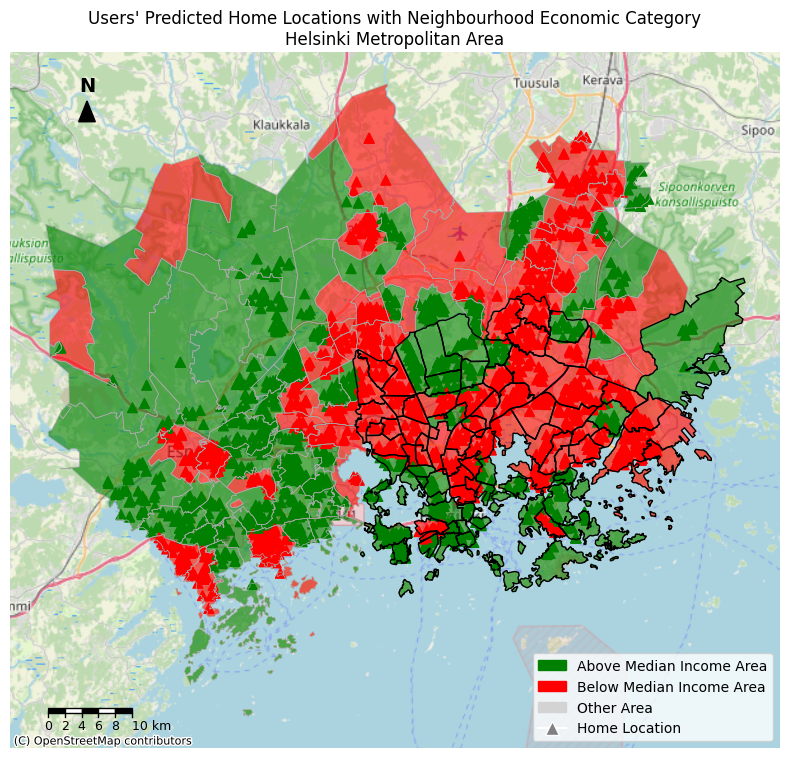

In [ ]:


color_map = {
    "Rich": "green",
    "Poor": "red"
}

def add_north_arrow(ax, size=2500, xy=(0.1, 0.9)):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    x = x0 + dx * xy[0]
    y = y0 + dy * xy[1]

    tip = (x, y + size)
    left = (x - size * 0.4, y)
    right = (x + size * 0.4, y)

    arrow = plt.Polygon([tip, left, right], closed=True, color='black', zorder=10)
    ax.add_patch(arrow)

    ax.text(x, y + size * 1.3, 'N', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='black', zorder=11)


def add_scalebar(ax, length_km=10, segments=5, location='lower left'):

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    bar_length = length_km * 1000  # meters
    seg_length = bar_length / segments

    margin_x = dx * 0.05
    margin_y = dy * 0.05
    bar_height = dy * 0.007
    tick_height = bar_height * 0.8
    label_offset = bar_height * 1.3
    font_size = 9

    if location == 'lower left':
        x_start = x0 + margin_x
    else:
        x_start = x1 - margin_x - bar_length
    y_start = y0 + margin_y

    for i in range(segments):
        color = 'black' if i % 2 == 0 else 'white'
        rect = Rectangle(
            (x_start + i * seg_length, y_start),
            seg_length, bar_height,
            facecolor=color, edgecolor='black', lw=1, zorder=10
        )
        ax.add_patch(rect)

    for i in range(segments + 1):
        x_tick = x_start + i * seg_length
        ax.plot([x_tick, x_tick], [y_start, y_start - tick_height],
                color='black', lw=1)

        if i < segments:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)}",
                    ha='center', va='top', fontsize=font_size)
        else:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)} km",
                    ha='left', va='top', fontsize=font_size)

filtered_mobility = pd.read_csv(
    "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_affinity.csv",
    usecols=["Userid"]
)
valid_userids = filtered_mobility["Userid"].dropna().unique()

home_location = pd.read_csv("/content/drive/My Drive/Thesis/Data/PARAMETRIC SCORE/combined_parametric_score.csv")
home_location[["home_lat", "home_lon"]] = home_location["h3_index"].apply(lambda h: pd.Series(h3.h3_to_geo(h)))
home_location = home_location.rename(columns={"user_id": "Userid"}).drop_duplicates(subset="Userid")
user_locations_df = home_location[home_location["Userid"].isin(valid_userids)].reset_index(drop=True)
home_gdf = gpd.GeoDataFrame(
    user_locations_df[["Userid", "home_lat", "home_lon"]],
    geometry=gpd.points_from_xy(user_locations_df["home_lon"], user_locations_df["home_lat"]),
    crs="EPSG:4326"
)


merged_data = merged_data.to_crs(home_gdf.crs)

home_with_income = gpd.sjoin(
    home_gdf,
    merged_data[["Economic Category", "geometry"]],
    how="left",
    predicate="within"
)

home_with_income = home_with_income[["Userid", "Economic Category"]]
home_gdf_with_category = home_gdf.merge(home_with_income, on="Userid", how="left")
home_gdf_with_category["color"] = home_gdf_with_category["Economic Category"].map(color_map).fillna("grey")
merged_data["color"] = merged_data["Economic Category"].map(color_map).fillna("lightgrey")

merged_web = merged_data.to_crs(epsg=3857)
home_web = home_gdf_with_category.to_crs(epsg=3857)
home_web = home_web[home_web.within(merged_web.unary_union)]
helsinki_border = merged_web[merged_web["Toimip"] == "HELSINKI"]
other_metro_border = merged_web[merged_web["Toimip"] != "HELSINKI"]

fig, ax = plt.subplots(figsize=(8, 8))
other_metro_border.boundary.plot(ax=ax, color="darkgrey", linewidth=0.5)
helsinki_border.boundary.plot(ax=ax, color="black", linewidth=1)
merged_web.plot(ax=ax, color=merged_web["color"], edgecolor='none', alpha=0.6)
home_web.plot(ax=ax, marker='^', markersize=50, color=home_web["color"], label="Home Location")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Users' Predicted Home Locations with Neighbourhood Economic Category\nHelsinki Metropolitan Area", fontsize=12)
ax.axis("off")

legend_elements = [
    mpatches.Patch(color='green', label='Above Median Income Area'),
    mpatches.Patch(color='red', label='Below Median Income Area'),
    mpatches.Patch(color='lightgrey', label='Other Area'),
    plt.Line2D([], [], marker='^', color='w', markerfacecolor='grey', markersize=10, label='Home Location')
]
ax.legend(handles=legend_elements, loc='lower right')


add_north_arrow(ax, size=2500, xy=(0.1, 0.9))
add_scalebar(ax, length_km=10, segments=5, location='lower left')

plt.tight_layout()
plt.show()

#(OpenAI, 2025l)

This section of the code finalises the integration of users’ socioeconomic background and behavioural interests into a unified human mobility dataset. The objective is to produce a consolidated output file, mobility_with_economic_category.csv, which brings together three key layers of information: the income classification of each user’s predicted home area, their dominant affinity profile for the current month, and their affinity profile from the previous month.

To enhance the interpretability of behavioural data, the code then replaces numeric affinity category identifiers with descriptive labels. These labels correspond to users’ most prominent interests in a given month, such as “SHOPPING”, “LEISURE”, or “HEALTH_SERVICES”. The translation is performed using a predefined mapping dictionary. In cases where no dominant interest is detected, a default label of “Mixed” is applied, indicating that the user exhibited no clear preference for any single category.



In [ ]:


home_category = home_web[["Userid", "Economic Category"]].drop_duplicates(subset="Userid")
affinity_map = {
    101: "APPAREL_AND_ACCESSORY_STORES",
    102: "AUTOMOTIVE_DEALERS_AND_GASOLINE_SERVICE_STATIONS",
    103: "EATING_AND_DRINKING_PLACES",
    104: "HOME_FURNITURE__FURNISHINGS_AND_EQUIPMENT_STORES",
    105: "AMUSEMENT_AND_RECREATION_SERVICES",
    106: "AUTOMOTIVE_REPAIR__SERVICES_AND_PARKING",
    107: "EDUCATIONAL_SERVICES",
    108: "HEALTH_SERVICES",
    109: "HOTELS__ROOMING_HOUSES__CAMPS__AND_OTHER_LODGING_PLACES",
    110: "LEISURE",
    111: "MOTION_PICTURES",
    112: "MUSEUMS__ART_GALLERIES_AND_BOTANICAL_AND_ZOOLOGICAL_GARDENS",
    113: "SHOPPING",
    114: "TOURISM",
    115: "SPORTS",
    "MIXED": "Mixed"
}


input_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_affinity.csv"
output_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category.csv"

if os.path.exists(output_path):
    os.remove(output_path)

chunk_size = 100_000
first_chunk = True

for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
    chunk = chunk.merge(home_category, on="Userid", how="inner")
    if "month_x" in chunk.columns and "month_y" in chunk.columns:
        chunk = chunk.rename(columns={"month_x": "month"})
        chunk = chunk.drop(columns=["month_y"])

    def clean(val):
        try:
            return int(float(val))
        except:
            return "MIXED"

    chunk["cat_id_clean"] = chunk["affinity_profile"].apply(clean)
    chunk["prev_cat_id_clean"] = chunk["prev_affinity_profile"].apply(clean)
    chunk["Affinity Profile"] = chunk["cat_id_clean"].map(affinity_map)
    chunk["Previous Affinity Profile"] = chunk["prev_cat_id_clean"].map(affinity_map)
    chunk = chunk.drop(columns=["affinity_profile", "prev_affinity_profile", "cat_id_clean", "prev_cat_id_clean"])

    if "cat_id" in chunk.columns:
        cat_id_idx = chunk.columns.get_loc("cat_id")
        cols = list(chunk.columns)
        for col in ["Affinity Profile", "Previous Affinity Profile"]:
            cols.insert(cat_id_idx + 1, cols.pop(cols.index(col)))
            cat_id_idx += 1
        chunk = chunk[cols]

    chunk.to_csv(output_path, mode="a", index=False, header=first_chunk)
    first_chunk = False

print(f"All data written to: {output_path}")

#(OpenAI, 2025p)

/tmp/ipython-input-463108904.py:39: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
/tmp/ipython-input-463108904.py:39: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
/tmp/ipython-input-463108904.py:39: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
/tmp/ipython-input-463108904.py:39: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
/tmp/ipython-input-463108904.py:39: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, ch

✅ All data written to: /content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category.csv


This code prepares a large-scale human mobility dataset for temporal analysis by organising user trajectories into five-minute time windows and sorting all records in chronological order. The five-minute binning structure provides a consistent temporal resolution that facilitates efficient analysis across defined intervals. To ensure temporal accuracy, all records are sorted by timestamp, allowing the final output to reflect the true order of events.

In [ ]:


input_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category.csv"
temp_directory = "/content/tmp_bins_5min"
sorted_data = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_sorted_by_time.csv"

USECOLS = ["Userid","lat","lon","timestamp","Economic Category","Previous Affinity Profile",
           "datetime","year","month","dow","day","hour","minute","track_type","geometry","Affinity Profile"]

shutil.rmtree(temp_directory, ignore_errors=True)
os.makedirs(temp_directory, exist_ok=True)

seen_bins = set()
for ch in pd.read_csv(input_path, usecols=USECOLS, chunksize=300_000, low_memory=False):
    ch = ch.dropna(subset=["Userid","lat","lon","timestamp"])
    ch["timestamp"] = pd.to_numeric(ch["timestamp"], errors="coerce")
    ch = ch.dropna(subset=["timestamp"])
    t = pd.to_datetime(ch["timestamp"], unit="s", utc=True)
    ch["time_bin"] = t.dt.floor("5min")
    for tb, dfb in ch.groupby("time_bin", sort=False):
        key = tb.strftime("%Y%m%d_%H%M")
        out = os.path.join(temp_directory, f"bin_{key}.csv")
        if key not in seen_bins and os.path.exists(out):
            os.remove(out)
        seen_bins.add(key)

        dfb = dfb.drop(columns=["time_bin"]).sort_values("timestamp", kind="mergesort")
        dfb.to_csv(out, mode="a", index=False, header=not os.path.exists(out))

if os.path.exists(sorted_data):
    os.remove(sorted_data)
first = True
for f in sorted(glob.glob(os.path.join(temp_directory, "bin_*.csv"))):
    bin_df = pd.read_csv(f, low_memory=False)
    bin_df = bin_df.drop_duplicates()
    bin_df = bin_df.sort_values("timestamp", kind="mergesort")
    bin_df.to_csv(sorted_data, mode="a", index=False, header=first)
    first = False

print("time-sorted file:", sorted_data)


#(OpenAI, 2025al)

time-sorted file: /content/drive/My Drive/Thesis/Data/Human Mobility/mobility_sorted_by_time.csv


This section of the code is designed to quantify experienced segregation in urban mobility patterns by calculating per-user exposure to individuals from different socioeconomic and affinity groups within a five-minute spatial and temporal window. The aim is to measure how frequently users come into close physical proximity with others who differ from them in terms of economic status or behavioural preferences. The underlying idea is that individuals may consciously or unconsciously visit places where they are more likely to encounter people who are either similar to or different from themselves. This study hypothesises that understanding patterns of co-presence may improve the performance of next-location prediction models by incorporating socially meaningful contextual information.

The methodological foundation for this approach is drawn from the work of Nilforoshan et al. (2023), who developed a high-resolution framework to measure experienced segregation in large cities. Their study is based on the "cosmopolitan mixing hypothesis," which suggests that urban environments, shaped by high population density, spatial constraints, and accessible public transportation, increase the likelihood of diverse individuals coming into physical contact. To operationalise this idea, Nilforoshan et al. define an exposure event as an instance in which two individuals are located within 50 metres of each other within a five-minute time window. These thresholds were chosen to capture visual exposure and are supported by prior research showing that even brief encounters with socially dissimilar individuals can have long-term effects. The five-minute window is particularly stringent, considering that the average number of location pings per person per hour is approximately one.

Following the same parameters, this study aims to detect similar exposure events. For each user and timestamp, the code evaluates how many nearby users fall into a different economic category (represented by the variable row_diff_econ_rate), how many belong to a different behavioural affinity group based on the previous month (row_diff_prev_aff_rate), and the total number of co-located users within the defined spatial and temporal range (row_contacts_total).

Given the sparsity of GPS-based mobility data, as noted by Nezhadettehad et al. (2025), it is expected that many time windows will contain few or no interaction events. To address this limitation, the code applies Laplace smoothing to the contact rate variables, producing two additional features: econ_rate_smooth and prev_rate_smooth. These smoothed variables provide more stable and interpretable values, especially in cases with low or zero contact counts, which enhances the robustness of subsequent statistical models and supports fairness-focused analysis (Boodidhi, 2011; Daniel and Martin, 2025). The code also generates a binary variable, has_contact, to indicate whether any interaction occurred, as well as a capped log-transformed variable, log_contacts, to reduce skewness and minimise the influence of outliers (Jeong, Leconte and Proutiere, 2016; Nahhas, 2025; Reifman and Keyton, 2012).

To maintain temporal precision and computational efficiency, the data is processed in rolling batches. At each step, a single time bin is loaded and combined with adjacent bins to construct the required five-minute window. This method ensures complete temporal coverage while avoiding edge effects and preserving the accuracy of exposure calculations across the full dataset.

In [ ]:


input_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_sorted_by_time.csv"
output_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv"

chunks       = 100_000
time_window  = 5 * 60        # seconds
d_meters     = 50.0
PAST_ONLY    = True          # True = only look backward up to 5 min
ALPHA = 1.0                  # Laplace smoothing (Beta-Binomial prior alpha)
BETA  = 1.0                  # Laplace smoothing (Beta-Binomial prior beta)
CAP_CONTACTS = 20.0          # cap before log1p

USECOLS = [
    "Userid","lat","lon","timestamp",
    "Economic Category","Previous Affinity Profile",
    "datetime","year","month","dow","day","hour","minute","track_type","geometry","Affinity Profile"
]

to_m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

def compute_bin_exposure(window_df, target_df): #function to return 0 or nan for the columns
    if target_df.empty:
        return pd.DataFrame(index=target_df.index, data={
            "row_diff_econ_rate": np.nan,
            "row_diff_prev_aff_rate": np.nan,
            "row_contacts_total": 0
        })

    wx, wy = to_m.transform(window_df["lon"].to_numpy(), window_df["lat"].to_numpy()) #converts the longitude and latitude
    tree = cKDTree(np.c_[wx, wy]) #builds a KD-tree from all the window point

    #extract variables from window df
    w_time = window_df["timestamp"].to_numpy()
    w_uid  = window_df["Userid"].to_numpy()
    w_econ = window_df["Economic Category"].fillna("Unknown").to_numpy()
    w_prev = window_df["Previous Affinity Profile"].fillna("Unknown").to_numpy()
    #extract variables from target df
    tx, ty = to_m.transform(target_df["lon"].to_numpy(), target_df["lat"].to_numpy())
    t_time = target_df["timestamp"].to_numpy()
    t_uid  = target_df["Userid"].to_numpy()
    t_econ = target_df["Economic Category"].fillna("Unknown").to_numpy()
    t_prev = target_df["Previous Affinity Profile"].fillna("Unknown").to_numpy()
    #creates 3 output arrays
    out_econ = np.full(len(target_df), np.nan)
    out_prev = np.full(len(target_df), np.nan)
    out_tot  = np.zeros(len(target_df), dtype=int)

    neigh_lists = tree.query_ball_point(np.c_[tx,ty], r=d_meters) #find spatial neighbors
    for i, idxs in enumerate(neigh_lists): #loop through each target user
        if not idxs:
            continue #skip if no neighbors
        if PAST_ONLY: #filter by time window (5 minutes)
            m_time = (w_time[idxs] <= t_time[i]) & ((t_time[i] - w_time[idxs]) <= time_window)
        else:
            m_time = np.abs(w_time[idxs] - t_time[i]) <= time_window
        m_self = (w_uid[idxs] != t_uid[i]) #filter out self
        m = m_time & m_self #combine filters
        if not np.any(m):
            continue

        idxs = np.asarray(idxs)[m] #calculate outputs for this user
        out_tot[i]  = len(idxs)
        out_econ[i] = np.mean(w_econ[idxs] != t_econ[i])
        out_prev[i] = np.mean(w_prev[idxs] != t_prev[i])

    return pd.DataFrame(index=target_df.index, data={
        "row_diff_econ_rate": out_econ,
        "row_diff_prev_aff_rate": out_prev,
        "row_contacts_total": out_tot
    })


if os.path.exists(output_path):
    os.remove(output_path)
first_write = True
carry = pd.DataFrame(columns=USECOLS + ["time_bin"])

reader = pd.read_csv(input_path, usecols=USECOLS, chunksize=chunks, low_memory=False) #read CSV in chunks
for chunk in reader:
    chunk = chunk.dropna(subset=["Userid","lat","lon","timestamp"]) #drop rows with missing location
    chunk["timestamp"] = pd.to_numeric(chunk["timestamp"], errors="coerce") #making sure timestamp is numeri
    chunk = chunk.dropna(subset=["timestamp"])
    t = pd.to_datetime(chunk["timestamp"], unit="s", utc=True) #convert to datetime + assign 5-minute time bins
    chunk["time_bin"] = t.dt.floor("5min")
    combined = pd.concat([carry, chunk], ignore_index=True) #merge from previous chunk
    if combined.empty:
        carry = combined
        continue

    g = combined.groupby("time_bin", sort=True) #groups all check-ins into discrete 5-minute windows
    bins = sorted(g.groups.keys()) #ascending order
    if len(bins) == 1:
        carry = combined
        continue

    for bi in range(len(bins)-1): #looping through time bins
        curr_bin = bins[bi]
        prev_bin = bins[bi-1] if bi-1 >= 0 else None
        next_bin = bins[bi+1]
        frames = [g.get_group(curr_bin), g.get_group(next_bin)] #collect rows
        if prev_bin is not None:
            frames.append(g.get_group(prev_bin))
        #define the analysis window and target
        window_df = pd.concat(frames, ignore_index=True)
        target_df = g.get_group(curr_bin).copy()
        #run contact exposure calculation
        rates = compute_bin_exposure(window_df, target_df)
        out = target_df.join(rates)
        #binary and log
        out["has_contact"]  = (out["row_contacts_total"] > 0).astype(int)
        out["log_contacts"] = np.log1p(np.minimum(out["row_contacts_total"].astype(float), CAP_CONTACTS))
        mask_no = out["row_contacts_total"] == 0 #handle zero-contact rows
        out.loc[mask_no, ["row_diff_econ_rate","row_diff_prev_aff_rate"]] = np.nan
        #Laplace-smooth the exposure rates
        den = out["row_contacts_total"].astype(float)
        diff_e = (out["row_diff_econ_rate"] * den).where(den > 0, 0.0)
        diff_p = (out["row_diff_prev_aff_rate"] * den).where(den > 0, 0.0)
        out["econ_rate_smooth"] = np.where(den > 0, (diff_e + ALPHA)/(den + ALPHA + BETA), np.nan)
        out["prev_rate_smooth"] = np.where(den > 0, (diff_p + ALPHA)/(den + ALPHA + BETA), np.nan)
        out.to_csv(output_path, mode="a", index=False, header=first_write)
        first_write = False
    carry = g.get_group(bins[-1]).copy()

if not carry.empty:
    carry_bins = carry.groupby("time_bin", sort=True) #group the remaining carry data by 5-minute bin
    bins = sorted(carry_bins.groups.keys())
    for bi, b in enumerate(bins): #loop over each bin in the carry
        prev_df   = carry_bins.get_group(bins[bi-1]) if bi-1 >= 0 else pd.DataFrame() #construct the analysis window
        target_df = carry_bins.get_group(b).copy()
        window_df = pd.concat([prev_df, target_df], ignore_index=True)
        rates = compute_bin_exposure(window_df, target_df) #compute the contact features
        out = target_df.join(rates)
        out["has_contact"]  = (out["row_contacts_total"] > 0).astype(int) #add the derived features
        out["log_contacts"] = np.log1p(np.minimum(out["row_contacts_total"].astype(float), CAP_CONTACTS))
        mask_no = out["row_contacts_total"] == 0 #clean rows with 0 contacts
        out.loc[mask_no, ["row_diff_econ_rate","row_diff_prev_aff_rate"]] = np.nan
        den = out["row_contacts_total"].astype(float)
        diff_e = (out["row_diff_econ_rate"] * den).where(den > 0, 0.0)
        diff_p = (out["row_diff_prev_aff_rate"] * den).where(den > 0, 0.0)
        out["econ_rate_smooth"] = np.where(den > 0, (diff_e + ALPHA)/(den + ALPHA + BETA), np.nan) #apply the Laplace smoothing
        out["prev_rate_smooth"] = np.where(den > 0, (diff_p + ALPHA)/(den + ALPHA + BETA), np.nan) #apply the Laplace smoothing
        out.to_csv(output_path, mode="a", index=False, header=first_write)
        first_write = False

print("Saved:", output_path)

# (OpenAI, 2025ac; OpenAI, 2025i)

/tmp/ipython-input-190483220.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([carry, chunk], ignore_index=True)


Saved: /content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv


The findings reveal that the data is indeed highly sparse. Out of more than 26 million valid entries, only about 2.38 million involve any kind of contact. This means that over 90 percent of the entries represent moments when users were not in close proximity to others. This result is typical when analyzing fine-scale spatiotemporal data, where short time windows and strict distance thresholds reduce the number of detected interactions.

Total rows with valid 'row_contacts_total': 26,152,145
Rows where row_contacts_total > 0: 2,382,997
Share: 9.11%


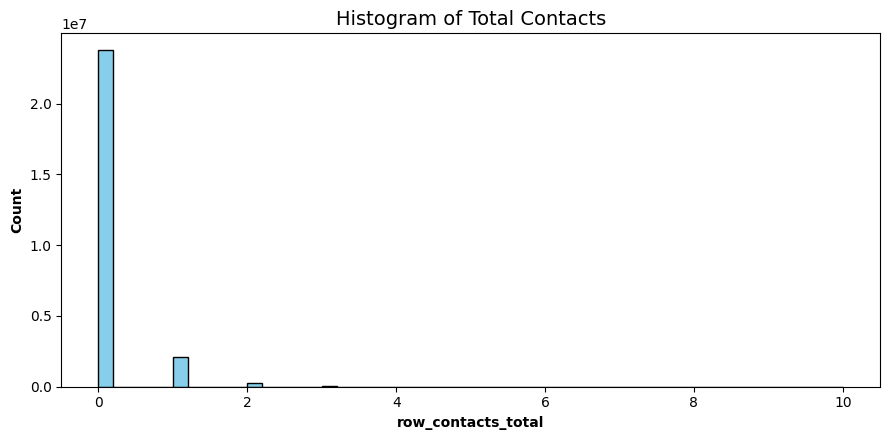

In [ ]:



path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv"
chunksize = 100_000
col = "row_contacts_total"


min_v, max_v = None, None
for chunk in pd.read_csv(path, usecols=[col], chunksize=chunksize, low_memory=False):
    s = pd.to_numeric(chunk[col], errors="coerce").dropna()
    if s.empty:
        continue
    vmin, vmax = s.min(), s.max()
    min_v = vmin if min_v is None else min(min_v, vmin)
    max_v = vmax if max_v is None else max(max_v, vmax)

if min_v is None:
    raise ValueError(f"No valid numeric data found in column '{col}'.")


nbins = 50
bin_edges = np.linspace(min_v, max_v, nbins + 1)
hist = np.zeros(nbins, dtype=np.float64)

total_rows = 0
rows_gt_zero = 0

for chunk in pd.read_csv(path, usecols=[col], chunksize=chunksize, low_memory=False):
    s = pd.to_numeric(chunk[col], errors="coerce").dropna()
    if s.empty:
        continue
    counts, _ = np.histogram(s.values, bins=bin_edges)
    hist += counts
    total_rows += s.size
    rows_gt_zero += (s > 0).sum()

print(f"Total rows with valid '{col}': {total_rows:,}")
print(f"Rows where {col} > 0: {rows_gt_zero:,}")
if total_rows:
    print(f"Share: {rows_gt_zero / total_rows:.2%}")


centers = (bin_edges[:-1] + bin_edges[1:]) / 2
widths = np.diff(bin_edges)

plt.figure(figsize=(9, 4.5))
plt.bar(centers, hist, width=widths, align="center", color='skyblue', edgecolor='black')
plt.xlabel("row_contacts_total", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.title("Histogram of Total Contacts", fontsize=14)
plt.tight_layout()
plt.show()

#(OpenAI, 2025h)

## Exploratory Data Analysis

This code creates a detailed visualisation of all GPS points recorded within the Helsinki Metropolitan Area, based on a filtered and enriched human mobility dataset.

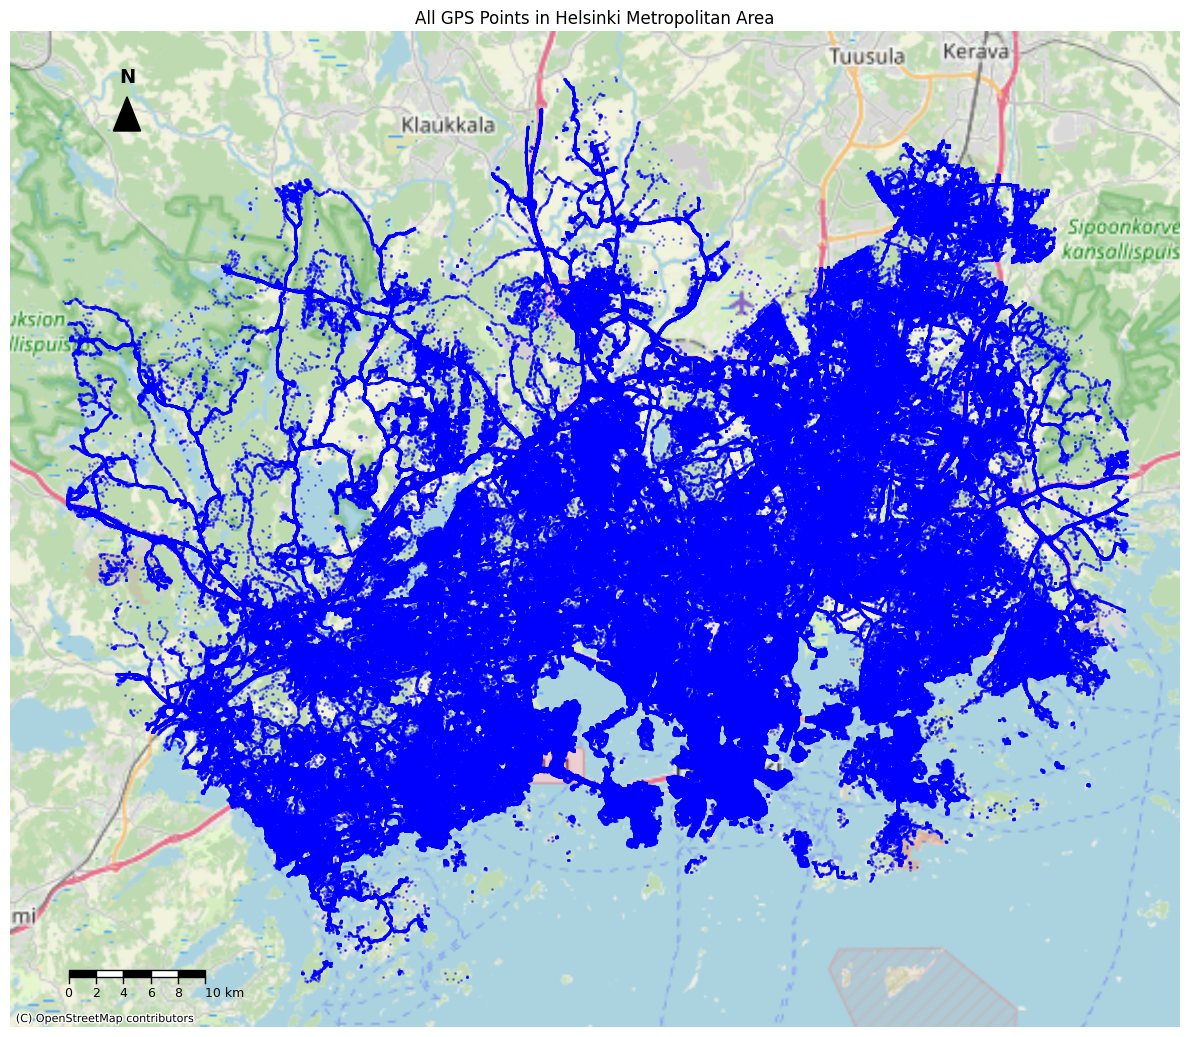

In [ ]:


input_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv"
chunk_size = 200_000

def add_north_arrow(ax, size=2500, xy=(0.1, 0.9)):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    x = x0 + dx * xy[0]
    y = y0 + dy * xy[1]

    tip = (x, y + size)
    left = (x - size * 0.4, y)
    right = (x + size * 0.4, y)

    arrow = plt.Polygon([tip, left, right], closed=True, color='black', zorder=10)
    ax.add_patch(arrow)

    ax.text(x, y + size * 1.3, 'N', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='black', zorder=11)


def add_scalebar(ax, length_km=10, segments=5, location='lower left'):

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    bar_length = length_km * 1000  # meters
    seg_length = bar_length / segments

    margin_x = dx * 0.05
    margin_y = dy * 0.05
    bar_height = dy * 0.007
    tick_height = bar_height * 0.8
    label_offset = bar_height * 1.3
    font_size = 9

    if location == 'lower left':
        x_start = x0 + margin_x
    else:
        x_start = x1 - margin_x - bar_length
    y_start = y0 + margin_y

    for i in range(segments):
        color = 'black' if i % 2 == 0 else 'white'
        rect = Rectangle(
            (x_start + i * seg_length, y_start),
            seg_length, bar_height,
            facecolor=color, edgecolor='black', lw=1, zorder=10
        )
        ax.add_patch(rect)

    for i in range(segments + 1):
        x_tick = x_start + i * seg_length
        ax.plot([x_tick, x_tick], [y_start, y_start - tick_height],
                color='black', lw=1)

        if i < segments:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)}",
                    ha='center', va='top', fontsize=font_size)
        else:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)} km",
                    ha='left', va='top', fontsize=font_size)

helsinki_bounds = {
    "minx": 24.5,
    "maxx": 25.2,
    "miny": 60.1,
    "maxy": 60.4
}

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("All GPS Points in Helsinki Metropolitan Area",fontsize=12)
ax.axis("off")

for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
    chunk = chunk.dropna(subset=["lat", "lon"])
    chunk = chunk[
        (chunk["lat"] >= helsinki_bounds["miny"]) &
        (chunk["lat"] <= helsinki_bounds["maxy"]) &
        (chunk["lon"] >= helsinki_bounds["minx"]) &
        (chunk["lon"] <= helsinki_bounds["maxx"])
    ]

    if chunk.empty:
        continue

    gdf = gpd.GeoDataFrame(
        chunk,
        geometry=gpd.points_from_xy(chunk["lon"], chunk["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf.plot(ax=ax, markersize=1, color="blue", alpha=0.4)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
add_north_arrow(ax, size=2500, xy=(0.1, 0.9))
add_scalebar(ax, length_km=10, segments=5, location='lower left')
plt.tight_layout()
plt.show()

#(OpenAI, 2025b)

### Implementing actual POI and mobility data


This section of the code is designed to reconstruct and export user-level travel routes using real-world road network data for the Helsinki Metropolitan Area. The primary objective is to generate spatial trajectories for individual users by mapping their observed GPS coordinates onto the street network and calculating the shortest path between consecutive locations. The output is a GeoJSON file containing realistic, network-constrained movement traces for users during the months of July, August, and September 2024.

To improve data quality, the code applies an interquartile range (IQR) filter to the latitude and longitude values, which helps to remove spatial outliers that may arise due to GPS errors or noise. Additionally, the analysis is restricted to GPS points located within a 10-kilometre radius of the city centre. This distance threshold is chosen because urban activity is most concentrated in this zone, and similar spatial constraints have been applied in prior studies (Kang, 2025).

Each GPS point is snapped to its nearest road network node using the OSMnx library, which allows for accurate mapping of real-world coordinates onto the structured graph of the transportation system. For each user, GPS points are first sorted chronologically and then converted into a sequence of corresponding network nodes. The code attempts to compute the shortest path between each pair of consecutive nodes. When successful, these segments are concatenated to form a continuous trajectory represented as a LineString geometry. Each trajectory is annotated with the user’s unique identifier, economic classification, and monthly affinity profile. To avoid redundancy and minimise computational load, only one shortest trajectory per user is saved.

In [ ]:


iqr_k = 1.5
city_center = (60.1695, 24.9354)
G = ox.graph_from_point(city_center, dist=5000, network_type='all')
G_proj = ox.project_graph(G, to_crs="EPSG:3857")
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj, nodes=True, edges=True)
center_point = gpd.GeoSeries([Point(city_center[1], city_center[0])], crs="EPSG:4326").to_crs(3857)

input_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category.csv"
output_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/routes_shortest_path.geojson"
chunk_size = 200_000
trajectories, meta_info = [], []
unique_users = set()

if os.path.exists(output_path):
    os.remove(output_path)

for chunk in pd.read_csv(input_path, chunksize=chunk_size):
    chunk = chunk[(chunk["year"] == 2024) & (chunk["month"].isin([7, 8, 9]))]
    chunk = chunk.dropna(subset=["lat", "lon", "Userid"])

    for col in ["lat", "lon"]:
        Q1, Q3 = chunk[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        chunk = chunk[(chunk[col] >= Q1 - iqr_k * IQR) & (chunk[col] <= Q3 + iqr_k * IQR)]

    gdf = gpd.GeoDataFrame(chunk, geometry=gpd.points_from_xy(chunk["lon"], chunk["lat"]), crs="EPSG:4326").to_crs(3857)
    gdf = gdf[gdf.distance(center_point.iloc[0]) <= 10000]

    if gdf.empty:
        continue

    gdf["osm_node"] = ox.distance.nearest_nodes(G_proj, X=gdf.geometry.x, Y=gdf.geometry.y)

    for uid, user_df in gdf.groupby("Userid"):
        if uid in unique_users or user_df.shape[0] < 2:
            continue

        user_df = user_df.sort_values("timestamp")
        node_list = user_df["osm_node"].tolist()

        full_path = []
        for i in range(len(node_list) - 1):
            try:
                segment = nx.shortest_path(G_proj, node_list[i], node_list[i + 1], weight='length')
                full_path.extend(segment[:-1])
            except:
                continue
        full_path.append(node_list[-1])

        if len(full_path) < 2:
            continue

        coords = [(G_proj.nodes[n]["x"], G_proj.nodes[n]["y"]) for n in full_path]
        trajectory = LineString(coords)

        trajectories.append(trajectory)
        meta_info.append({
            "Userid": uid,
            "Economic Category": user_df["Economic Category"].iloc[0],
            "Affinity Profile": user_df["Affinity Profile"].iloc[0]
        })
        unique_users.add(uid)


routes = gpd.GeoDataFrame(meta_info, geometry=trajectories, crs="EPSG:3857")
routes = routes[routes["Economic Category"].isin(["Rich", "Poor"])]
routes.to_crs("EPSG:4326").to_file(output_path, driver="GeoJSON")
print(f"Saved {len(routes)} trajectories to {output_path}")

#(OpenAI, 2025ab)

Saved 2753 trajectories to /content/drive/My Drive/Thesis/Data/Human Mobility/routes_shortest_path.geojson


This section of the code generates a spatial visualisation that illustrates which income group predominantly uses each road segment within the central area of Helsinki.

The process begins by downloading the road network for the Helsinki region and loading a previously generated dataset of user trajectories. These trajectories represent realistic travel routes through the city, derived from shortest-path calculations over the road network. Each trajectory is associated with the economic classification of the user, defined as either above-median income or below-median income.

The script then analyses each route by identifying the road segments it intersects. For every segment traversed by a user, the code increments a counter corresponding to the user’s income group. These counts are aggregated across all users and used to classify the dominant economic group for each road segment. Segments where more than 70 percent of users belong to the above-median income group are visualised in green. Segments where fewer than 30 percent of users are from the above-median group or predominantly used by below-median income users are visualised in red. Segments with more balanced usage between groups are labelled as "Mixed roads" and coloured blue. Segments not traversed by any users are displayed in light grey.

The resulting visualisation reveals that many roads within the city centre are classified as mixed, reflecting shared use by both groups. However, there are also clear clusters of roads that are predominantly used by either above- or below-median income users. These spatial patterns closely align with the economic classification of nearby neighbourhoods, suggesting that income-based spatial segregation also extends into everyday mobility behaviours.

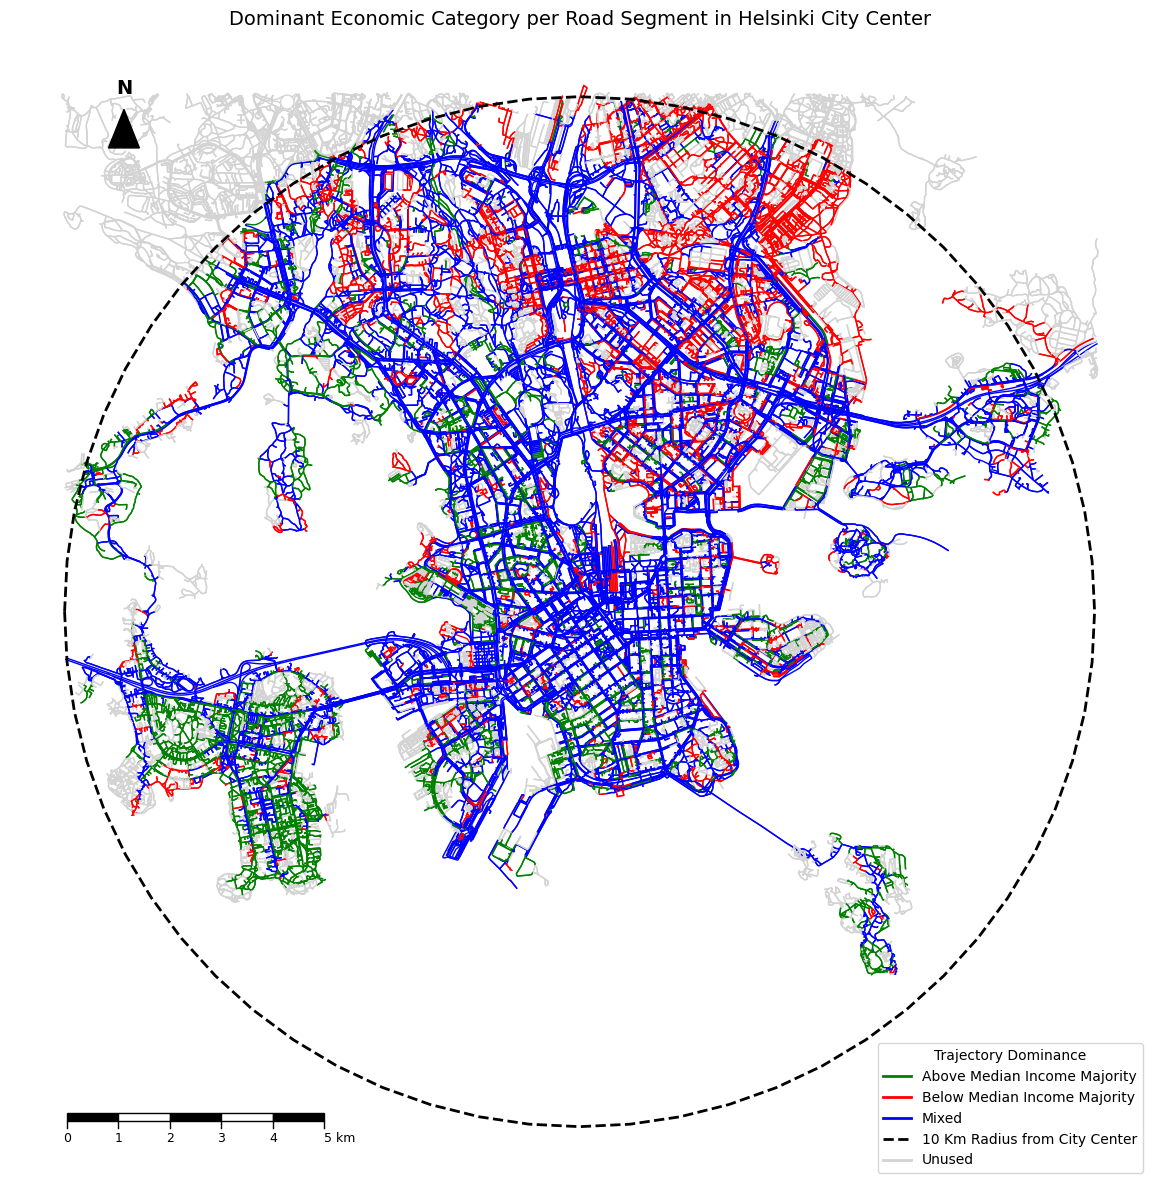

In [ ]:


#setup
city_center = (60.1695, 24.9354)
center_point = gpd.GeoSeries([Point(city_center[1], city_center[0])], crs="EPSG:4326").to_crs(3857)
G = ox.graph_from_point(city_center, dist=5000, network_type='all')
G_proj = ox.project_graph(G, to_crs="EPSG:3857")
edges_gdf = ox.graph_to_gdfs(G_proj, nodes=False)

routes = gpd.read_file("/content/drive/My Drive/Thesis/Data/Human Mobility/routes_shortest_path.geojson")
routes_web = routes.to_crs(3857)

def add_north_arrow(ax, size=2500, xy=(0.1, 0.9)): #add the north arrow
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    x = x0 + dx * xy[0]
    y = y0 + dy * xy[1]

    tip = (x, y + size)
    left = (x - size * 0.4, y)
    right = (x + size * 0.4, y)

    arrow = plt.Polygon([tip, left, right], closed=True, color='black', zorder=10)
    ax.add_patch(arrow)

    ax.text(x, y + size * 1.3, 'N', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='black', zorder=11)


def add_scalebar(ax, length_km=5, segments=5, location='lower left'): #add the scalebar

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    bar_length = length_km * 1000  # meters
    seg_length = bar_length / segments

    margin_x = dx * 0.05
    margin_y = dy * 0.05
    bar_height = dy * 0.007
    tick_height = bar_height * 0.8
    label_offset = bar_height * 1.3
    font_size = 9

    if location == 'lower left':
        x_start = x0 + margin_x
    else:
        x_start = x1 - margin_x - bar_length
    y_start = y0 + margin_y

    for i in range(segments):
        color = 'black' if i % 2 == 0 else 'white'
        rect = Rectangle(
            (x_start + i * seg_length, y_start),
            seg_length, bar_height,
            facecolor=color, edgecolor='black', lw=1, zorder=10
        )
        ax.add_patch(rect)

    for i in range(segments + 1):
        x_tick = x_start + i * seg_length
        ax.plot([x_tick, x_tick], [y_start, y_start - tick_height],
                color='black', lw=1)

        if i < segments:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)}",
                    ha='center', va='top', fontsize=font_size)
        else:
            ax.text(x_tick, y_start - label_offset,
                    f"{int(i * seg_length / 1000)} km",
                    ha='left', va='top', fontsize=font_size)

#count usage per road segment by group
edge_use = defaultdict(lambda: {"Rich": 0, "Poor": 0}) #create a dictionary
for _, row in routes_web.iterrows(): #loop through each user trajectory
    econ_cat = row["Economic Category"] #extract relevant info
    route_geom = row.geometry
    if pd.isna(econ_cat) or not isinstance(route_geom, LineString): #skip if data is missing
        continue
    intersected = edges_gdf[edges_gdf.intersects(route_geom)] #find all road segments that intersect the trajectory
    for edge_idx in intersected.index: #update the count for each road
        if econ_cat in edge_use[edge_idx]:
            edge_use[edge_idx][econ_cat] += 1

edge_colors, rich_counts, poor_counts = [], [], [] #initialize empty lists
for edge_idx, edge in edges_gdf.iterrows(): #loop through every road segment
    counts = edge_use.get(edge_idx, {"Rich": 0, "Poor": 0}) #get usage counts for that edge
    total = counts["Rich"] + counts["Poor"]
    rich_counts.append(counts["Rich"]) #store usage counts
    poor_counts.append(counts["Poor"])
    if total == 0: #assign a color
        color = "lightgray"
    else:
        rich_share = counts["Rich"] / total
        if rich_share > 0.7:
            color = "green"
        elif rich_share < 0.3:
            color = "red"
        else:
            color = "blue"
    edge_colors.append(color)

edges_gdf["color"] = edge_colors
edges_gdf["Rich"] = rich_counts
edges_gdf["Poor"] = poor_counts
edges_gdf["total"] = edges_gdf["Rich"] + edges_gdf["Poor"]


fig, ax = plt.subplots(figsize=(12, 12))
edges_gdf.plot(ax=ax, color=edges_gdf["color"], linewidth=1)


gpd.GeoSeries(center_point.buffer(10000)).plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linestyle="--",
    linewidth=2,
    zorder=3
)

ax.set_title("Dominant Economic Category per Road Segment in Helsinki City Center", fontsize=14)
ax.axis("off")

legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='Above Median Income Majority'),
    Line2D([0], [0], color='red', lw=2, label='Below Median Income Majority'),
    Line2D([0], [0], color='blue', lw=2, label='Mixed'),
    Line2D([0], [0], color='black', lw=2, linestyle="--", label='10 Km Radius from City Center'),
    Line2D([0], [0], color='lightgray', lw=2, label='Unused'),
]
ax.legend(handles=legend_elements, title="Trajectory Dominance", loc="lower right", frameon=True)
add_north_arrow(ax, size=750, xy=(0.1, 0.9))
add_scalebar(ax, length_km=5, segments=5, location='lower left')
plt.tight_layout()
plt.show()

#(OpenAI, 2025ao; OpenAI, 2025j)

This section of the code produces spatial visualisations that show which economic group, either above- or below-median income, predominantly uses each road segment in Helsinki. The results are segmented by users’ affinity profiles.

The visual output captures the spatial structure of socioeconomic segregation within different types of daily activity. One key finding is that the degree of spatial segregation in mobility differs depending on the affinity category. For example, “Leisure,” “Motion Pictures,” and “Apparel and Accessory Stores” show noticeable clustering of red segments, particularly in the north and east of the city. This pattern suggests that below-median income users are more likely to travel in or through these areas for such activities. By contrast, affinity categories such as “Shopping,” “Tourism,” and “Home Furniture and Equipment Stores” demonstrate broader geographic dispersion, with green road segments appearing more frequently in the city centre and the southern parts of the region.

Some affinity profiles show greater levels of integration in road usage. For instance, categories such as “Sports” and “Amusement and Recreation Services” display a wide distribution of green, red, and blue segments, suggesting that infrastructure associated with these activities is more evenly shared between income groups. In most affinity categories, the city centre consistently appears as a core area of mixed road use, indicated by a high concentration of blue segments.

While the current study does not further explore the specific mobility patterns of each affinity category, the visualisations serve as a valuable exploratory tool. They offer an entry point for future research into how behavioural preferences intersect with economic background in shaping patterns of urban mobility.

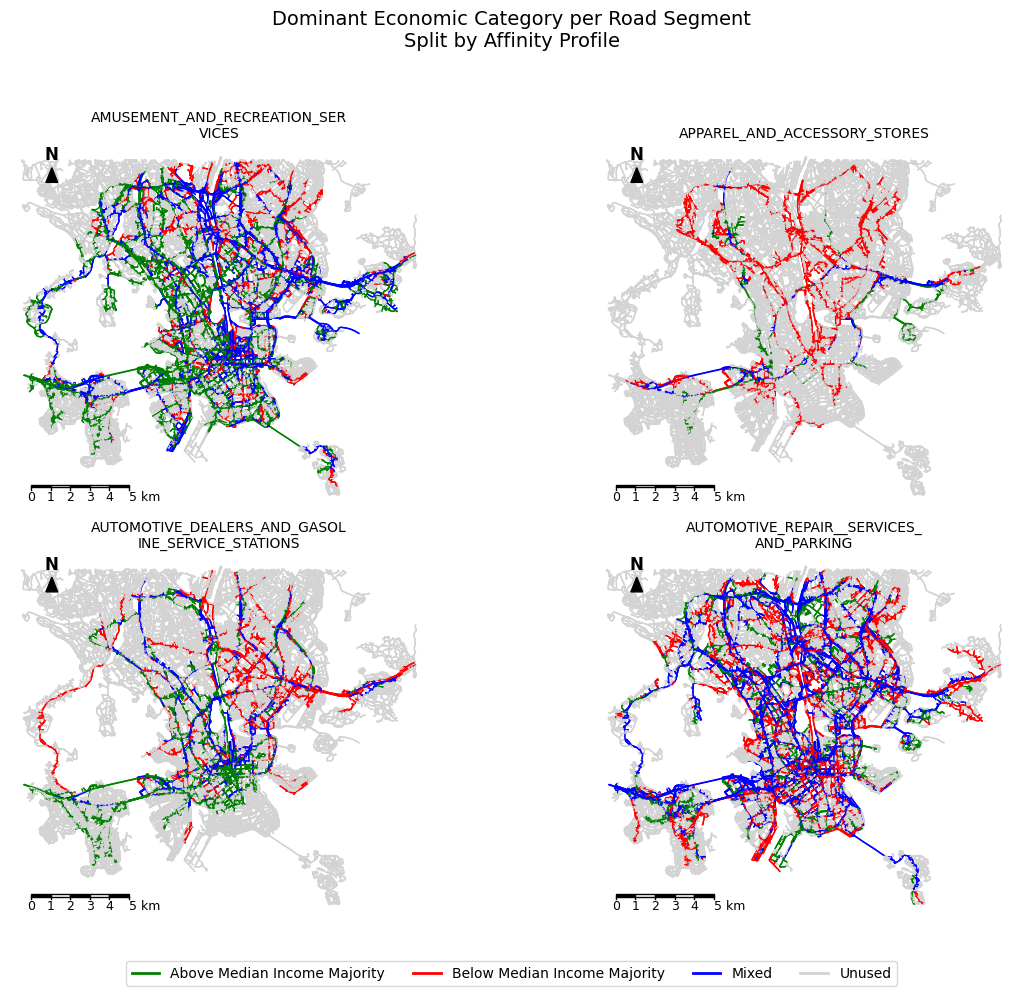

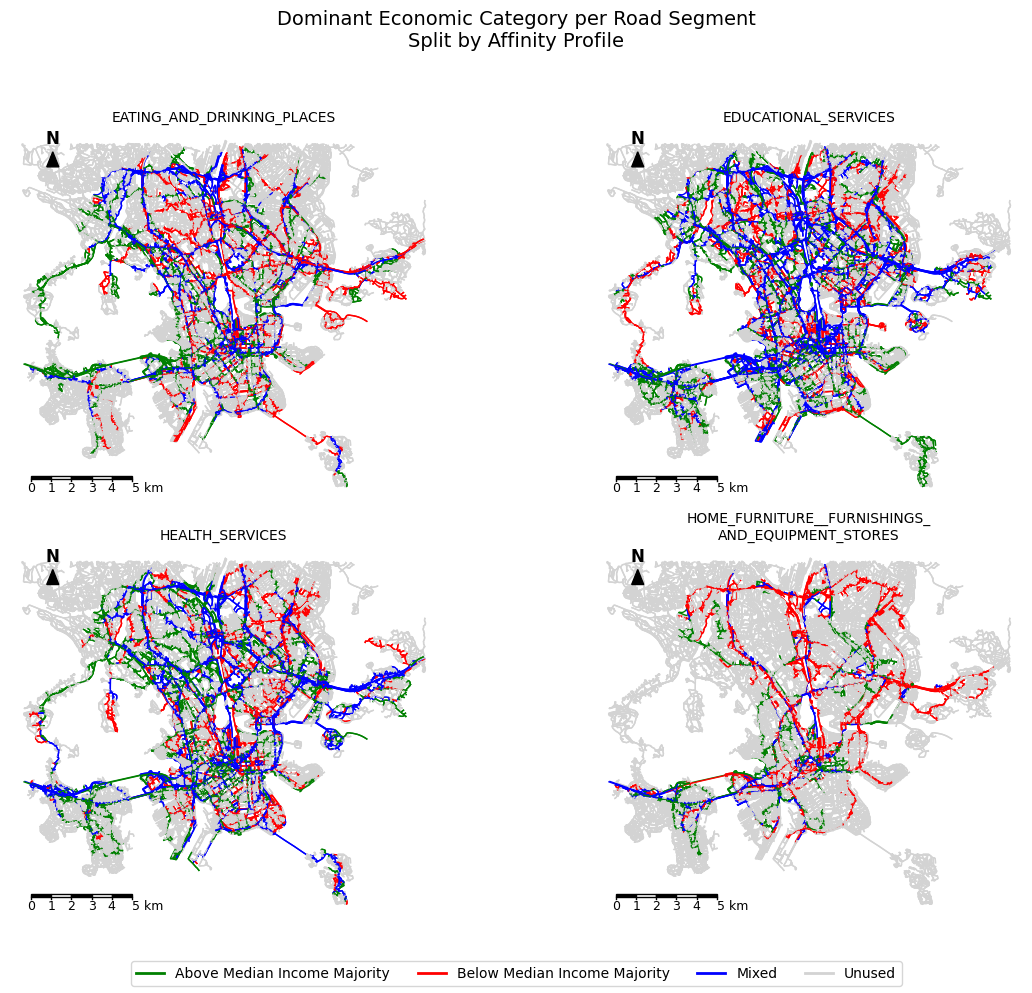

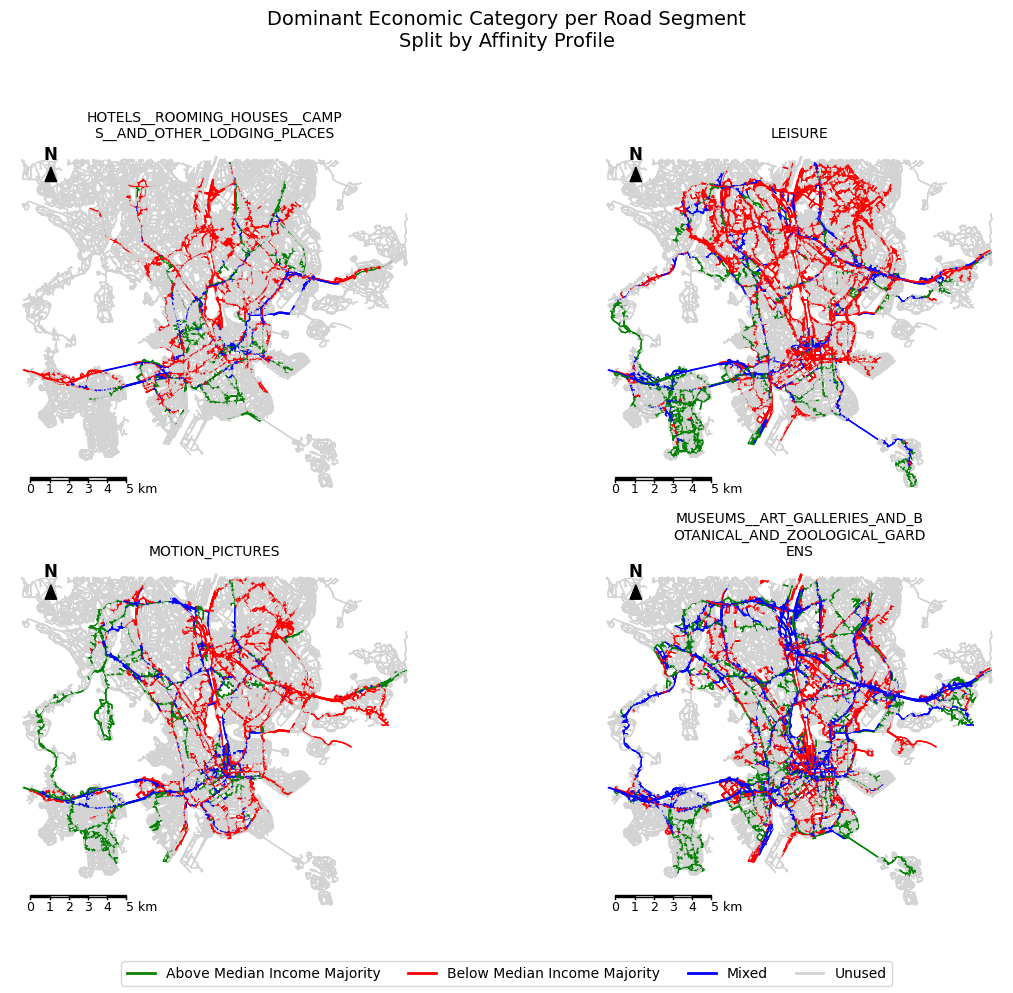

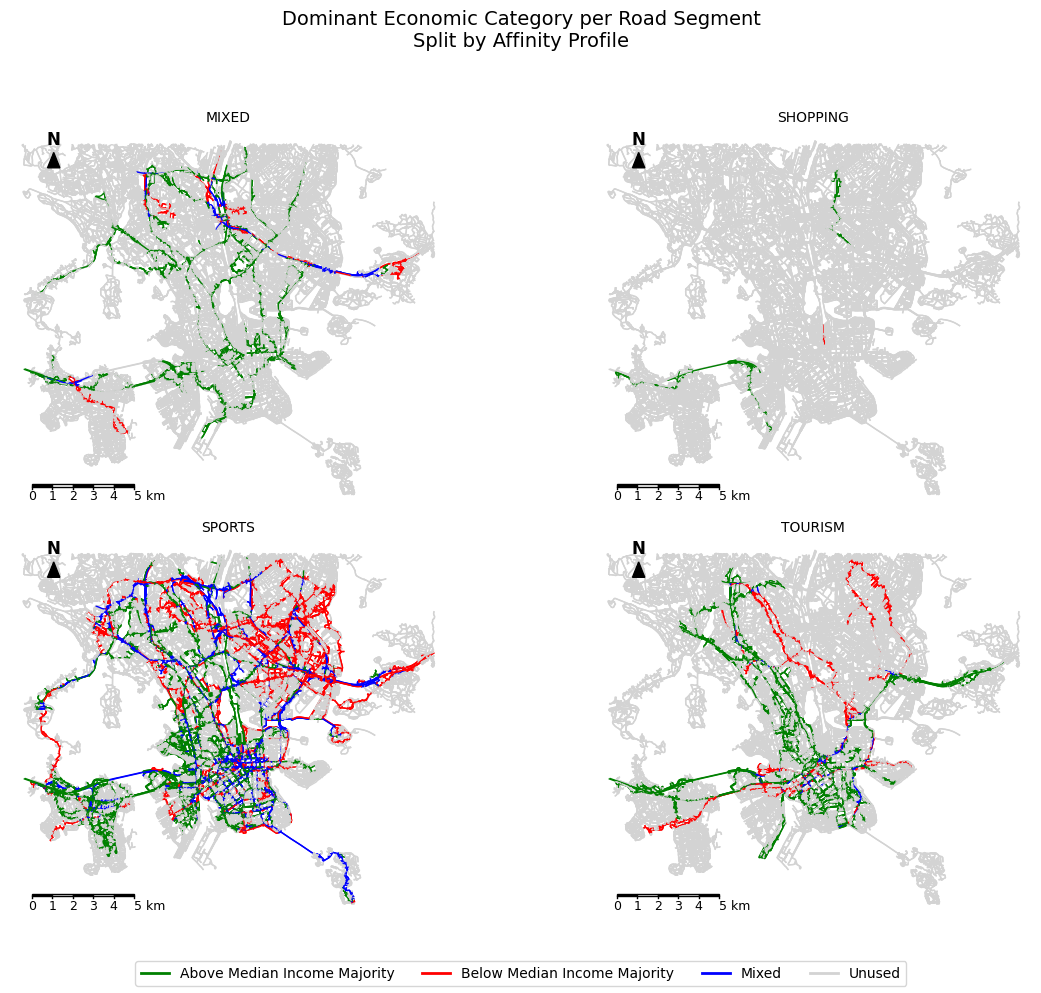

In [ ]:


# ---------------- Helpers (NEW) ----------------
def add_north_arrow(ax, size=750, xy=(0.10, 0.90)):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    dx, dy = x1 - x0, y1 - y0
    x = x0 + dx * xy[0]; y = y0 + dy * xy[1]
    tip = (x, y + size); left = (x - size * 0.4, y); right = (x + size * 0.4, y)
    arrow = plt.Polygon([tip, left, right], closed=True, color='black', zorder=10)
    ax.add_patch(arrow)
    ax.text(x, y + size * 1.25, 'N', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black', zorder=11)

def add_scalebar(ax, length_km=5, segments=5, location='lower left'):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    dx, dy = x1 - x0, y1 - y0
    bar_length = length_km * 1000.0
    seg_len = bar_length / segments
    margin_x = dx * 0.05; margin_y = dy * 0.05
    bar_h = dy * 0.007; tick_h = bar_h * 0.8; lab_off = bar_h * 1.3

    x_start = x0 + margin_x if location == 'lower left' else x1 - margin_x - bar_length
    y_start = y0 + margin_y

    # segments
    for i in range(segments):
        color = 'black' if i % 2 == 0 else 'white'
        rect = Rectangle((x_start + i * seg_len, y_start), seg_len, bar_h,
                         facecolor=color, edgecolor='black', lw=1, zorder=10)
        ax.add_patch(rect)

    # ticks + labels
    for i in range(segments + 1):
        xt = x_start + i * seg_len
        ax.plot([xt, xt], [y_start, y_start - tick_h], color='black', lw=1)
        if i < segments:
            ax.text(xt, y_start - lab_off, f"{int(i * seg_len / 1000)}",
                    ha='center', va='top', fontsize=9)
        else:
            ax.text(xt, y_start - lab_off, f"{int(i * seg_len / 1000)} km",
                    ha='left', va='top', fontsize=9)


city_center = (60.1695, 24.9354)
G = ox.graph_from_point(city_center, dist=5000, network_type='all')
G_proj = ox.project_graph(G, to_crs="EPSG:3857")
edges_gdf = ox.graph_to_gdfs(G_proj, nodes=False)

routes_web = routes.to_crs(3857)
routes_web = routes_web[routes_web["Economic Category"].isin(["Rich", "Poor"])]

affinity_profiles = sorted(routes_web["Affinity Profile"].dropna().unique())

def iter_lines(geom):
    if isinstance(geom, LineString):
        yield geom
    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            if isinstance(g, LineString):
                yield g

xmin, ymin, xmax, ymax = edges_gdf.total_bounds
pad_x = (xmax - xmin) * 0.03
pad_y = (ymax - ymin) * 0.03
extent = (xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y)

N_COLS, N_ROWS = 2, 2
per_page = N_COLS * N_ROWS
n_pages = math.ceil(len(affinity_profiles) / per_page)

for page in range(n_pages):
    start = page * per_page
    chunk = affinity_profiles[start:start + per_page]
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 10))
    axes = axes.flatten()

    for i, affinity in enumerate(chunk):
        ax = axes[i]
        subset = routes_web[routes_web["Affinity Profile"] == affinity]

        edge_use = defaultdict(lambda: {"Rich": 0, "Poor": 0})
        for _, row in subset.iterrows():
            econ_cat = row["Economic Category"]; geom = row.geometry
            if pd.isna(econ_cat) or geom is None:
                continue
            for line in iter_lines(geom):
                touched = edges_gdf[edges_gdf.intersects(line)].index
                for edge_idx in touched:
                    edge_use[edge_idx][econ_cat] += 1

        edge_colors = []
        for edge_idx, _edge in edges_gdf.iterrows():
            counts = edge_use.get(edge_idx, {"Rich": 0, "Poor": 0})
            total = counts["Rich"] + counts["Poor"]
            if total == 0:
                color = "lightgray"
            else:
                rshare = counts["Rich"] / total
                color = "green" if rshare > 0.7 else ("red" if rshare < 0.3 else "blue")
            edge_colors.append(color)

        edges_gdf.plot(ax=ax, color=edge_colors, linewidth=1)
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])

        title_txt = "MIXED" if str(affinity).strip().lower() == "mixed" else str(affinity)
        ax.set_title(textwrap.fill(title_txt, width=28), fontsize=10)
        ax.axis("off")

        add_north_arrow(ax, size=750, xy=(0.10, 0.90))
        add_scalebar(ax, length_km=5, segments=5, location='lower left')

    for j in range(len(chunk), len(axes)):
        axes[j].axis("off")

    legend_elements = [
        Line2D([0], [0], color='green', lw=2, label='Above Median Income Majority'),
        Line2D([0], [0], color='red', lw=2, label='Below Median Income Majority'),
        Line2D([0], [0], color='blue', lw=2, label='Mixed'),
        Line2D([0], [0], color='lightgray', lw=2, label='Unused')
    ]
    fig.suptitle("Dominant Economic Category per Road Segment\nSplit by Affinity Profile", fontsize=14)
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=True)

    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()

#(OpenAI, 2025s; OpenAI, 2025j)

In this simulation, the aim is to model how road network usage in Helsinki varies by income group under different levels of socio-spatial avoidance, using a modified, Schelling-inspired approach. The objective is to understand how individuals from different economic backgrounds may adapt their travel behaviour when they exhibit a preference to avoid routes that are heavily dominated by the opposite group. This analysis is particularly relevant for assessing how socio-economic segregation can emerge in urban mobility patterns and how such behaviour may reshape access to everyday infrastructure.

The simulation begins by loading the road network within a 10-kilometre radius of central Helsinki. Real-world GPS trajectories from the mobility dataset are then used to calculate the frequency of use for each road segment by individuals from either above- or below-median income groups. This is done by intersecting each user’s LineString trajectory with the road segments and incrementing group-specific usage counters. These raw counts are subsequently used to assign each road segment a dominant group label, applying a majority rule that requires one group to account for at least 70 percent of total usage in order to be classified as dominant.

The core of the simulation involves a threshold-based routing process, in which users are modelled as agents who selectively avoid road segments that are predominantly used by the opposite economic group. This simulates preference-driven mobility, where route choice is influenced not only by spatial efficiency but also by social tolerance. Each agent’s tolerance is determined by a threshold value that defines the maximum allowable share of the opposite group on a given route. This threshold ranges from 1.0, representing complete tolerance, to 0.1, representing minimal tolerance.

For each threshold value, the simulation proceeds through several sequential steps. First, the original route taken by the user is evaluated. If all road segments along the route meet the group’s tolerance threshold and are not overly dominated by the opposite group, the path is accepted and counted as used. If the route includes any segments that exceed the tolerance threshold, the system attempts to calculate a new shortest path between the same start and end points, ensuring that the alternative route avoids high-exposure segments. This path search is conducted using the underlying road network graph and uses segment length as the basis for edge weighting. If this constrained shortest path cannot be found, the system initiates a fallback mechanism by conducting a constrained breadth-first search to explore up to three alternative simple paths. This step represents an agent attempting several realistic re-routing strategies before abandoning the trip. If no valid route is found after these attempts, the trip is recorded as failed, and the user is considered to have cancelled travel due to excessive exposure to dissimilar users.

The simulation results highlight the nonlinear and emergent nature of segregation in urban mobility. Even modest reductions in social tolerance can lead to a significant decline in shared road usage, illustrating the vulnerability of mixed-use infrastructure under conditions of preference-driven avoidance. This experiment is intended as an exploratory tool to provide insights into how avoidance behaviour might influence experienced segregation. It offers a preliminary perspective on how individuals may adapt their travel routes in response to the presence of others from different socioeconomic backgrounds during daily activities. As such, the simulation provides initial insight into the types of mobility patterns that may emerge under varying levels of avoidance behaviour, with some potential implications for understanding experienced segregation and next-location prediction through the incorporation of segregation-based metrics.

To the best of the author’s knowledge, this study is the first to apply a Schelling-inspired simulation to model mobility avoidance behaviour using real-world road network data. While this work remains exploratory, it provides a foundation for future research. One possible direction is the integration of this simulation approach into agent-based or behaviourally informed machine learning models, which could enhance the realism and interpretability of urban mobility predictions by capturing the interplay between spatial constraints and social dynamics.

Threshold 0.1: 100%|██████████| 2753/2753 [31:44<00:00,  1.45it/s]


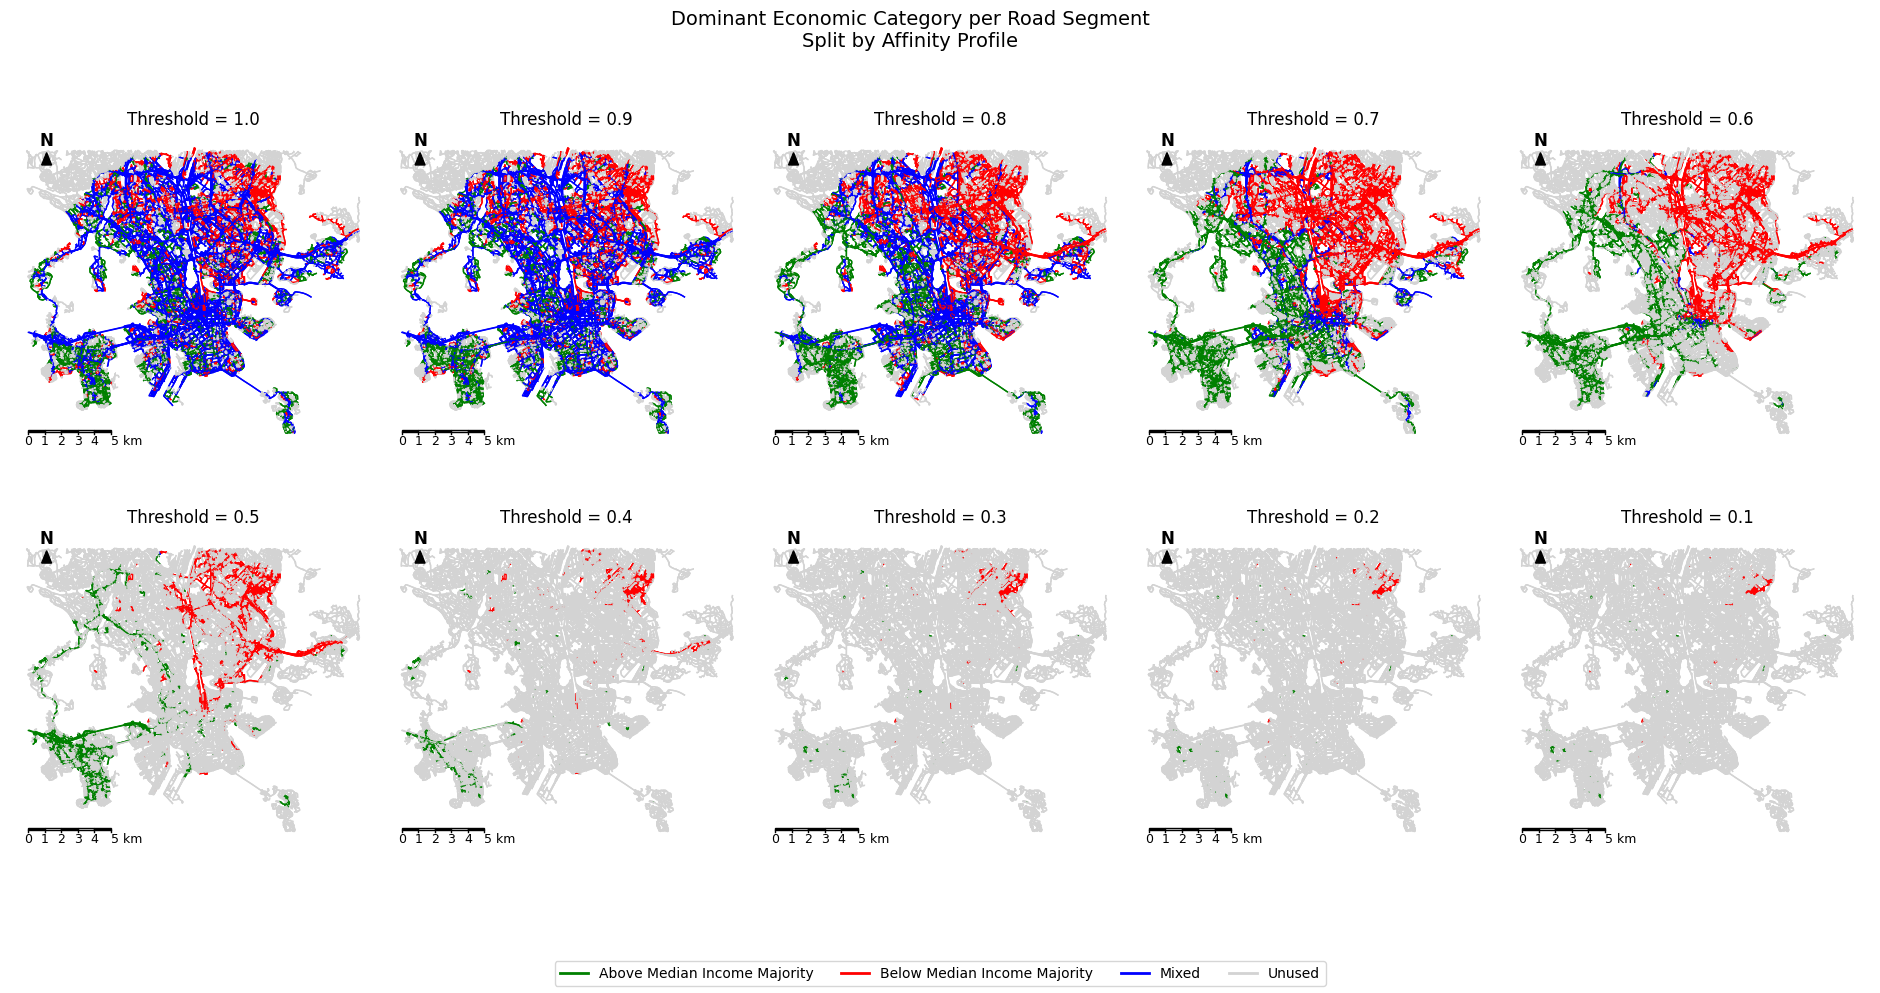

In [ ]:


def add_north_arrow(ax, size=750, xy=(0.10, 0.90)): #add north arrow
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    dx, dy = x1 - x0, y1 - y0
    x = x0 + dx * xy[0]; y = y0 + dy * xy[1]
    tip = (x, y + size)
    left = (x - size * 0.4, y)
    right = (x + size * 0.4, y)
    arrow = plt.Polygon([tip, left, right], closed=True, color='black', zorder=10)
    ax.add_patch(arrow)
    ax.text(x, y + size * 1.25, 'N', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black', zorder=11)

def add_scalebar(ax, length_km=5, segments=5, location='lower left'): #add scale bar
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    dx, dy = x1 - x0, y1 - y0
    bar_length = length_km * 1000.0
    seg_len = bar_length / segments
    margin_x = dx * 0.05; margin_y = dy * 0.05
    bar_h = dy * 0.007; tick_h = bar_h * 0.8; lab_off = bar_h * 1.3

    x_start = x0 + margin_x if location == 'lower left' else x1 - margin_x - bar_length
    y_start = y0 + margin_y

    for i in range(segments):
        color = 'black' if i % 2 == 0 else 'white'
        rect = Rectangle((x_start + i * seg_len, y_start), seg_len, bar_h,
                         facecolor=color, edgecolor='black', lw=1, zorder=10)
        ax.add_patch(rect)

    for i in range(segments + 1):
        xt = x_start + i * seg_len
        ax.plot([xt, xt], [y_start, y_start - tick_h], color='black', lw=1, zorder=11)
        label = f"{int(i * seg_len / 1000)}" if i < segments else f"{int(i * seg_len / 1000)} km"
        ha = 'center' if i < segments else 'left'
        ax.text(xt, y_start - lab_off, label, ha=ha, va='top', fontsize=9, zorder=12)

#setup
city_center = (60.1695, 24.9354)
THRESHOLDS = [round(x, 1) for x in np.arange(1.0, 0.0, -0.1)]  # 1.0 → 0.1

G = ox.graph_from_point(city_center, dist=5000, network_type='all')
G_proj = ox.project_graph(G, to_crs="EPSG:3857")
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj, nodes=True, edges=True)
edges_proj = edges_proj.reset_index()

routes = gpd.read_file("/content/drive/My Drive/Thesis/Data/Human Mobility/routes_shortest_path.geojson").to_crs(3857)


edge_use = defaultdict(lambda: {"Rich": 0, "Poor": 0}) #count how often each road segment is used by either group
for _, row in routes.iterrows(): #loop over all user trajectories
    group = row.get("Economic Category") #skip invalid rows
    if not isinstance(row.geometry, LineString) or group not in ("Rich", "Poor"):
        continue
    intersected = edges_proj[edges_proj.intersects(row.geometry)].index #find intersecting road segments
    for edge_idx in intersected: #update usage counters
        edge_use[edge_idx][group] += 1

#classify road segment dominance
def classify_dominance(counts):
    total = counts["Rich"] + counts["Poor"] #compute total usage
    if total == 0:
        return "Unused", 0.0
    share = counts["Rich"] / total #compute Rich user share
    if share > 0.7:
        return "Rich", share #assign dominance label
    elif share < 0.3:
        return "Poor", share
    else:
        return "Mixed", share
#add dominance info to edges_proj
edges_proj["dominant_group"] = ""
edges_proj["rich_share"] = 0.0
for edge_idx in edges_proj.index:
    counts = edge_use.get(edge_idx, {"Rich": 0, "Poor": 0})
    label, share = classify_dominance(counts)
    edges_proj.at[edge_idx, "dominant_group"] = label
    edges_proj.at[edge_idx, "rich_share"] = share


edge_status = {}
for idx, row in edges_proj.iterrows():
    u, v = row["u"], row["v"]
    edge_status[(u, v)] = {"dominant": row["dominant_group"], "rich_share": row["rich_share"]} #build a fast lookup edge_status dictionary

def edge_allowed(agent_group, edge_dominant_group, rich_share, threshold): #define rules for social avoidance
    dissimilar = (1 - rich_share) if agent_group == "Rich" else rich_share
    return dissimilar <= threshold

def is_path_allowed(path, group, threshold): #checks whether a full path is acceptable for an agent
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        info = edge_status.get((u, v)) or edge_status.get((v, u))
        if info and not edge_allowed(group, info["dominant"], info["rich_share"], threshold):
            return False
    return True


fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()


for ax, threshold in zip(axes, THRESHOLDS): #loops over a list of subplot axes for each of the thresholds
    usage_counter = defaultdict(lambda: {"Rich": 0, "Poor": 0}) #initialize counters
    fail_counter = 0

    for _, row in tqdm(routes.iterrows(), total=len(routes), desc=f"Threshold {threshold:.1f}"): #loop through all user trajectories
        group = row.get("Economic Category") #skip invalid rows
        if not isinstance(row.geometry, LineString) or group not in ("Rich", "Poor"):
            continue

        #try to use the original real-world route
        intersected = edges_proj[edges_proj.intersects(row.geometry)]
        if not intersected.empty:
            all_ok = True
            for edge_idx in intersected.index:
                u, v = edges_proj.at[edge_idx, "u"], edges_proj.at[edge_idx, "v"]
                info = edge_status.get((u, v)) or edge_status.get((v, u))
                if info and not edge_allowed(group, info["dominant"], info["rich_share"], threshold):
                    all_ok = False; break
            if all_ok:
                for edge_idx in intersected.index:
                    u, v = edges_proj.at[edge_idx, "u"], edges_proj.at[edge_idx, "v"]
                    usage_counter[(u, v)][group] += 1
                continue

        #try to reroute using shortest path
        origin = destination = None
        path = None
        try:
            xs = [row.geometry.coords[0][0], row.geometry.coords[-1][0]]
            ys = [row.geometry.coords[0][1], row.geometry.coords[-1][1]]
            origin, destination = ox.distance.nearest_nodes(G_proj, X=xs, Y=ys)
            path = nx.shortest_path(G_proj, origin, destination, weight="length")
        except Exception:
            path = None
        #if the shortest path is allowed, use it
        if path and is_path_allowed(path, group, threshold):
            for i in range(len(path) - 1):
                usage_counter[(path[i], path[i + 1])][group] += 1
            continue
        #try fallback simple paths (max 3 steps)

        found = False
        if origin is not None and destination is not None:
            try:
                for alt_path in nx.all_simple_paths(G_proj, source=origin, target=destination, cutoff=3):
                    if is_path_allowed(alt_path, group, threshold):
                        for i in range(len(alt_path) - 1):
                            usage_counter[(alt_path[i], alt_path[i + 1])][group] += 1
                        found = True
                        break
            except Exception:
                pass
        #if all failed, count as failure
        if not found:
            fail_counter += 1

    #color the road segments
    edge_colors = []
    for _, r in edges_proj.iterrows():
        u, v = r["u"], r["v"]
        counts = usage_counter.get((u, v)) or usage_counter.get((v, u)) or {"Rich": 0, "Poor": 0}
        total = counts["Rich"] + counts["Poor"]
        if total == 0:
            color = "lightgray"
        else:
            share = counts["Rich"] / total
            if share > 0.7:
                color = "green"   # Above median income majority
            elif share < 0.3:
                color = "red"     # Below median income majority
            else:
                color = "blue"    # Mixed
        edge_colors.append(color)


    edges_proj.plot(ax=ax, color=edge_colors, linewidth=1)
    ax.set_title(f"Threshold = {threshold:.1f}", fontsize=12)
    ax.axis("off")


    add_north_arrow(ax, size=750, xy=(0.10, 0.90))
    add_scalebar(ax, length_km=5, segments=5, location='lower left')


legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='Above Median Income Majority'),
    Line2D([0], [0], color='red', lw=2, label='Below Median Income Majority'),
    Line2D([0], [0], color='blue', lw=2, label='Mixed'),
    Line2D([0], [0], color='lightgray', lw=2, label='Unused'),
]
fig.suptitle("Dominant Economic Category per Road Segment\nSplit by Affinity Profile", fontsize=14)
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=True)


fig.subplots_adjust(bottom=0.12, wspace=0.02, hspace=0.10)
plt.show()

# (OpenAI, 2025ai; OpenAI, 2025j)

# Next Location Prediction

## Splitting Dataset

This code sets up a preprocessing pipeline to simulate an inductive learning scenario for next-location prediction based on human mobility data in Helsinki. The primary aim is to prepare training and testing datasets where the model is expected to generalize to previously unseen locations, similar to real-world use cases in which new points of interest (POIs) regularly appear. This is based on the study of Wang et al (2025) The logic integrates spatial filtering, POI matching, and data partitioning in a way that reflects both methodological rigor and practical relevance

the data is split into training and testing sets based on time as this is a norm in next location prediction (Feng et al., 2018). Records from July and August form the training data, while records from September are used for testing. To introduce inductive difficulty, 10 percent of the POIs that appear in the training data are randomly selected and removed from the training set, although they remain in the test set. This simulates the scenario where a model must predict visits to new or emerging POIs that were not part of its training experience.

In [ ]:




#path and parameter setup
city_center = (60.1695, 24.9354)
mobility_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv"
poi_path = "/content/drive/My Drive/Thesis/Data/POI/Combined_POI/Combined_POIs_for_JCD_Finland_(micodes).csv"
train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
test_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"
chunk_size = 100_000

def haversine(lat1, lon1, lat2, lon2): #computes great-circle distance between two lat/lon coordinates
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

#load and filter POIs
pois = pd.read_csv(poi_path).dropna(subset=["LATITUDE", "LONGITUDE"])
pois = pois.rename(columns={"LATITUDE": "poi_lat", "LONGITUDE": "poi_lon"})
pois["distance_km"] = pois.apply(lambda row: haversine(row["poi_lat"], row["poi_lon"], *city_center), axis=1)
pois = pois[pois["distance_km"] <= 10].drop_duplicates(["poi_lat", "poi_lon"]).reset_index(drop=True)
poi_tree = cKDTree(pois[["poi_lat", "poi_lon"]].values.astype(np.float32)) #Constructs a KD-Tree for matching each user GPS point to the nearest POI

train_chunks = []
test_chunks = []

for chunk in tqdm(pd.read_csv(mobility_path, chunksize=chunk_size, low_memory=False), desc="Processing"): #process chunked mobility data
    chunk = chunk.dropna(subset=["lat", "lon", "Userid", "timestamp"]) #removes invalid rows
    chunk = chunk.astype({"lat": float, "lon": float, "timestamp": int, "Userid": str}) #ensures correct data types
    chunk["datetime"] = pd.to_datetime(chunk["timestamp"], unit="s")
    chunk = chunk[chunk["datetime"].dt.year == 2024]
    chunk["month"] = chunk["datetime"].dt.month
    chunk["distance_km"] = chunk.apply(lambda row: haversine(row["lat"], row["lon"], *city_center), axis=1)
    chunk = chunk[chunk["distance_km"] <= 10] #only keep user points within 10 km of Helsinki center
    coords = chunk[["lat", "lon"]].values
    distances, indices = poi_tree.query(coords, k=3) #find the 3 nearest POIs
    chunk["loc_id"] = [i[0] if any(d < 0.0005 for d in dists) else -1 for dists, i in zip(distances, indices)] #assign the closest poi as loc_idf if any poi is within 0.0005 degrees (or around 55 meters)
    chunk = chunk[chunk["loc_id"] != -1] #removes all rows that couldn't be matched to any POI
    train_chunks.append(chunk[chunk["month"].isin([7, 8])]) #july and august for training data
    test_chunks.append(chunk[chunk["month"] == 9]) #september for test data

#combine all processed chunks into single DataFrames
train_df = pd.concat(train_chunks, ignore_index=True)
test_df = pd.concat(test_chunks, ignore_index=True)
all_train_locs = train_df["loc_id"].unique()
L_new = set(random.sample(list(all_train_locs), int(0.10 * len(all_train_locs)))) #select 10% of POIs from training set at random
train_df = train_df[~train_df["loc_id"].isin(L_new)] #remove the 10% from the training set to simulate inductive prediction. Theese POIs still exist in the test set

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows | Removed {len(L_new)} inductive POIs")

#(Wang, 2025; OpenAI, 2025ad; OpenAI, 2025af)

/tmp/ipython-input-3190161533.py:26: DtypeWarning: Columns (4,5,17,27) have mixed types. Specify dtype option on import or set low_memory=False.
  pois = pd.read_csv(poi_path).dropna(subset=["LATITUDE", "LONGITUDE"])
Processing: 262it [10:15,  2.35s/it]


Train: 3085993 rows | Test: 1624759 rows | Removed 1151 inductive POIs


The training dataset contains approximately 3.1 million GPS points from 2,855 users, covering 10,360 distinct POIs. The test set contains about 1.6 million points from 2,752 users and includes 11,266 POIs. The fact that the number of POIs in the test set is higher than in the training set confirms that an inductive learning setup has been applied correctly.

In [ ]:


train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
test_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"

train_df = pd.read_csv(train_path, usecols=["Userid", "lat", "lon", "loc_id"])
test_df  = pd.read_csv(test_path,  usecols=["Userid", "lat", "lon", "loc_id"])

def print_summary(name, df):
    print(f"{name} Summary:")
    print(f"Unique users: {df['Userid'].nunique()}")
    print(f"GPS points (rows): {len(df)}")
    print(f"Unique POIs (loc_id): {df['loc_id'].nunique()}")
    print()

print_summary("Train", train_df)
print_summary("Test", test_df)

#(OpenAI, 2025u)

Train Summary:
Unique users: 2855
GPS points (rows): 3085993
Unique POIs (loc_id): 10360

Test Summary:
Unique users: 2752
GPS points (rows): 1624759
Unique POIs (loc_id): 11266



In [ ]:


files = {
    "Combined": "/content/drive/My Drive/Thesis/Data/Human Mobility/combined_human_mobility.csv",
    "Filtered (20 days)": "/content/drive/My Drive/Thesis/Data/Human Mobility/filtered_mobility_data_20days.csv",
    "With Econ Category": "/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv",
    "Train": "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv",
    "Test": "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"
}

chunk_size = 100_000
user_counts = []
row_counts = []
labels = []

for label, path in files.items():
    unique_users = set()
    total_rows = 0

    try:
        for chunk in pd.read_csv(path, usecols=["Userid"], chunksize=chunk_size, low_memory=False):
            unique_users.update(chunk["Userid"].dropna().unique())
            total_rows += len(chunk)

        user_counts.append(len(unique_users))
        row_counts.append(total_rows)
        labels.append(label)

    except Exception as e:
        print(f"Error reading {label}: {e}")
        user_counts.append(0)
        row_counts.append(0)

The first chart displays the number of unique users at each stage. It starts with the full dataset, which contains more than 640,000 users. The dataset is then filtered to include only those users who were consistently active for at least 20 days per month. From this group, only users whose movements are mostly within Helsinki are retained. The final two bars represent the training and testing sets, each containing just under 3,000 users. This progressive narrowing shows how the user population was refined to ensure spatial focus, temporal consistency, and data reliability.

The second chart focuses on the number of GPS data points. Initially, the dataset includes almost 400 million records. After filtering for consistency and location, only a small portion of this data remains. The final training set contains around 3 million rows, while the test set includes about 1.6 million.

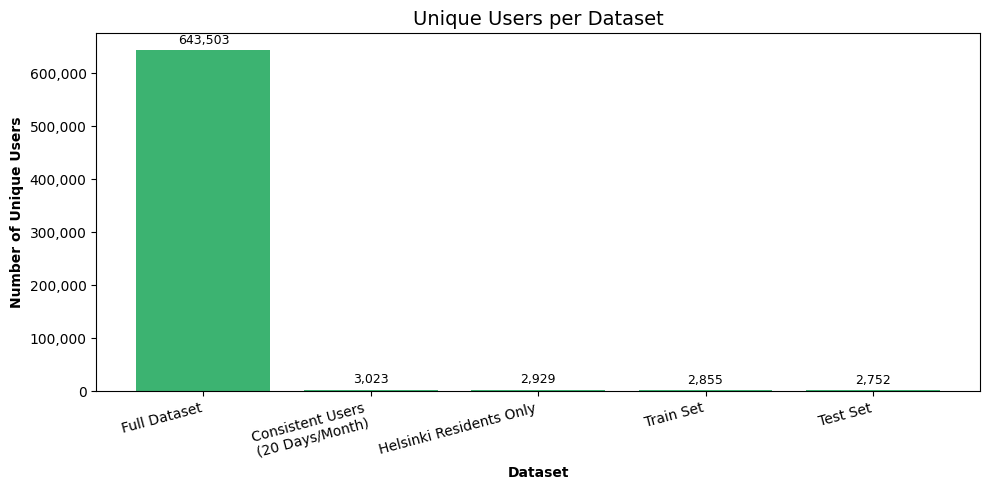

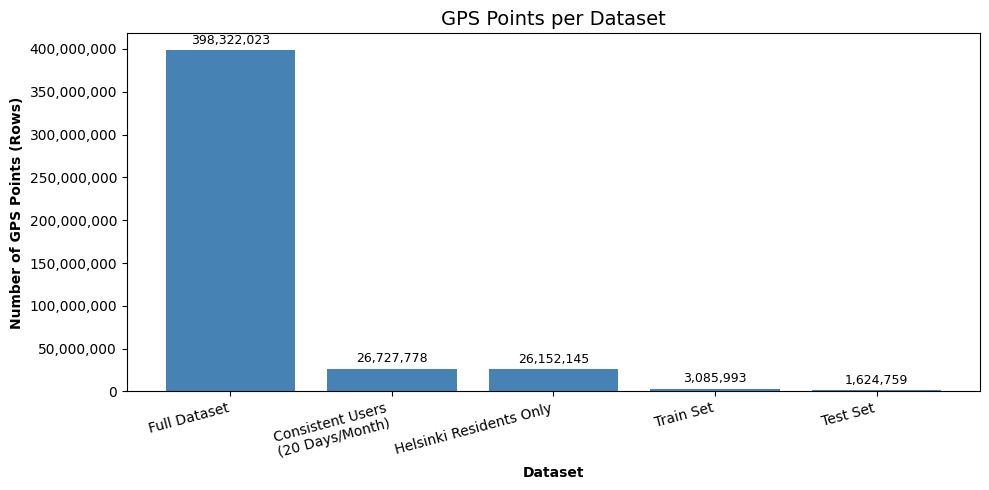

In [ ]:


custom_labels = [
    "Full Dataset",
    "Consistent Users\n(20 Days/Month)",
    "Helsinki Residents Only",
    "Train Set",
    "Test Set"
]


plt.figure(figsize=(10, 5))
plt.bar(custom_labels, user_counts, color='mediumseagreen')
plt.ylabel("Number of Unique Users", fontweight="bold")
plt.xlabel("Dataset", fontweight="bold")
plt.title("Unique Users per Dataset", fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, val in enumerate(user_counts):
    plt.text(i, val + max(user_counts)*0.01, f"{val:,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(custom_labels, row_counts, color='steelblue')
plt.ylabel("Number of GPS Points (Rows)", fontweight="bold")
plt.xlabel("Dataset", fontweight="bold")
plt.title("GPS Points per Dataset", fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, val in enumerate(row_counts):
    plt.text(i, val + max(row_counts)*0.01, f"{val:,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#(OpenAI, 2025q)

This code is designed to explore and visualize the most common affinity profiles observed in a human mobility dataset. Affinity profiles represent the categories of places users have previously visited, such as “Automotive Repair Services” or “Educational Services.” By identifying the top ten profiles in both the training and test datasets, the goal is to better understand user behavior patterns and how they may shift over time. This kind of analysis is especially useful for supporting next-location prediction models, where understanding prior user preferences can help improve the accuracy of recommendations or forecasts.

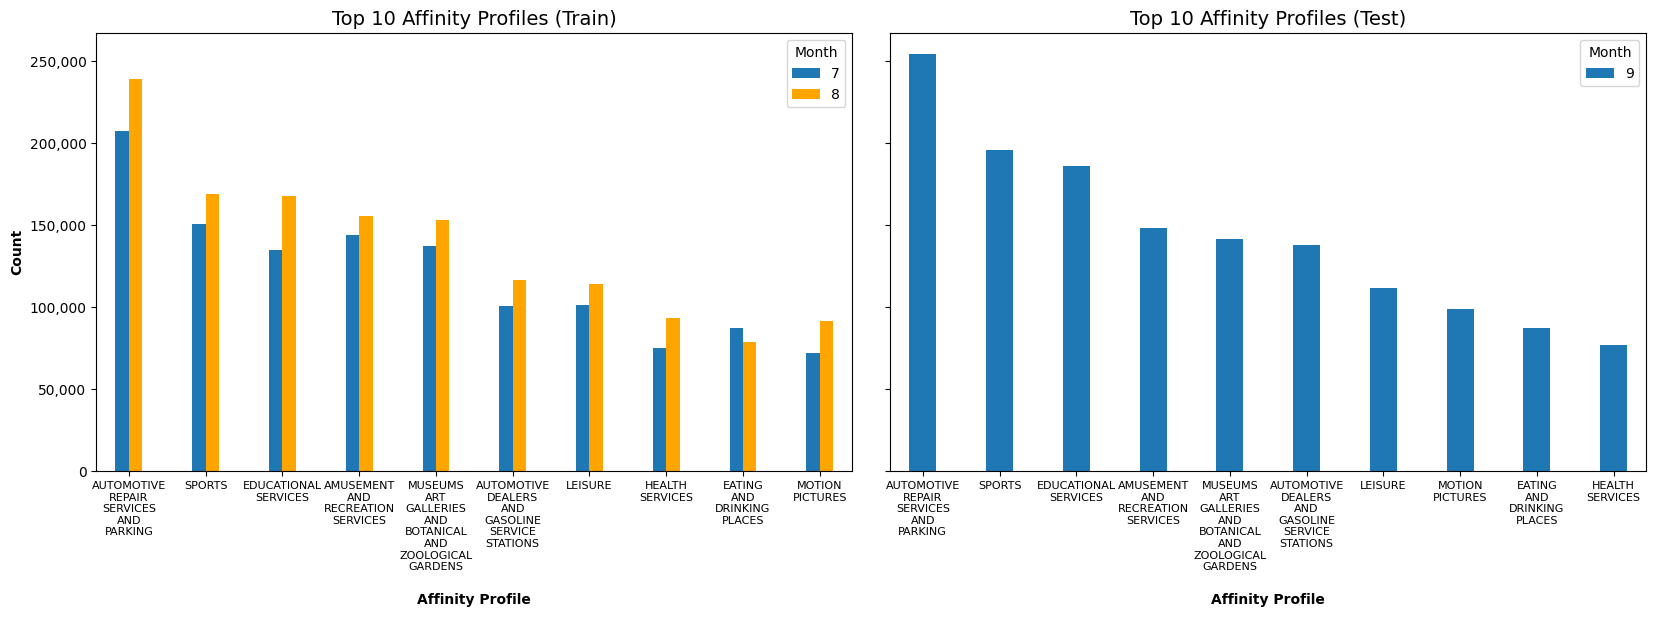

In [ ]:



def clean_label(label):
    label = re.sub(r'__+', '_', label)
    label = label.strip()
    return label.replace('_', '\n')


def process_file(csv_path):
    df = pd.read_csv(csv_path, low_memory=False)
    df = df.dropna(subset=["Previous Affinity Profile", "month"])
    df["Previous Affinity Profile"] = df["Previous Affinity Profile"].astype(str)
    df["Previous Affinity Profile"] = df["Previous Affinity Profile"].apply(lambda x: re.sub(r'__+', '_', x).strip())

    top10 = df["Previous Affinity Profile"].value_counts().head(10).index
    df_top = df[df["Previous Affinity Profile"].isin(top10)]
    grouped = df_top.groupby(["Previous Affinity Profile", "month"]).size().reset_index(name="count")

    pivot = grouped.pivot(index="Previous Affinity Profile", columns="month", values="count").fillna(0)
    pivot["total"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False).drop(columns="total")

    pivot.index = [clean_label(label) for label in pivot.index]
    return pivot


train_pivot = process_file("/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv")
test_pivot  = process_file("/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv")


fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

def plot_pivot(ax, pivot, title):
    pivot.plot(kind="bar", ax=ax, width=0.35, color=["tab:blue", "orange"])
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Affinity Profile", fontweight="bold", labelpad=15)
    ax.set_ylabel("Count", fontweight="bold")
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title="Month")

plot_pivot(axes[0], train_pivot, "Top 10 Affinity Profiles (Train)")
plot_pivot(axes[1], test_pivot,  "Top 10 Affinity Profiles (Test)")


plt.subplots_adjust(bottom=0.15, wspace=0.05)
plt.show()

#(OpenAI, 2025am)

The resulting bar plots show the top economic categories across July and August (training period) and September (test period). These visual comparisons help ensure that both economic groups are adequately represented across time and between datasets.

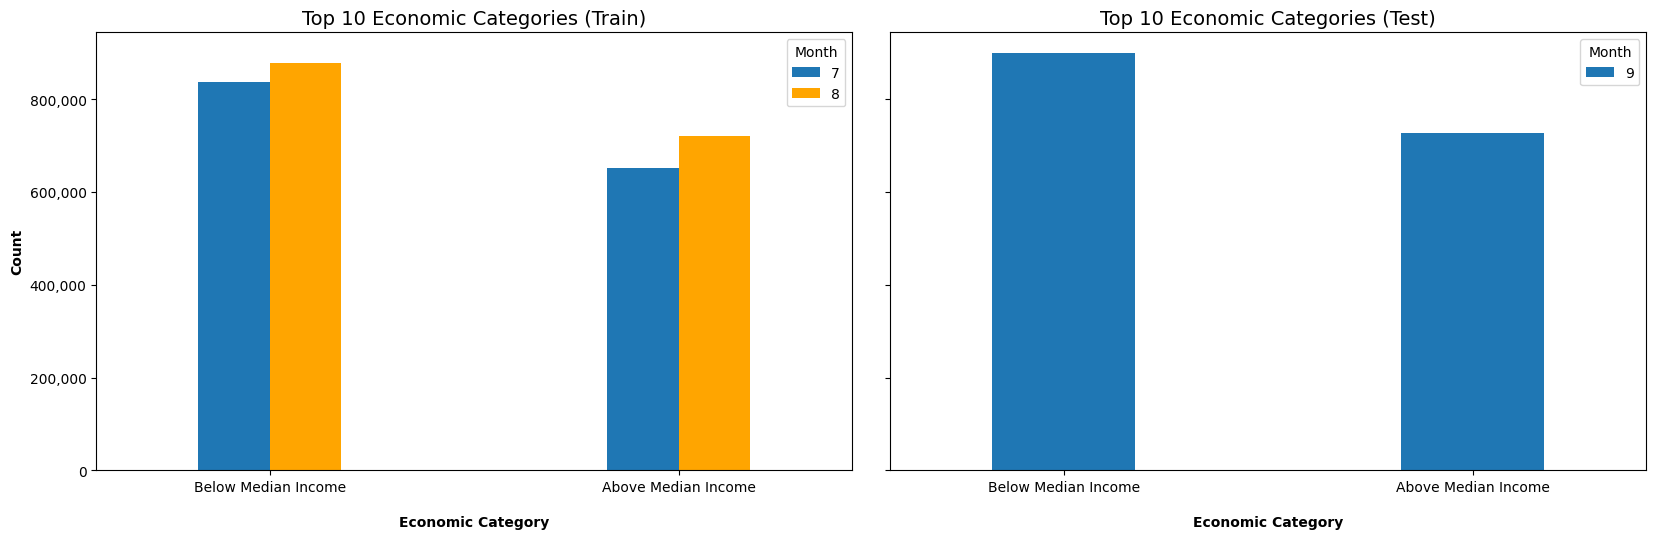

In [ ]:



rename_labels = {
    "Poor": "Below Median Income",
    "Rich": "Above Median Income"
}


def clean_label(label):
    label = re.sub(r'__+', '_', label)
    label = label.strip()
    return label.replace('_', '\n')


def process_file(csv_path):
    df = pd.read_csv(csv_path, low_memory=False)
    df = df.dropna(subset=["Economic Category", "month"])
    df["Economic Category"] = df["Economic Category"].astype(str)
    df["Economic Category"] = df["Economic Category"].apply(lambda x: re.sub(r'__+', '_', x).strip())

    top10 = df["Economic Category"].value_counts().head(10).index
    df_top = df[df["Economic Category"].isin(top10)]
    grouped = df_top.groupby(["Economic Category", "month"]).size().reset_index(name="count")

    pivot = grouped.pivot(index="Economic Category", columns="month", values="count").fillna(0)
    pivot["total"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False).drop(columns="total")


    pivot.index = [clean_label(rename_labels.get(label, label)) for label in pivot.index]
    return pivot


train_pivot = process_file("/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv")
test_pivot  = process_file("/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv")


fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

def plot_pivot(ax, pivot, title):
    pivot.plot(kind="bar", ax=ax, width=0.35, color=["tab:blue", "orange"])
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Economic Category", fontweight="bold", labelpad=15)
    ax.set_ylabel("Count", fontweight="bold")
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title="Month")

plot_pivot(axes[0], train_pivot, "Top 10 Economic Categories (Train)")
plot_pivot(axes[1], test_pivot,  "Top 10 Economic Categories (Test)")


plt.subplots_adjust(bottom=0.15, wspace=0.05)
plt.show()

#(OpenAI, 2025ag)

[TRAIN] Total rows: 3,085,993, >0: 274,380, Share: 8.89%
[TEST]  Total rows: 1,624,759, >0: 133,868, Share: 8.24%


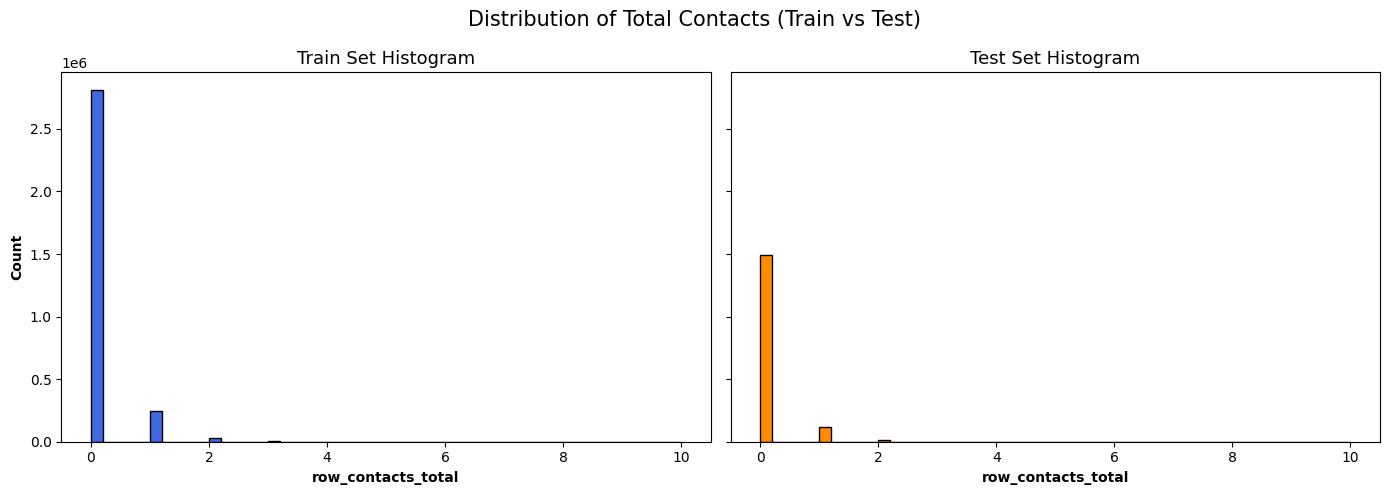

In [ ]:


# --- File paths ---
train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
test_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"
col = "row_contacts_total"
chunksize = 100_000
nbins = 50

# --- Step 1: Determine global min and max across both files ---
min_v, max_v = None, None
for path in [train_path, test_path]:
    for chunk in pd.read_csv(path, usecols=[col], chunksize=chunksize, low_memory=False):
        s = pd.to_numeric(chunk[col], errors="coerce").dropna()
        if s.empty:
            continue
        vmin, vmax = s.min(), s.max()
        min_v = vmin if min_v is None else min(min_v, vmin)
        max_v = vmax if max_v is None else max(max_v, vmax)

if min_v is None:
    raise ValueError(f"No valid numeric data found in column '{col}'.")

bin_edges = np.linspace(min_v, max_v, nbins + 1)
widths = np.diff(bin_edges)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Step 2: Histogram + stats function ---
def compute_histogram_and_stats(path):
    hist = np.zeros(nbins, dtype=np.float64)
    total_rows = 0
    rows_gt_zero = 0
    for chunk in pd.read_csv(path, usecols=[col], chunksize=chunksize, low_memory=False):
        s = pd.to_numeric(chunk[col], errors="coerce").dropna()
        if s.empty:
            continue
        counts, _ = np.histogram(s.values, bins=bin_edges)
        hist += counts
        total_rows += s.size
        rows_gt_zero += (s > 0).sum()
    return hist, total_rows, rows_gt_zero

# --- Step 3: Compute for both train and test ---
train_hist, train_total, train_gt0 = compute_histogram_and_stats(train_path)
test_hist, test_total, test_gt0 = compute_histogram_and_stats(test_path)

# --- Step 4: Print summary ---
print(f"[TRAIN] Total rows: {train_total:,}, >0: {train_gt0:,}, Share: {train_gt0/train_total:.2%}")
print(f"[TEST]  Total rows: {test_total:,}, >0: {test_gt0:,}, Share: {test_gt0/test_total:.2%}")

# --- Step 5: Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(centers, train_hist, width=widths, color='royalblue', edgecolor='black')
axes[0].set_title("Train Set Histogram", fontsize=13)
axes[0].set_xlabel("row_contacts_total", fontweight="bold")
axes[0].set_ylabel("Count", fontweight="bold")

axes[1].bar(centers, test_hist, width=widths, color='darkorange', edgecolor='black')
axes[1].set_title("Test Set Histogram", fontsize=13)
axes[1].set_xlabel("row_contacts_total", fontweight="bold")

fig.suptitle("Distribution of Total Contacts (Train vs Test)", fontsize=15)
plt.tight_layout()
plt.show()


## Base Models

### STRNN

This code represents a key part of the preprocessing pipeline for training a spatial-temporal deep learning model, specifically the Spatial-Temporal Recurrent Neural Network (STRNN), on human mobility data. The main goal is to transform raw GPS trajectory data into structured sequences of user movements that can be used for next-location prediction. It does this by converting each user's daily movements into fixed-length sliding windows, while also computing the spatial and temporal differences between visits.

In addition to location and timing, the model is also designed to incorporate social features. The script includes a set of additional segregation-related variables, which are passed as extra input features.
Each processed chunk is saved as a .pt file, which contains the encoded user ID, spatial and temporal differences, historical POI sequence, the prediction target, and extra social features.

In [ ]:


train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
save_dir   = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunks"
os.makedirs(save_dir, exist_ok=True)


window_size = 5
chunk_size  = 50_000
EXTRA_COLS = [
    "row_diff_econ_rate", "row_diff_prev_aff_rate", "row_contacts_total",
    "has_contact", "log_contacts", "econ_rate_smooth", "prev_rate_smooth"
]

#dictionaries for user and location indexing
user2idx, loc2idx = {}, {}
uid_counter, lid_counter = 0, 0
chunk_id = 0

#haversine function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

usecols = ["Userid","lat","lon","timestamp","loc_id"] + EXTRA_COLS

for chunk in pd.read_csv(train_path, chunksize=chunk_size, usecols=usecols, low_memory=False): #chunked Data Reading and Preprocessing
    chunk = chunk.dropna(subset=["Userid","lat","lon","timestamp","loc_id"])
    chunk["timestamp"] = pd.to_datetime(chunk["timestamp"], unit="s", utc=True, errors="coerce")
    chunk = chunk.dropna(subset=["timestamp"])
    time_seq = group["timestamp"].values.astype("datetime64[ns]")
    chunk = chunk.sort_values(["Userid","timestamp"])
    data = []

    for user_id, group in chunk.groupby("Userid"): #dplit the chunked data by user so it can process each person's mobility trajectory independently
        if len(group) <= window_size: #if the user has fewer than or equal to window_size (e.g. 5) points, they cannot form a sliding window
            continue
        if user_id not in user2idx:
            user2idx[user_id] = uid_counter
            uid_counter += 1
        uid = user2idx[user_id] #assigns the user a unique integer index
        group = group.sort_values("timestamp").reset_index(drop=True) #ensures the user’s records are in strict chronological order because this is really important for time-sequence models
        loc_seq = group["loc_id"].to_list() #extracts the full list of POI IDs
        time_seq = group["timestamp"].to_numpy() #converts the timestamp column into a NumPy array
        lat_seq = group["lat"].to_numpy()
        lon_seq = group["lon"].to_numpy()#needed to compute spatial distances between consecutive steps
        mapped_loc_seq = [] #store the integer-mapped version of loc_seq using loc2idx
        for loc in loc_seq: #iterates through each POI visited by the user in order
            if loc not in loc2idx: #assign it a new integer ID if this location has not been seen before
                loc2idx[loc] = lid_counter #assigna a new integer ID to this location in the dictionary
                lid_counter += 1 #increments the counter so that the next new POI gets a new ID
            mapped_loc_seq.append(loc2idx[loc]) #convert the raw loc into its mapped integer index

        for t in range(window_size, len(group)): #loop over the user's trajectory to generate one training sample per window
            prev_locs = mapped_loc_seq[t-window_size:t] #extract the previous window_size locations visited by the user
            target    = mapped_loc_seq[t] #next POI that the model will try to predict
            dt = time_seq[t-window_size+1:t+1] - time_seq[t-window_size:t] #compute the difference between consecutive timestamps in the window
            tdiffs_min = (dt.astype("timedelta64[m]").astype(np.float32)) #convert time differences as float32
            ldiffs_km = []
            for j in range(t-window_size+1, t+1): #compute the spatial distance between each pair of consecutive locations in the window
                ldiffs_km.append(
                    haversine(lat_seq[j-1], lon_seq[j-1], lat_seq[j], lon_seq[j])
                )
            ldiffs_km = np.array(ldiffs_km, dtype=np.float32) #Convert all sequences to PyTorch tensors, so they can be directly used during model training.
            td_tensor  = torch.tensor(tdiffs_min, dtype=torch.float32)
            ld_tensor  = torch.tensor(ldiffs_km, dtype=torch.float32)
            loc_tensor = torch.tensor(prev_locs, dtype=torch.long)
            row = group.iloc[t] #pulls the DataFrame row at time which corresponds to the current step the model is trying to predict
            vals = row[EXTRA_COLS].astype(float).to_numpy() #Selects only the columns listed in EXTRA_COLS (segregation metrics) from the row
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0) #ensures that the feature vector contains only clean and finite values
            extra_feats = torch.tensor(vals, dtype=torch.float32) #converts the cleaned NumPy array into a PyTorch tensor of type float32
            data.append((uid, td_tensor, ld_tensor, loc_tensor, target, extra_feats)) #completes the training sample tuple by adding the extra features to it

    if data:
        torch.save(data, f"{save_dir}/strnn_train_chunk_{chunk_id}.pt") #saving training data
        print(f"Saved chunk {chunk_id} with {len(data)} samples")
        chunk_id += 1

#saving the user and location mappings
torch.save(user2idx, os.path.join(save_dir, "user2idx.pt"))
torch.save(loc2idx,  os.path.join(save_dir, "loc2idx.pt"))

#(Liu et al., 2017; OpenAI, 2025ak; OpenAI, 2025ae)

Saved chunk 0 with 44155 samples
Saved chunk 1 with 43749 samples
Saved chunk 2 with 43694 samples
Saved chunk 3 with 43860 samples
Saved chunk 4 with 44044 samples
Saved chunk 5 with 43269 samples
Saved chunk 6 with 43203 samples
Saved chunk 7 with 43384 samples
Saved chunk 8 with 43052 samples
Saved chunk 9 with 42866 samples
Saved chunk 10 with 43225 samples
Saved chunk 11 with 43603 samples
Saved chunk 12 with 42883 samples
Saved chunk 13 with 42839 samples
Saved chunk 14 with 42700 samples
Saved chunk 15 with 42842 samples
Saved chunk 16 with 42890 samples
Saved chunk 17 with 43115 samples
Saved chunk 18 with 42438 samples
Saved chunk 19 with 42577 samples
Saved chunk 20 with 42651 samples
Saved chunk 21 with 42325 samples
Saved chunk 22 with 42492 samples
Saved chunk 23 with 42145 samples
Saved chunk 24 with 43171 samples
Saved chunk 25 with 43389 samples
Saved chunk 26 with 42218 samples
Saved chunk 27 with 42652 samples
Saved chunk 28 with 42394 samples
Saved chunk 29 with 4267

This section of the code is responsible for preprocessing the test portion of a human mobility dataset to prepare it for evaluation using the Spatial-Temporal Recurrent Neural Network (STRNN) model. To ensure consistency with the training phase, the script loads pre-saved user and location vocabularies and applies them to the test data. This step guarantees that each user and point of interest (POI) in the test set is mapped to a consistent index, aligned with the model’s internal representations. Any users or locations not found in the training vocabularies are excluded to prevent index mismatches during evaluation. After processing each user's mobility trace, the resulting sequences are stored in the PyTorch .pt format, which is optimised for memory efficiency and seamlessly integrates into the model evaluation pipeline.

In [ ]:


#setup and configuration
test_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"
vocab_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunks"
save_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/preprocessed_strnn_test.pt"

window_size = 5
EXTRA_COLS = [
    "row_diff_econ_rate", "row_diff_prev_aff_rate", "row_contacts_total",
    "has_contact", "log_contacts", "econ_rate_smooth", "prev_rate_smooth"
]

#load vocabularies
user2idx = torch.load(os.path.join(vocab_dir, "user2idx.pt"))
loc2idx  = torch.load(os.path.join(vocab_dir, "loc2idx.pt"))

#haversine function
def haversine_adj(lat, lon):
    R = 6371.0
    lat1 = np.radians(lat[:-1]); lon1 = np.radians(lon[:-1])
    lat2 = np.radians(lat[1:]);  lon2 = np.radians(lon[1:])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return (R * 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))).astype(np.float32)


usecols = ["Userid","lat","lon","timestamp","loc_id"] + EXTRA_COLS
dtype_map = {"Userid": "string", "lat": "float32", "lon": "float32"}
for c in EXTRA_COLS:
    dtype_map[c] = "float32"

df = pd.read_csv(
    test_path,
    usecols=usecols,
    dtype=dtype_map,
    low_memory=False,
    memory_map=True,
)

df = df.dropna(subset=["Userid","lat","lon","timestamp","loc_id"])
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["loc_id"]    = pd.to_numeric(df["loc_id"],    errors="coerce")
df = df.dropna(subset=["timestamp","loc_id"])
df["timestamp"] = df["timestamp"].astype("int64")
df["loc_id"]    = df["loc_id"].astype("int64")
df = df.sort_values(["Userid","timestamp"], kind="mergesort")

test_data = []

for user_id, g in tqdm(df.groupby("Userid", sort=False), desc="Users"): #loop over each user
    uid_key = str(user_id) #convert user_id to string
    if uid_key not in user2idx: #skip unknown users
        continue
    uid = int(user2idx[uid_key]) #map user ID to integer index
    keep_mask = g["loc_id"].isin(loc2idx) #keep only valid POIs
    if not keep_mask.any():
        continue
    g = g.loc[keep_mask]

    if len(g) <= window_size:
        continue #excluded from test samples if the remaining data has fewer visits than the window size

    loc_ids = g["loc_id"].to_numpy() #extract raw POI IDs
    mapped_loc_seq = pd.Series(loc_ids).map(loc2idx) #map POI IDs to vocab indices
    if mapped_loc_seq.isna().any(): #check for any mapping failures
        continue
    mapped_loc_seq = mapped_loc_seq.to_numpy(dtype=np.int64, copy=False) #convert mapped sequence to int64 array

    ts   = g["timestamp"].to_numpy(dtype=np.int64,   copy=False) #extract timestamps
    lat  = g["lat"].to_numpy(dtype=np.float32,       copy=False) #extract latitude
    lon  = g["lon"].to_numpy(dtype=np.float32,       copy=False) #extract longitude

    adj_dt_min = ((ts[1:] - ts[:-1]) / 60.0).astype(np.float32) #compute adjacent temporal differences
    adj_ld_km  = haversine_adj(lat, lon) #compute adjacent spatial distances
    extras_mat = g[EXTRA_COLS].to_numpy(dtype=np.float32, copy=False) #load the additional segregation features
    np.nan_to_num(extras_mat, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    for t in range(window_size, len(g)): #create sliding window samples
        prev_locs = mapped_loc_seq[t-window_size:t] #extract previous location sequence + target
        target    = int(mapped_loc_seq[t])

        td_win = adj_dt_min[t-window_size:t] #extract temporal features
        ld_win = adj_ld_km[t-window_size:t] #extract spatial features

        #convert all features to PyTorch tensors
        td_tensor  = torch.from_numpy(td_win.copy())
        ld_tensor  = torch.from_numpy(ld_win.copy())
        loc_tensor = torch.as_tensor(prev_locs, dtype=torch.long)
        extra_feats = torch.from_numpy(extras_mat[t].copy())

        test_data.append((uid, td_tensor, ld_tensor, loc_tensor, target, extra_feats)) #append the full sample

torch.save(test_data, save_path)
print(f"Saved test data with {len(test_data)} sequences to {save_path}") #save the dataset

#(Liu et al., 2017; OpenAI, 2025ak; OpenAI, 2025e)

Users: 100%|██████████| 2752/2752 [00:42<00:00, 64.53it/s]


Saved test data with 1442005 sequences to /content/drive/My Drive/Thesis/Data/Human Mobility/preprocessed_strnn_test.pt


This code implements the complete training and evaluation pipeline for the STRNN model. The model is optimised using the Adam algorithm and trained with a cross-entropy loss function. Throughout the training process, several performance metrics are recorded at each epoch, including Top-k accuracy scores, along with ranking-based evaluation metrics such as Normalised Discounted Cumulative Gain (nDCG@10) and Mean Reciprocal Rank (MRR@10).

The results demonstrate clear and consistent improvements over the course of training. Accuracy metrics improve, with Top-1 accuracy rising from 0.47 to 0.51. Similarly, ranking-based metrics show upward trends, with nDCG@10 reaching 0.59 and MRR@10 increasing to 0.56 by the final epoch. These results suggest that the STRNN model is successfully capturing meaningful spatial-temporal dependencies in human mobility data, despite the inherent stochasticity and complexity of real-world movement behaviour.

In [ ]:


#setup and configuration
USE_EXTRA_FEATURES = False
chunk_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunks"
test_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/preprocessed_strnn_test.pt"
ckpt_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_ckpts"
save_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/"
final_model_path = os.path.join(save_dir, "strnn_base_model.pt")
partial_hist_csv = os.path.join(save_dir, "strnn_chunked_training_history_partial.csv")
final_hist_csv = os.path.join(save_dir, "strnn_base_training_history.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 64
hidden_dim = 64
lr = 0.001
num_chunks = 61
num_epochs = 10
ckpt_every = 2
num_extra = 7

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)


class STRNNDataset(Dataset):
    def __init__(self, data): self.data = data #takes a list of tuples
    def __len__(self): return len(self.data) #returns how many sequences there are
    def __getitem__(self, idx): return self.data[idx] #returns the sample at index which is needed for batching

def collate_fn(batch): #converts a list of samples into a batch
    if len(batch[0]) == 6: #Unpack the batch. each sample has either 5 or 6 elements depending if USE_EXTRA_FEATURE is toggled or not
        users, tds, lds, locs, ys, extras = zip(*batch) #groups each field into a tuple of tensors
    elif len(batch[0]) == 5:
        users, tds, lds, locs, ys = zip(*batch)
        extras = None
    else:
        raise ValueError("Unexpected number of elements in batch tuples.")
    #pad sequences to same length
    max_len = max(len(x) for x in locs)
    padded_td = torch.stack([F.pad(x, (0, max_len - len(x))) for x in tds])
    padded_ld = torch.stack([F.pad(x, (0, max_len - len(x))) for x in lds])
    padded_loc = torch.stack([F.pad(x, (0, max_len - len(x))) for x in locs])

    if extras is not None and USE_EXTRA_FEATURES: #Return the batch
        extras_tensor = torch.stack(extras)
        return torch.tensor(users), padded_td, padded_ld, padded_loc, extras_tensor, torch.tensor(ys) #If using extra segregation features, it will use 6 element structure
    else:
        return torch.tensor(users), padded_td, padded_ld, padded_loc, torch.tensor(ys)

class STRNNCell(nn.Module):
    def __init__(self, num_users, num_locations, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.user_embed = nn.Embedding(num_users, hidden_dim, padding_idx=0) ##embeds user IDs into hidden_dim
        self.loc_embed  = nn.Embedding(num_locations, hidden_dim, padding_idx=0) #embeds location IDs into vectors
        self.T_up  = nn.Parameter(torch.randn(hidden_dim, hidden_dim)) #time transition matrices for upper bounds
        self.T_low = nn.Parameter(torch.randn(hidden_dim, hidden_dim)) #time transition matrices for lower bounds
        self.S_up  = nn.Parameter(torch.randn(hidden_dim, hidden_dim)) #spatial transition matrices for upper bounds
        self.S_low = nn.Parameter(torch.randn(hidden_dim, hidden_dim)) #spatial transition matrices for lower bounds
        self.W     = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        #min and max range for time and distance inputs
        self.lw_time, self.up_time = 1.0, 1440.0
        self.lw_dist, self.up_dist = 0.01, 10.0

    def forward(self, user, td, ld, loc_seq):
        B, T = loc_seq.shape
        h = torch.zeros(B, self.hidden_dim, 1, device=loc_seq.device) #initializes hidden state to all zeros
        #clamps within bounds to avoid numerical instability
        td = td.clamp(min=self.lw_time, max=self.up_time)
        ld = ld.clamp(min=self.lw_dist, max=self.up_dist)
        Tt = ((self.T_up[None, None] * (self.up_time - td[:, :, None, None])) +
              (self.T_low[None, None] * (td[:, :, None, None] - self.lw_time))) / (self.up_time - self.lw_time + 1e-8) #generates a time-transition matrix
        Sl = ((self.S_up[None, None] * (self.up_dist - ld[:, :, None, None])) +
              (self.S_low[None, None] * (ld[:, :, None, None] - self.lw_dist))) / (self.up_dist - self.lw_dist + 1e-8) #patial-transition matrix
        E = self.loc_embed(loc_seq).unsqueeze(-1) #get embedded vectors of each POI and unsqueeze to make it ready for matrix multiplication
        STE = torch.matmul(Sl, torch.matmul(Tt, E)).sum(dim=1) #applies time transition and spatial transition then sums across the sequence
        h_proj = torch.bmm(self.W.expand(B, -1, -1), h) #recurrent Update
        h = torch.sigmoid(STE + h_proj).squeeze(-1)
        h = h + self.user_embed(user) #adds user-specific bias to the hidden state
        return h

    def predict(self, h): #final Prediction Layer
        return torch.matmul(h, self.loc_embed.weight.T)

class STRNNWithSeg(STRNNCell): #initializes the STRNN cell
    def __init__(self, num_users, num_locations, hidden_dim, extra_dim=7): #initializes all STRNNCell components
        super().__init__(num_users, num_locations, hidden_dim)
        self.seg_proj = nn.Linear(extra_dim, hidden_dim) #defines a linear projection layer and integrate contextual features

    def forward(self, user, td, ld, loc_seq, extra_feats):
        h = super().forward(user, td, ld, loc_seq) #compute the hidden representation
        return h + self.seg_proj(extra_feats) #adding segregation metrices into the hidden state

max_uid, max_lid = 0, 0

for i in range(num_chunks): #loop through each training data chunk
    chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt")) #loads the chunk from disk into memory
    for x in chunk: #loop over each data in the current chunk
        u, _, _, l, *_ = x #unpacks the tuple
        max_uid = max(max_uid, int(u)) #update the current max_uid
        max_lid = max(max_lid, l.max().item()) #gets the maximum location index

test_data = torch.load(test_path)
for x in test_data: #Loop over each sample
    u, _, _, l, y, *rest = x #unpacks the tuple
    max_uid = max(max_uid, int(u)) #update the current max_uid
    max_lid = max(max_lid, l.max().item(), int(y)) #gets the maximum location index

num_users = max_uid + 1
num_locations = max_lid + 1

#ensure all training target labels are valid POI indices
for i in range(num_chunks):
    chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt"))
    for _, _, _, _, y, *rest in chunk:
        assert 0 <= y < num_locations, f"Invalid label {y} (num_locations={num_locations}) in chunk {i}"
#sanity check for test set
test_data = torch.load(test_path)
for _, _, _, _, y, *rest in test_data:
    assert 0 <= y < num_locations, f"Invalid test label {y} (num_locations={num_locations})"

#initialize the model, optimizer, and loss
model = (
    STRNNWithSeg(num_users, num_locations, hidden_dim, extra_dim=num_extra).to(device)
    if USE_EXTRA_FEATURES
    else STRNNCell(num_users, num_locations, hidden_dim).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

#computes nDCG@k
def ndcg_k(preds, truth, k):
    hits = (preds[:, :k] == truth.unsqueeze(1))
    has_hit = hits.any(dim=1)
    ranks = torch.argmax(hits.long(), dim=1)
    scores = torch.zeros_like(ranks, dtype=torch.float)
    scores[has_hit] = 1.0 / torch.log2(ranks[has_hit].float() + 2.0)
    return float(scores.mean().item())

#computes MRR@k
def mrr_k(preds, truth, k):
    hits = (preds[:, :k] == truth.unsqueeze(1))
    has_hit = hits.any(dim=1)
    ranks = torch.argmax(hits.long(), dim=1)
    scores = torch.zeros_like(ranks, dtype=torch.float)
    scores[has_hit] = 1.0 / (ranks[has_hit].float() + 1.0)
    return float(scores.mean().item())

#initialization training and validation losses, accuracy, and nDCG@10 & MRR@10
train_losses, val_losses = [], []
acc1_hist, acc5_hist, acc10_hist = [], [], []
ndcg_hist, mrr_hist = [], []
#load preprocessed test data
test_data = torch.load(test_path)
test_loader = DataLoader(STRNNDataset(test_data), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

for epoch in range(num_epochs):
    model.train() #training
    epoch_train_loss = 0.0
    for i in range(num_chunks): #training set is chunked
        chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt"))
        train_loader = DataLoader(STRNNDataset(chunk), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} | Chunk {i}"): #training batch without segregation features
            if USE_EXTRA_FEATURES:
                user, td, ld, loc, y, extra = [x.to(device) for x in batch]
                h = model(user, td, ld, loc, extra)
            else:
                user, td, ld, loc, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc)
            logits = model.predict(h) #predict next POI
            loss = loss_fn(logits, y) #compute cross-entropy
            #Backpropagation and gradient update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

    train_losses.append(epoch_train_loss) #accumulate total training loss for the epoch

    model.eval() #evaluation
    #initialize Metric
    total = 0
    top1 = top5 = top10 = 0
    ndcg_sum = 0.0
    mrr_sum  = 0.0
    val_loss_accum = 0.0

    with torch.no_grad(): #no gradient
        for batch in tqdm(test_loader, desc="Validating"): #loop through test batches
            if USE_EXTRA_FEATURES: #forward pass
                user, td, ld, loc, y, extra = [x.to(device) for x in batch]
                h = model(user, td, ld, loc, extra)
            else:
                user, td, ld, loc, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc)
            logits = model.predict(h)

            # compute validation loss
            val_loss_accum += loss_fn(logits, y).item()

            # top-k metrics
            topk = torch.topk(logits, 10, dim=1).indices
            top1 += (topk[:, 0] == y).sum().item()
            top5 += sum([t.item() in p[:5].tolist() for t, p in zip(y, topk)])
            top10 += sum([t.item() in p.tolist() for t, p in zip(y, topk)])

            # ranking metrics
            ndcg_sum += ndcg_k(topk, y, 10)
            mrr_sum  += mrr_k(topk, y, 10)
            total += y.size(0)

    # final epoch metrics
    avg_train_loss = train_losses[-1]
    val_loss = val_loss_accum / max(1, len(test_loader))
    acc1  = top1  / max(1, total)
    acc5  = top5  / max(1, total)
    acc10 = top10 / max(1, total)
    ndcg10 = ndcg_sum / max(1, len(test_loader))
    mrr10  = mrr_sum  / max(1, len(test_loader))
    #save metrics
    val_losses.append(val_loss)
    acc1_hist.append(acc1)
    acc5_hist.append(acc5)
    acc10_hist.append(acc10)
    ndcg_hist.append(ndcg10)
    mrr_hist.append(mrr10)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
          f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}")

    #checkpoint every 2 epochs
    if (epoch + 1) % ckpt_every == 0:
        ckpt_path = os.path.join(ckpt_dir, f"epoch_{epoch+1:02d}.pt")
        torch.save({"epoch": epoch + 1,
                    "model": model.state_dict(),
                    "optim": optimizer.state_dict()}, ckpt_path)
        print(f"Saved checkpoint: {ckpt_path}")
        hist_df = pd.DataFrame({
            "epoch":  np.arange(1, len(train_losses)+1),
            "train_loss": train_losses,
            "val_loss":   val_losses,
            "acc@1":  acc1_hist,
            "acc@5":  acc5_hist,
            "acc@10": acc10_hist,
            "nDCG@10": ndcg_hist,
            "MRR@10":  mrr_hist,
        })
        hist_df.to_csv(partial_hist_csv, index=False)
        print(f"Partial history saved at: {partial_hist_csv}")


torch.save(model.state_dict(), final_model_path)
print(f"Model saved at: {final_model_path}")
hist_df = pd.DataFrame({
    "epoch":  np.arange(1, num_epochs+1),
    "train_loss": train_losses,
    "val_loss":   val_losses,
    "acc@1":  acc1_hist,
    "acc@5":  acc5_hist,
    "acc@10": acc10_hist,
    "nDCG@10": ndcg_hist,
    "MRR@10":  mrr_hist,
})
hist_df.to_csv(final_hist_csv, index=False)
print(f"History saved at: {final_hist_csv}")

#(Liu et al., 2017; OpenAI, 2025an; OpenAI, 2025e)

Epoch 1/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 187.48it/s]
Epoch 1/10 | Chunk 1: 100%|██████████| 684/684 [00:02<00:00, 239.12it/s]
Epoch 1/10 | Chunk 2: 100%|██████████| 683/683 [00:02<00:00, 238.79it/s]
Epoch 1/10 | Chunk 3: 100%|██████████| 686/686 [00:02<00:00, 234.27it/s]
Epoch 1/10 | Chunk 4: 100%|██████████| 689/689 [00:02<00:00, 238.01it/s]
Epoch 1/10 | Chunk 5: 100%|██████████| 677/677 [00:02<00:00, 236.71it/s]
Epoch 1/10 | Chunk 6: 100%|██████████| 676/676 [00:02<00:00, 233.61it/s]
Epoch 1/10 | Chunk 7: 100%|██████████| 678/678 [00:02<00:00, 237.85it/s]
Epoch 1/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 238.54it/s]
Epoch 1/10 | Chunk 9: 100%|██████████| 670/670 [00:02<00:00, 236.49it/s]
Epoch 1/10 | Chunk 10: 100%|██████████| 676/676 [00:02<00:00, 238.21it/s]
Epoch 1/10 | Chunk 11: 100%|██████████| 682/682 [00:02<00:00, 236.58it/s]
Epoch 1/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 239.53it/s]
Epoch 1/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 01/10 | Train Loss: 320619.7923 | Val Loss: 5.7778 | Acc@1: 0.4694 | Acc@5: 0.5366 | Acc@10: 0.5516 | nDCG@10: 0.5124 | MRR@10: 0.4997


Epoch 2/10 | Chunk 0: 100%|██████████| 690/690 [00:02<00:00, 239.11it/s]
Epoch 2/10 | Chunk 1: 100%|██████████| 684/684 [00:02<00:00, 236.64it/s]
Epoch 2/10 | Chunk 2: 100%|██████████| 683/683 [00:02<00:00, 238.59it/s]
Epoch 2/10 | Chunk 3: 100%|██████████| 686/686 [00:02<00:00, 242.71it/s]
Epoch 2/10 | Chunk 4: 100%|██████████| 689/689 [00:02<00:00, 234.59it/s]
Epoch 2/10 | Chunk 5: 100%|██████████| 677/677 [00:02<00:00, 239.28it/s]
Epoch 2/10 | Chunk 6: 100%|██████████| 676/676 [00:02<00:00, 237.33it/s]
Epoch 2/10 | Chunk 7: 100%|██████████| 678/678 [00:02<00:00, 240.87it/s]
Epoch 2/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 230.10it/s]
Epoch 2/10 | Chunk 9: 100%|██████████| 670/670 [00:02<00:00, 240.01it/s]
Epoch 2/10 | Chunk 10: 100%|██████████| 676/676 [00:02<00:00, 237.53it/s]
Epoch 2/10 | Chunk 11: 100%|██████████| 682/682 [00:02<00:00, 239.41it/s]
Epoch 2/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 231.58it/s]
Epoch 2/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 02/10 | Train Loss: 156622.1326 | Val Loss: 4.1893 | Acc@1: 0.4867 | Acc@5: 0.5786 | Acc@10: 0.6034 | nDCG@10: 0.5460 | MRR@10: 0.5276
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_ckpts/epoch_02.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunked_training_history_partial.csv


Epoch 3/10 | Chunk 0: 100%|██████████| 690/690 [00:02<00:00, 239.53it/s]
Epoch 3/10 | Chunk 1: 100%|██████████| 684/684 [00:02<00:00, 237.49it/s]
Epoch 3/10 | Chunk 2: 100%|██████████| 683/683 [00:02<00:00, 236.39it/s]
Epoch 3/10 | Chunk 3: 100%|██████████| 686/686 [00:02<00:00, 234.95it/s]
Epoch 3/10 | Chunk 4: 100%|██████████| 689/689 [00:02<00:00, 239.16it/s]
Epoch 3/10 | Chunk 5: 100%|██████████| 677/677 [00:02<00:00, 236.93it/s]
Epoch 3/10 | Chunk 6: 100%|██████████| 676/676 [00:02<00:00, 234.72it/s]
Epoch 3/10 | Chunk 7: 100%|██████████| 678/678 [00:02<00:00, 229.38it/s]
Epoch 3/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 232.16it/s]
Epoch 3/10 | Chunk 9: 100%|██████████| 670/670 [00:02<00:00, 234.37it/s]
Epoch 3/10 | Chunk 10: 100%|██████████| 676/676 [00:02<00:00, 230.62it/s]
Epoch 3/10 | Chunk 11: 100%|██████████| 682/682 [00:02<00:00, 232.97it/s]
Epoch 3/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 239.35it/s]
Epoch 3/10 | Chunk 13: 100%|██████████| 670/670 

...

Epoch 08/10 | Train Loss: 98167.2404 | Val Loss: 3.1249 | Acc@1: 0.5056 | Acc@5: 0.6266 | Acc@10: 0.6695 | nDCG@10: 0.5857 | MRR@10: 0.5591
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_ckpts/epoch_08.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunked_training_history_partial.csv


Epoch 9/10 | Chunk 0: 100%|██████████| 690/690 [00:02<00:00, 236.21it/s]
Epoch 9/10 | Chunk 1: 100%|██████████| 684/684 [00:02<00:00, 237.11it/s]
Epoch 9/10 | Chunk 2: 100%|██████████| 683/683 [00:02<00:00, 238.69it/s]
Epoch 9/10 | Chunk 3: 100%|██████████| 686/686 [00:02<00:00, 236.09it/s]
Epoch 9/10 | Chunk 4: 100%|██████████| 689/689 [00:02<00:00, 238.98it/s]
Epoch 9/10 | Chunk 5: 100%|██████████| 677/677 [00:02<00:00, 239.51it/s]
Epoch 9/10 | Chunk 6: 100%|██████████| 676/676 [00:02<00:00, 237.75it/s]
Epoch 9/10 | Chunk 7: 100%|██████████| 678/678 [00:02<00:00, 238.07it/s]
Epoch 9/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 235.30it/s]
Epoch 9/10 | Chunk 9: 100%|██████████| 670/670 [00:02<00:00, 235.87it/s]
Epoch 9/10 | Chunk 10: 100%|██████████| 676/676 [00:02<00:00, 236.99it/s]
Epoch 9/10 | Chunk 11: 100%|██████████| 682/682 [00:02<00:00, 235.99it/s]
Epoch 9/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 232.03it/s]
Epoch 9/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 09/10 | Train Loss: 96834.3227 | Val Loss: 3.1047 | Acc@1: 0.5064 | Acc@5: 0.6281 | Acc@10: 0.6716 | nDCG@10: 0.5871 | MRR@10: 0.5604


Epoch 10/10 | Chunk 0: 100%|██████████| 690/690 [00:02<00:00, 238.11it/s]
Epoch 10/10 | Chunk 1: 100%|██████████| 684/684 [00:02<00:00, 240.18it/s]
Epoch 10/10 | Chunk 2: 100%|██████████| 683/683 [00:02<00:00, 233.99it/s]
Epoch 10/10 | Chunk 3: 100%|██████████| 686/686 [00:02<00:00, 238.02it/s]
Epoch 10/10 | Chunk 4: 100%|██████████| 689/689 [00:02<00:00, 241.76it/s]
Epoch 10/10 | Chunk 5: 100%|██████████| 677/677 [00:02<00:00, 241.80it/s]
Epoch 10/10 | Chunk 6: 100%|██████████| 676/676 [00:02<00:00, 235.48it/s]
Epoch 10/10 | Chunk 7: 100%|██████████| 678/678 [00:02<00:00, 239.18it/s]
Epoch 10/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 237.39it/s]
Epoch 10/10 | Chunk 9: 100%|██████████| 670/670 [00:02<00:00, 237.71it/s]
Epoch 10/10 | Chunk 10: 100%|██████████| 676/676 [00:02<00:00, 230.92it/s]
Epoch 10/10 | Chunk 11: 100%|██████████| 682/682 [00:02<00:00, 239.27it/s]
Epoch 10/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 237.66it/s]
Epoch 10/10 | Chunk 13: 100%|██████

Epoch 10/10 | Train Loss: 95833.7864 | Val Loss: 3.0837 | Acc@1: 0.5081 | Acc@5: 0.6292 | Acc@10: 0.6734 | nDCG@10: 0.5887 | MRR@10: 0.5619
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_ckpts/epoch_10.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunked_training_history_partial.csv
Model saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_base_model.pt
History saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_base_training_history.csv


### Deepmove



This section of the code is developed to preprocess raw human mobility data for use with the DeepMove model. To prepare the data for machine learning, each user ID and location ID is mapped to a unique integer index. Following this mapping, any entries in the test set that reference users or locations not present in the training set are excluded. This filtering step ensures that the model is evaluated under an inductive setting, where it must generalise to previously unseen behavioural patterns without relying on exposure to entirely new users or locations.

The core of the preprocessing pipeline employs a sliding window approach to generate training samples. For each user, their mobility trajectory is first sorted in chronological order. A window of five consecutive visits is then used to construct a single input sequence, with the sixth visit designated as the prediction target. Each sequence consists of both the location IDs and the corresponding hour-of-day information, enabling the model to capture spatiotemporal dynamics in user movement patterns.

In [ ]:


#input and output
train_path   = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
test_path    = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"
train_out    = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_deepmove.csv"
test_out     = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_deepmove.csv"
user_map_out = "/content/drive/My Drive/Thesis/Data/Human Mobility/user_mapping.csv"
loc_map_out  = "/content/drive/My Drive/Thesis/Data/Human Mobility/loc_mapping.csv"

#Parameters
WINDOW_SIZE = 5

usecols = ["Userid", "loc_id", "timestamp"] #necessary columns

#load raw data
train_df = pd.read_csv(train_path, usecols=usecols, low_memory=False)
test_df  = pd.read_csv(test_path,  usecols=usecols, low_memory=False)
for name, df in [("train", train_df), ("test", test_df)]:
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce", utc=True) #convert timestamp to Datetime
    df.dropna(subset=["timestamp"], inplace=True) #remove invalid timestamp
    df["hour"] = df["timestamp"].dt.hour #extract tje hour component
    #update the DataFrame
    if name == "train":
        train_df = df
    else:
        test_df = df
#map users and locations to index
user_to_id = {u: i for i, u in enumerate(train_df["Userid"].unique())}
loc_to_id  = {l: i for i, l in enumerate(train_df["loc_id"].unique())}

def map_and_filter(df):
    df = df.copy() #copy the df
    df["uid"] = df["Userid"].map(user_to_id) #maps Userid to integer indices
    df["lid"] = df["loc_id"].map(loc_to_id) #maps loc_id to integer indices
    df = df.dropna(subset=["uid", "lid"]) #remove invalid rows
    df["uid"] = df["uid"].astype("int64") #make sure its in integer format
    df["lid"] = df["lid"].astype("int64") #make sure its in integer format
    return df

train_df = map_and_filter(train_df)
test_df  = map_and_filter(test_df)

def create_sequences(df, window=5):
    out_rows = []
    df = df.sort_values(["uid", "timestamp"]) #sorts the data
    for uid, g in tqdm(df.groupby("uid"), desc="Users"): #loops over each user
        lids  = g["lid"].tolist() #gets the location ID for this user
        hours = g["hour"].tolist() #gets the hour timestamps for this user
        if len(lids) <= window: #skip users with only few visits
            continue
        for i in range(len(lids) - window): #slide over each user’s location history
            loc_seq  = lids[i:i+window] #sequence of locations
            hour_seq = hours[i:i+window] #sequence of hours
            target   = lids[i+window] #picks the next location after the window
            out_rows.append({ #formats the data into a flat structure
                "uid": uid,
                "location_seq": " ".join(map(str, loc_seq)),
                "hour_seq":     " ".join(map(str, hour_seq)),
                "target":       int(target),
            })
    return pd.DataFrame(out_rows)

#training and test datasets
train_deepmove = create_sequences(train_df, WINDOW_SIZE)
test_deepmove  = create_sequences(test_df,  WINDOW_SIZE)

train_deepmove.to_csv(train_out, index=False)
test_deepmove.to_csv(test_out, index=False)
pd.DataFrame(list(user_to_id.items()), columns=["Userid","uid"]).to_csv(user_map_out, index=False)
pd.DataFrame(list(loc_to_id.items()),  columns=["loc_id","lid"]).to_csv(loc_map_out, index=False)

print(f"Train sequences: {len(train_deepmove):,}  |  Test sequences: {len(test_deepmove):,}")

#(Feng et al., 2018a; OpenAI, 2025x; OpenAI, 2025g)

Users: 100%|██████████| 2727/2727 [00:03<00:00, 820.04it/s] 


Train sequences: 3,071,830  |  Test sequences: 1,443,053


This training loop includes both training and validation phases, logging performance across 10 epochs. You use standard classification loss (NLLLoss) and evaluate the model using ranking-based metrics, nDCG@10, and MRR@10. The results obtained demonstrate meaningful improvement across epochs. For instance, validation Top-1 accuracy increased from 55.5% in the first epoch to approximately 56.5% by the tenth, while nDCG@10 rose from 64.7% to 66.4% Although the improvements appear incremental, this is expected in realistic sequential recommendation problems where even small gains can have practical impact.

In [ ]:


#input and output
train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_deepmove.csv"
test_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_deepmove.csv"
save_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_attn_avg_long_user_model.pt"
final_hist_csv = "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_training_history.csv"

#Parameters
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#convert raw string form sequence into a list of integers
def _parse_seq(s):
    if isinstance(s, list):
        return [int(x) for x in s] #convert to int
    if pd.isna(s): #check missing or empty
        return []
    s = str(s).strip()
    if not s:
        return []

    if s[0] in "[(" and s[-1] in "])": #check for brackets or parentheses
        try:
            vals = ast.literal_eval(s) #evaluate a string that is Python list or tuple
            return [int(x) for x in vals]
        except Exception:
            pass

    parts = re.split(r"[,\s]+", s.strip(", ")) #manual splitting
    parts = [p for p in parts if p != ""]
    return [int(p) for p in parts]

class DeepMoveDataset(Dataset): #prepare and feed data into the DeepMove model
    def __init__(self, csv_path): #loads a CSV file
        df = pd.read_csv(csv_path)
        self.loc_seq  = df["location_seq"].apply(_parse_seq).tolist() #handles different string formats from the _parse_seq function
        self.hour_seq = df["hour_seq"].apply(_parse_seq).tolist() #handles different string formats from the _parse_seq function
        self.uid_seq  = df["uid"].astype(int).tolist() #ensures it’s an integer and converts into list
        self.targets  = df["target"].astype(int).tolist()#ensures it’s an integer and converts into list

    def __len__(self):
        return len(self.targets) #return the total number of training samples

    def __getitem__(self, idx): #defines what data sample looks like
        locs = torch.tensor(self.loc_seq[idx],  dtype=torch.long)   # [T] #wraps location sequence in a PyTorch tensor and sets the type to long (int64)
        times= torch.tensor(self.hour_seq[idx], dtype=torch.long)   # [T] #wraps time sequence in a PyTorch tensor and sets the type to long (int64)
        uid  = torch.tensor(self.uid_seq[idx],  dtype=torch.long)   # [] #wraps it in a scalar tensor
        y    = torch.tensor(self.targets[idx],  dtype=torch.long)   # [] #target POI
        return locs, times, uid, y

class Attn(nn.Module): #defines an attention mechanism
    def __init__(self, method: str, hidden_size: int): #initialize the attention layer
        super().__init__()  #initialize base PyTorch functionality
        assert method in ("general",), "Only 'general' attention implemented" #safety check to avoid unexpected behavior.
        self.method = method #save the attention method
        self.attn = nn.Linear(hidden_size, hidden_size) #creates a learnable linear transformation layer

    def forward(self, hidden, encoder_outputs):
        energy = self.attn(encoder_outputs) #applies a linear layer
        attn_energies = torch.sum(hidden.unsqueeze(1) * energy, dim=2) #reshapes the query vecto
        return F.softmax(attn_energies, dim=1) #sums across the hidden dimension

class AttnAvgLongUser(nn.Module):
    def __init__(self, loc_size, tim_size, uid_size,
                 loc_emb=64, tim_emb=16, uid_emb=16,
                 hidden=128, attn_type='general', dropout_p=0.2): #__init__ method
        super().__init__()
        self.emb_loc = nn.Embedding(loc_size, loc_emb) #learns an embedding vector for each POI
        self.emb_tim = nn.Embedding(tim_size, tim_emb) #embeds hour-of-day
        self.emb_uid = nn.Embedding(uid_size, uid_emb) #learns a user embedding
        self.rnn = nn.GRU(loc_emb + tim_emb, hidden, num_layers=1, batch_first=True) #processes input sequences
        self.attn = Attn(attn_type, hidden) #initializes the attention mechanism
        self.dropout  = nn.Dropout(dropout_p) #regularizes the mode
        self.fc_final = nn.Linear(2 * hidden + uid_emb, loc_size) #fully connected layer to produce logits

    def forward(self, loc, tim, uid):
        loc_emb = self.emb_loc(loc) #location embedding lookups
        tim_emb = self.emb_tim(tim) #time embedding lookups
        x = torch.cat((loc_emb, tim_emb), dim=2) #combines the two embeddings into one sequence
        out_state, _ = self.rnn(x) #contains the hidden state
        query = out_state[:, -1, :] #final hidden state
        weights = self.attn(query, out_state) #computes attention weights
        context = torch.bmm(weights.unsqueeze(1), out_state).squeeze(1) #performs weighted sum using attention weights.
        uid_emb = self.emb_uid(uid) #personalizes the prediction
        final_in = torch.cat((query, context, uid_emb), dim=1) #combines all signals
        logits = self.fc_final(self.dropout(final_in)) #dropout is applied before prediction
        return F.log_softmax(logits, dim=1) #converts raw logits to log-probabilities

#computes nDCG@k
def ndcg_at_k(preds, true, k=10):
    for i, p in enumerate(preds[:k]):
        if p == true:
            return 1.0 / np.log2(i + 2)
    return 0.0

#computes MRR@k
def mrr_at_k(preds, true, k=10):
    for i, p in enumerate(preds[:k]):
        if p == true:
            return 1.0 / (i + 1)
    return 0.0

@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval() #set model to evaluation mode
    total = 0
    top1 = top5 = top10 = 0
    ndcg_sum = 0.0
    mrr_sum  = 0.0

    for loc_b, tim_b, uid_b, y_b in tqdm(dataloader, desc="Evaluating"): #loop over test batches
        loc_b, tim_b, uid_b, y_b = loc_b.to(device), tim_b.to(device), uid_b.to(device), y_b.to(device)
        logp = model(loc_b, tim_b, uid_b)   #run the model
        topk = torch.topk(logp, 10, dim=1).indices.cpu().numpy() #get top-10 predictions
        y_np = y_b.cpu().numpy()

        top1 += np.sum(topk[:, 0] == y_np)
        for pred, true in zip(topk, y_np):
            if true in pred[:5]:  top5 += 1
            if true in pred[:10]: top10 += 1
            ndcg_sum += ndcg_at_k(pred, true, 10)
            mrr_sum  += mrr_at_k(pred, true, 10)
        total += y_np.shape[0] #update total count

    print(f"Top-1 Accuracy:  {top1 / total:.4f}")
    print(f"Top-5 Accuracy:  {top5 / total:.4f}")
    print(f"Top-10 Accuracy: {top10 / total:.4f}")
    print(f"nDCG@10:         {ndcg_sum / total:.4f}")
    print(f"MRR@10:          {mrr_sum  / total:.4f}")

#load the dataset into memory
train_data = DeepMoveDataset(train_path)
test_data  = DeepMoveDataset(test_path)
#wrap the data in dataLoaders
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)

#flatten all location sequences + targets
all_train_locs = [l for seq in train_data.loc_seq for l in seq] + train_data.targets
all_test_locs  = [l for seq in test_data.loc_seq  for l in seq] + test_data.targets
num_locations  = int(max(all_train_locs + all_test_locs)) + 1 #compute number of unique locations
uid_size       = int(max(train_data.uid_seq + test_data.uid_seq)) + 1 #compute number of unique users
tim_size       = 24  # 0..23 #set time embedding size

def train_model(model, train_loader, test_loader, device, epochs=10, lr=1e-3, history_csv=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()
    #metrics history trackers
    train_losses, val_losses = [], []
    acc1_hist, acc5_hist, acc10_hist = [], [], []
    ndcg_hist, mrr_hist = [], []

    for ep in range(epochs): #loops through the epoch
        model.train() #sets the model to training mode
        total_loss = 0.0
        for loc_b, tim_b, uid_b, y_b in tqdm(train_loader, desc=f"Training {ep+1}/{epochs}"): #iterates over batches of data
            loc_b, tim_b, uid_b, y_b = loc_b.to(device), tim_b.to(device), uid_b.to(device), y_b.to(device)
            optimizer.zero_grad(set_to_none=True) #zero the gradients before backpropagation
            logp = model(loc_b, tim_b, uid_b) #forward pass
            loss = criterion(logp, y_b) #compute loss using the true labels
            loss.backward() #backward pass
            optimizer.step() #update model weights
            total_loss += loss.item() #accumulate Loss
        avg_loss = total_loss / max(1, len(train_loader))
        print(f"Epoch {ep+1} Loss: {avg_loss:.4f}")
        train_losses.append(avg_loss)

        model.eval() #switch to evaluation mode
        #initialize validation metrics
        acc1_correct = top5_correct = top10_correct = 0
        ndcg_sum = mrr_sum = 0.0
        total = 0
        val_loss_sum = 0.0

        with torch.no_grad(): #disable gradient calculation
            for loc_b, tim_b, uid_b, y_b in test_loader: #validation loop
                loc_b, tim_b, uid_b, y_b = loc_b.to(device), tim_b.to(device), uid_b.to(device), y_b.to(device)
                logp = model(loc_b, tim_b, uid_b)         #model prediction + loss
                val_loss_sum += criterion(logp, y_b).item()
                topk = torch.topk(logp, 10, dim=1).indices.cpu()   #top-k predictions
                y_true = y_b.cpu()

                acc1_correct += (topk[:, 0] == y_true).sum().item() #compute Acc@k
                top5_correct  += (topk[:, :5]  == y_true.unsqueeze(1)).any(dim=1).sum().item()
                top10_correct += (topk[:, :10] == y_true.unsqueeze(1)).any(dim=1).sum().item()

                tk_np = topk.numpy(); yt_np = y_true.numpy() #compute nDCG and MRR
                for preds, true in zip(tk_np, yt_np):
                    hit = np.where(preds == true)[0]
                    if hit.size > 0:
                        r = int(hit[0])
                        ndcg_sum += 1.0 / np.log2(r + 2)
                        mrr_sum  += 1.0 / (r + 1)
                total += y_true.size(0) #update total sample count

        val_loss = val_loss_sum / max(1, len(test_loader))
        acc1  = acc1_correct / total
        acc5  = top5_correct / total
        acc10 = top10_correct / total
        ndcg10 = ndcg_sum / total
        mrr10  = mrr_sum  / total

        val_losses.append(val_loss)
        acc1_hist.append(acc1); acc5_hist.append(acc5); acc10_hist.append(acc10)
        ndcg_hist.append(ndcg10); mrr_hist.append(mrr10)

        print(f"Epoch {ep+1} | Val Loss: {val_loss:.4f} | "
              f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
              f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}")

        if history_csv:
            hist_df = pd.DataFrame({
                "epoch":      np.arange(1, len(train_losses)+1),
                "train_loss": train_losses,
                "val_loss":   val_losses,
                "acc@1":      acc1_hist,
                "acc@5":      acc5_hist,
                "acc@10":     acc10_hist,
                "nDCG@10":    ndcg_hist,
                "MRR@10":     mrr_hist,
            })
            hist_df.to_csv(history_csv, index=False)

    torch.save(model.state_dict(), save_path)
    print(f"Model saved to: {save_path}")
    return pd.DataFrame({
        "epoch":      np.arange(1, len(train_losses)+1),
        "train_loss": train_losses,
        "val_loss":   val_losses,
        "acc@1":      acc1_hist,
        "acc@5":      acc5_hist,
        "acc@10":     acc10_hist,
        "nDCG@10":    ndcg_hist,
        "MRR@10":     mrr_hist,
    })


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttnAvgLongUser(num_locations, tim_size, uid_size).to(device)
hist_df = train_model(model, train_loader, test_loader, device,
                      epochs=10, lr=1e-3, history_csv=final_hist_csv)
print(f"History saved at: {final_hist_csv}")


#(Feng et al., 2018a; OpenAI, 2025x; OpenAI, 2025e)

Training 1/10: 100%|██████████| 23999/23999 [02:55<00:00, 136.62it/s]


Epoch 1 Loss: 2.8529
Epoch 1 | Val Loss: 2.5785 | Acc@1: 0.5549 | Acc@5: 0.6941 | Acc@10: 0.7457 | nDCG@10: 0.6473 | MRR@10: 0.6162


Training 2/10: 100%|██████████| 23999/23999 [02:55<00:00, 136.95it/s]


Epoch 2 Loss: 2.3348
Epoch 2 | Val Loss: 2.4654 | Acc@1: 0.5580 | Acc@5: 0.7043 | Acc@10: 0.7594 | nDCG@10: 0.6552 | MRR@10: 0.6223


Training 3/10: 100%|██████████| 23999/23999 [02:55<00:00, 136.95it/s]


...

Epoch 8 Loss: 2.0794
Epoch 8 | Val Loss: 2.3673 | Acc@1: 0.5626 | Acc@5: 0.7151 | Acc@10: 0.7724 | nDCG@10: 0.6637 | MRR@10: 0.6295


Training 9/10: 100%|██████████| 23999/23999 [02:54<00:00, 137.79it/s]


Epoch 9 Loss: 2.0644
Epoch 9 | Val Loss: 2.3621 | Acc@1: 0.5649 | Acc@5: 0.7149 | Acc@10: 0.7732 | nDCG@10: 0.6648 | MRR@10: 0.6307


Training 10/10: 100%|██████████| 23999/23999 [02:54<00:00, 137.56it/s]


Epoch 10 Loss: 2.0521
Epoch 10 | Val Loss: 2.3651 | Acc@1: 0.5635 | Acc@5: 0.7151 | Acc@10: 0.7729 | nDCG@10: 0.6642 | MRR@10: 0.6299
Model saved to: /content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_attn_avg_long_user_model.pt
History saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_training_history.csv


### GRU4Rec

This code serves as a preprocessing pipeline that transforms raw human mobility data into a format suitable for GRU4Rec-style next-location prediction models. The pipeline ensures that the data structure aligns with the temporal and sequential requirements of session-based recommendation systems.

The first step involves sorting the mobility records chronologically for each user to preserve the natural order of movement. This temporal ordering is essential for capturing sequential dependencies in user behaviour.

Following this, the data is encoded by constructing user and location vocabularies. Each unique user and point of interest (POI) is assigned a corresponding integer index. To ensure consistency across dataset splits, any locations that appear in the test set but are absent in the training set are mapped to a special placeholder index, referred to as UNK_LOC. This step is critical for handling unseen inputs during model evaluation without introducing vocabulary mismatches.

The final stage of the preprocessing process involves constructing user sessions. For each user, the code generates a sequence of visited location IDs, along with the corresponding timestamps, user identifiers, and any additional social-contextual features. These features are aligned by row index to maintain the correct temporal and contextual order.

In [ ]:


#Initial Setup
train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv"
test_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv"

save_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_artifacts"
os.makedirs(save_dir, exist_ok=True)

#extra segregation metrics
EXTRA_COLS = [
    "row_diff_econ_rate", "row_diff_prev_aff_rate", "row_contacts_total",
    "has_contact", "log_contacts", "econ_rate_smooth", "prev_rate_smooth"
]

#load and clean CSV
def load_clean(path):
    usecols = ["Userid","loc_id","timestamp"] + EXTRA_COLS
    df = pd.read_csv(path, usecols=lambda c: c in usecols, low_memory=False)
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df.dropna(subset=["Userid","loc_id","timestamp"], inplace=True)
    df["timestamp"] = df["timestamp"].astype("int64")
    return df.sort_values(["Userid","timestamp"])

train_df = load_clean(train_path)
test_df  = load_clean(test_path)

#create ID mappings
users = train_df["Userid"].unique().tolist()
locs  = train_df["loc_id"].unique().tolist()
user2id = {u:i for i,u in enumerate(users)}
loc2id  = {l:i for i,l in enumerate(locs)}
UNK_LOC = len(locs)

def map_df(df):
    out = df.copy() #make a copy
    out["uid"] = out["Userid"].map(user2id) #map user ID to integer ID
    out = out.dropna(subset=["uid"]) #drop NA rows
    out["uid"] = out["uid"].astype(int) #ensure user ID is integer
    out["lid"] = out["loc_id"].map(loc2id).fillna(UNK_LOC).astype(int) #map location ID to integer
    out = out[["uid", "lid", "timestamp"] + EXTRA_COLS].reset_index(drop=True)
    X = out[EXTRA_COLS].astype(float).to_numpy() #extract feature matrix
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    base = out[["uid", "lid", "timestamp"]].copy() #create base table
    base["rid"] = np.arange(len(base), dtype=np.int64)
    return base, X

def build_sessions(xy, Xextra):
    sess_items, sess_times, sess_users, sess_feats = [], [], [], []
    for uid, g in xy.groupby("uid", sort=False): #group by user
        lids = g["lid"].to_numpy() #extract columns per user
        tms  = g["timestamp"].to_numpy()
        rids = g["rid"].to_numpy()
        if len(lids) < 2: #skip short sessions
            continue
        sess_items.append(lids) #append session data
        sess_times.append(tms)
        sess_users.append(uid)
        sess_feats.append(Xextra[rids, :])
    return (np.array(sess_items, dtype=object), #return session arrays
            np.array(sess_times, dtype=object),
            np.array(sess_users, dtype=object),
            np.array(sess_feats, dtype=object))

#map raw DataFrames
train_xy, train_extra = map_df(train_df)
test_xy,  test_extra  = map_df(test_df)

#build sessions
train_items, train_times, train_users, train_feats = build_sessions(train_xy, train_extra)
test_items,  test_times,  test_users,  test_feats  = build_sessions(test_xy,  test_extra)

#save all array
np.save(os.path.join(save_dir,"train_items.npy"), train_items, allow_pickle=True)
np.save(os.path.join(save_dir,"train_times.npy"), train_times, allow_pickle=True)
np.save(os.path.join(save_dir,"train_users.npy"), train_users, allow_pickle=True)
np.save(os.path.join(save_dir,"train_feats.npy"), train_feats, allow_pickle=True)
np.save(os.path.join(save_dir,"test_items.npy"),  test_items,  allow_pickle=True)
np.save(os.path.join(save_dir,"test_times.npy"),  test_times,  allow_pickle=True)
np.save(os.path.join(save_dir,"test_users.npy"),  test_users,  allow_pickle=True)
np.save(os.path.join(save_dir,"test_feats.npy"),  test_feats,  allow_pickle=True)

#save metadata
pd.to_pickle({
    "num_items": len(locs),
    "unk_idx": UNK_LOC,
    "EXTRA_COLS": EXTRA_COLS
}, os.path.join(save_dir,"meta.pkl"))

print(f"Sessions train/test: {len(train_items)}/{len(test_items)} | |V|={len(locs)} (+UNK={UNK_LOC})")

#(Hidasi, 2023; OpenAI, 2025f; OpenAI, 2025s)

Sessions train/test: 2844/2702 | |V|=10360 (+UNK=10360)


The model architecture consists of an item embedding layer, a single-layer GRU network, and a weight-tied output projection layer. Notably, the model includes an optional projection layer that can incorporate additional features, allowing the embedding to be contextually enriched. Although the current run uses USE_EXTRA_FEATURES = False, this design enables future experiments with social segregation features or other contextual variables.

The training loop runs for 10 epochs, Results show consistent and meaningful improvements in predictive performance over time. For example, Top-10 accuracy increases from 42.6% in epoch 1 to 50.9% in epoch 10, while nDCG@10 increases from 0.403 to 0.436.

In [ ]:


#parameters
USE_EXTRA_FEATURES = False

data_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_artifacts"
ckpt_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts"
os.makedirs(ckpt_dir, exist_ok=True)

EPOCHS        = 10
BATCH_SIZE    = 4
EMB_DIM       = 128
HIDDEN_DIM    = 128
LR            = 1e-3
DROPOUT       = 0.1
MAX_SEQ_LEN   = 100
NEG_SAMPLES   = 2048
CHUNK_SIZE_V  = 20000
TOPK_LIST     = [1, 5, 10]
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
ce_ignore     = -100

torch.backends.cuda.matmul.allow_tf32 = True
if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")

#loading preprocessed data
train_items = np.load(os.path.join(data_dir,"train_items.npy"), allow_pickle=True)
train_feats = np.load(os.path.join(data_dir,"train_feats.npy"), allow_pickle=True)
test_items  = np.load(os.path.join(data_dir,"test_items.npy"),  allow_pickle=True)
test_feats  = np.load(os.path.join(data_dir,"test_feats.npy"),  allow_pickle=True)

#loading metadata
meta = pd.read_pickle(os.path.join(data_dir,"meta.pkl"))
NUM_ITEMS, UNK_IDX = int(meta["num_items"]), int(meta["unk_idx"])
EXTRA_COLS = meta["EXTRA_COLS"]; EXTRA_DIM = len(EXTRA_COLS)

#prepares sequences of inputs, targets, and features
class SessionDataset(Dataset):
    def __init__(self, items, feats):
        self.samples = []
        for lids, Fseq in zip(items, feats):
            if len(lids) < 2: #filter short sessions
                continue
            if MAX_SEQ_LEN and len(lids) > MAX_SEQ_LEN: #truncate long sessions
                lids = lids[-MAX_SEQ_LEN:]
                Fseq = Fseq[-MAX_SEQ_LEN:, :]
            #prepare input target pairs
            inp = lids[:-1].astype(np.int64)
            tgt = lids[1:].astype(np.int64)
            Fok = Fseq[:-1, :].astype(np.float32) if Fseq is not None else None #handle features
            self.samples.append((inp, Fok, tgt)) #store triplets
    def __len__(self): return len(self.samples) #returns the number of valid sessions
    def __getitem__(self, i): return self.samples[i] #allows DataLoader to get samples by index

def collate(batch): #pad variable sequences
    Ls = [len(b[0]) for b in batch]; T = max(Ls); B = len(batch) #get batch size and max sequence length
    x = torch.full((B,T), UNK_IDX, dtype=torch.long) #input POI sequences
    y = torch.full((B,T), ce_ignore, dtype=torch.long) #target POI sequences
    f = torch.zeros((B,T,EXTRA_DIM), dtype=torch.float16) if USE_EXTRA_FEATURES else None #optional extra features
    for i,(inp, Fseq, tgt) in enumerate(batch): #fill the tensors with real data
        L = len(inp)
        x[i,:L] = torch.from_numpy(inp)
        y[i,:L] = torch.from_numpy(tgt)
        if USE_EXTRA_FEATURES and Fseq is not None:
            f[i,:L,:] = torch.from_numpy(Fseq).to(torch.float16)
    return x, f, y #return batch

train_loader = DataLoader(
    SessionDataset(train_items, train_feats),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
    num_workers=0, pin_memory=False
) #loads training sessions in shuffled mini-batches
val_loader = DataLoader(
    SessionDataset(test_items,  test_feats),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
    num_workers=0, pin_memory=False
) #loads test/validation sessions in non-shuffled mini-batches


class GRU4RecCompat(nn.Module): #class breakdown
    def __init__(self, num_items, emb_dim, hidden_dim, use_extra=False, extra_dim=0, dropout=0.0, unk_idx=None): #model construction
        super().__init__()
        self.use_extra = use_extra
        self.item_emb  = nn.Embedding(num_items+1, emb_dim, padding_idx=unk_idx) #embedding layer that maps item IDs
        self.extra_proj = nn.Linear(extra_dim, emb_dim) if (use_extra and extra_dim>0) else None #project extra features into the same embedding space
        self.gru = nn.GRU(input_size=emb_dim, hidden_size=hidden_dim, batch_first=True) #GRU processes sequence of item embeddings
        self.drop = nn.Dropout(dropout) #dropout applied after GRU output
        self.out = nn.Linear(hidden_dim, num_items+1, bias=True)
        self.out.weight = self.item_emb.weight #output layer projects GRU

    def encode(self, x, feats=None): #forward pass for hidden states
        xe = self.item_emb(x) #convert item IDs to embeddings
        if self.use_extra and feats is not None: #if extra features are enabled, project and add to embeddings
            xe = xe + self.extra_proj(feats)
        h, _ = self.gru(xe) #pass through GRU and apply dropout
        return self.drop(h) #GRU hidden states for each timestep

    def full_logits(self, h): #maps GRU hidden states
        return self.out(h)

model = GRU4RecCompat( #model instantiation
    NUM_ITEMS, EMB_DIM, HIDDEN_DIM,
    use_extra=USE_EXTRA_FEATURES,
    extra_dim=EXTRA_DIM,
    dropout=DROPOUT,
    unk_idx=UNK_IDX
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR) #optimizer initialization


def sampled_softmax_loss(h_valid, targets, neg_samples=2048): #hidden representations from the GRU
    N, H = h_valid.shape
    out_dtype = model.out.weight.dtype
    h_valid = h_valid.to(out_dtype)

    with torch.no_grad():
        neg = torch.randint(low=0, high=NUM_ITEMS+1, size=(N, neg_samples), device=h_valid.device) #sample negative candidates
        same = (neg == targets.unsqueeze(1)) #prevent accidental matches
        if same.any():
            neg[same] = (neg[same] + 1) % (NUM_ITEMS + 1)
        cand = torch.cat([targets.unsqueeze(1), neg], dim=1) #concatenate target with negatives
    #get weights and biases for all candidates
    W = model.out.weight[cand]
    b = model.out.bias[cand]
    scores = torch.bmm(W, h_valid.unsqueeze(2)).squeeze(2) + b #compute scores
    labels = torch.zeros(N, dtype=torch.long, device=h_valid.device) #build labels and compute loss
    return F.cross_entropy(scores, labels)

@torch.no_grad()
def batch_topk_over_vocab_chunked(h_valid, targets, ks=(1,5,10), chunk_size=20000): #evaluates Top-k accuracy
    N, H = h_valid.shape
    maxk = max(ks)
    best_scores, best_indices = None, None
    V = NUM_ITEMS + 1 #vocabulary size
    out_dtype = model.out.weight.dtype
    h_valid = h_valid.to(out_dtype)

    for start in range(0, V, chunk_size):
        end = min(start + chunk_size, V)
        Wc = model.out.weight[start:end] #weights for this chunk
        bc = model.out.bias[start:end] #biases for this chunk
        sc = torch.addmm(bc.unsqueeze(0), h_valid, Wc.t())
        tk_sc, tk_idx = sc.topk(min(maxk, sc.shape[1]), dim=1)
        tk_idx += start

        if best_scores is None: #maintain only top-k overall across all chunks
            best_scores, best_indices = tk_sc, tk_idx
        else:
            merged_scores  = torch.cat([best_scores, tk_sc], dim=1)
            merged_indices = torch.cat([best_indices, tk_idx], dim=1)
            best_scores, best_pos = merged_scores.topk(maxk, dim=1)
            best_indices = torch.gather(merged_indices, 1, best_pos)

    metrics = {k: (best_indices[:, :k] == targets.unsqueeze(1)).any(dim=1).float().mean().item()
               for k in ks} #compute Top-k accuracy

    k = 10
    top10 = best_indices[:, :k]
    gains = (top10 == targets.unsqueeze(1)).float()
    ranks = torch.arange(1, k+1, device=h_valid.device, dtype=torch.float)
    discounts = 1.0 / torch.log2(ranks + 1.0)
    dcg = (gains * discounts).sum(dim=1)
    ndcg10 = (dcg / discounts[0]).mean().item()

    # MRR@10
    rr = torch.zeros_like(gains[:, 0])
    for i in range(k):
        hit_i = (top10[:, i] == targets)
        rr = torch.where((rr == 0) & hit_i, 1.0 / (i + 1), rr)
    mrr10 = rr.mean().item()

    return metrics, ndcg10, mrr10, N


def run_epoch(loader, train=True): #train mode
    import gc
    model.train(mode=train)
    #initialize counters
    total_loss = 0.0
    total_tokens = 0
    sum_acc1 = sum_acc5 = sum_acc10 = 0.0
    sum_ndcg = sum_mrr = 0.0
    total_valid = 0
    #iterate over batches
    for x, f, y in loader:
        x = x.to(DEVICE); y = y.to(DEVICE)
        f = f.to(DEVICE) if f is not None else None

        if train:
            optimizer.zero_grad(set_to_none=True) #zero gradients

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")): #forward pass
            h = model.encode(x, feats=f)
            mask = (y != ce_ignore) #mask padded tokens
            if mask.any(): #prepare loss inputs
                h_flat = h[mask] #valid GRU outputs
                y_flat = y[mask] #valid ground truth POIs
                loss = sampled_softmax_loss(h_flat, y_flat, neg_samples=NEG_SAMPLES) if train \
                       else torch.tensor(0.0, device=DEVICE)
                tokens = int(mask.sum().item())
            else:
                loss = torch.tensor(0.0, device=DEVICE)
                tokens = 0

        if train:
            loss.backward() #backward pass
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step() #optimizer
        #track running totals
        total_loss  += float(loss.item()) * tokens
        total_tokens += tokens
        #evaluation metrics
        if not train and tokens > 0:
            topk, ndcg10, mrr10, N = batch_topk_over_vocab_chunked(
                h_flat, y_flat, ks=tuple(TOPK_LIST), chunk_size=CHUNK_SIZE_V
            )
            sum_acc1  += topk[1]  * N
            sum_acc5  += topk[5]  * N
            sum_acc10 += topk[10] * N
            sum_ndcg  += ndcg10   * N
            sum_mrr   += mrr10    * N
            total_valid += N
        #clean up memory
        del h, x, y, f
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    avg_loss = total_loss / max(total_tokens, 1) #calculate average loss
    #return values based on mode
    if train:
        return avg_loss, {1:0.0,5:0.0,10:0.0}, 0.0, 0.0
    else:
        if total_valid == 0:
            return avg_loss, {1:0.0,5:0.0,10:0.0}, 0.0, 0.0
        acc1  = sum_acc1  / total_valid
        acc5  = sum_acc5  / total_valid
        acc10 = sum_acc10 / total_valid
        ndcg10 = sum_ndcg / total_valid
        mrr10  = sum_mrr  / total_valid
        return avg_loss, {1:acc1,5:acc5,10:acc10}, ndcg10, mrr10


train_losses, val_losses = [], []
acc1_hist, acc5_hist, acc10_hist, ndcg_hist, mrr_hist = [], [], [], [], []

for epoch in range(EPOCHS): #loops over the training process
    train_loss, _, _, _ = run_epoch(train_loader, train=True) #trains the model for one epoch using the training DataLoader
    val_loss, topk, ndcg10, mrr10 = run_epoch(val_loader, train=False) #evaluates the model on the validation
    acc1, acc5, acc10 = topk[1], topk[5], topk[10]

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
        f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}"
    )
    #save checkpoint every 2 epochs
    if (epoch + 1) % 2 == 0:
        torch.save(model.state_dict(), os.path.join(ckpt_dir, f"epoch_{epoch+1:02d}.pt"))
    #store metrics in history lists
    train_losses.append(train_loss);  val_losses.append(val_loss)
    acc1_hist.append(acc1);           acc5_hist.append(acc5);        acc10_hist.append(acc10)
    ndcg_hist.append(ndcg10);         mrr_hist.append(mrr10)

#final model save
final_name = "gru4rec_compat_final.pt" if not USE_EXTRA_FEATURES else "gru4rec_compat_final_extra.pt"
torch.save(model.state_dict(), os.path.join(ckpt_dir, final_name))

hist_name = "gru4rec_compat_full_history.csv" if not USE_EXTRA_FEATURES else "gru4rec_compat_full_history_extra.csv"
pd.DataFrame({
    "epoch": np.arange(1, EPOCHS+1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "acc@1": acc1_hist,
    "acc@5": acc5_hist,
    "acc@10": acc10_hist,
    "nDCG@10": ndcg_hist,
    "MRR@10": mrr_hist
}).to_csv(os.path.join(ckpt_dir, hist_name), index=False)
print(f"Saved weights to {os.path.join(ckpt_dir, final_name)} and history to {os.path.join(ckpt_dir, hist_name)}")

#(Hidasi, 2023; OpenAI, 2025e; OpenAI, 2025s)

/tmp/ipython-input-2306236050.py:211: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 01/10 | Train Loss: 6.6245 | Val Loss: 0.0000 | Acc@1: 0.3756 | Acc@5: 0.4189 | Acc@10: 0.4257 | nDCG@10: 0.4030 | MRR@10: 0.3955
Epoch 02/10 | Train Loss: 4.4879 | Val Loss: 0.0000 | Acc@1: 0.3746 | Acc@5: 0.4259 | Acc@10: 0.4378 | nDCG@10: 0.4075 | MRR@10: 0.3977
Epoch 03/10 | Train Loss: 4.1940 | Val Loss: 0.0000 | Acc@1: 0.3750 | Acc@5: 0.4325 | Acc@10: 0.4486 | nDCG@10: 0.4122 | MRR@10: 0.4005
Epoch 04/10 | Train Loss: 3.9365 | Val Loss: 0.0000 | Acc@1: 0.3737 | Acc@5: 0.4393 | Acc@10: 0.4608 | nDCG@10: 0.4167 | MRR@10: 0.4027
Epoch 05/10 | Train Loss: 3.6966 | Val Loss: 0.0000 | Acc@1: 0.3742 | Acc@5: 0.4461 | Acc@10: 0.4721 | nDCG@10: 0.4218 | MRR@10: 0.4059
Epoch 06/10 | Train Loss: 3.4635 | Val Loss: 0.0000 | Acc@1: 0.3730 | Acc@5: 0.4525 | Acc@10: 0.4824 | nDCG@10: 0.4257 | MRR@10: 0.4079
Epoch 07/10 | Train Loss: 3.2554 | Val Loss: 0.0000 | Acc@1: 0.3726 | Acc@5: 0.4585 | Acc@10: 0.4913 | nDCG@10: 0.4297 | MRR@10: 0.4104
Epoch 08/10 | Train Loss: 3.0693 | Val Loss: 0.0

## Segregation Based Model

### STRNN

The results show steady improvement over epochs. Top-1 accuracy rises from 46.7 percent to 50.8 percent, while Top-10 accuracy increases from 55.4 percent to 67.3 percent. Similarly, the model’s nDCG and MRR scores improve over time, indicating stronger ranking performance.

In [ ]:


USE_EXTRA_FEATURES = True
chunk_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_chunks"
test_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/preprocessed_strnn_test.pt"
ckpt_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_ckpts"
save_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/"
final_model_path = os.path.join(save_dir, "strnn_segregation_model.pt")
partial_hist_csv = os.path.join(save_dir, "strnn_segregation_chunked_training_history_partial.csv")
final_hist_csv = os.path.join(save_dir, "strnn_segregation_training_history.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 64
hidden_dim = 64
lr = 0.001
num_chunks = 61
num_epochs = 10
ckpt_every = 2
num_extra = 7

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

class STRNNDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]
def collate_fn(batch):
    if len(batch[0]) == 6:
        users, tds, lds, locs, ys, extras = zip(*batch)
    elif len(batch[0]) == 5:
        users, tds, lds, locs, ys = zip(*batch)
        extras = None
    else:
        raise ValueError("Unexpected number of elements in batch tuples.")

    max_len = max(len(x) for x in locs)
    padded_td = torch.stack([F.pad(x, (0, max_len - len(x))) for x in tds])
    padded_ld = torch.stack([F.pad(x, (0, max_len - len(x))) for x in lds])
    padded_loc = torch.stack([F.pad(x, (0, max_len - len(x))) for x in locs])

    if extras is not None and USE_EXTRA_FEATURES:
        extras_tensor = torch.stack(extras).float()
        return torch.tensor(users), padded_td, padded_ld, padded_loc, extras_tensor, torch.tensor(ys)
    else:
        return torch.tensor(users), padded_td, padded_ld, padded_loc, torch.tensor(ys)

class STRNNCell(nn.Module):
    def __init__(self, num_users, num_locations, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.user_embed = nn.Embedding(num_users, hidden_dim, padding_idx=0)
        self.loc_embed  = nn.Embedding(num_locations, hidden_dim, padding_idx=0)
        self.T_up  = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        self.T_low = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        self.S_up  = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        self.S_low = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        self.W     = nn.Parameter(torch.randn(hidden_dim, hidden_dim))
        self.lw_time, self.up_time = 1.0, 1440.0
        self.lw_dist, self.up_dist = 0.01, 10.0

    def forward(self, user, td, ld, loc_seq):
        B, T = loc_seq.shape
        h = torch.zeros(B, self.hidden_dim, 1, device=loc_seq.device)

        td = td.clamp(min=self.lw_time, max=self.up_time)
        ld = ld.clamp(min=self.lw_dist, max=self.up_dist)

        Tt = ((self.T_up[None, None] * (self.up_time - td[:, :, None, None])) +
              (self.T_low[None, None] * (td[:, :, None, None] - self.lw_time))) / (self.up_time - self.lw_time + 1e-8)
        Sl = ((self.S_up[None, None] * (self.up_dist - ld[:, :, None, None])) +
              (self.S_low[None, None] * (ld[:, :, None, None] - self.lw_dist))) / (self.up_dist - self.lw_dist + 1e-8)

        E = self.loc_embed(loc_seq).unsqueeze(-1)
        STE = torch.matmul(Sl, torch.matmul(Tt, E)).sum(dim=1)

        h_proj = torch.bmm(self.W.expand(B, -1, -1), h)
        h = torch.sigmoid(STE + h_proj).squeeze(-1)
        h = h + self.user_embed(user)
        return h

    def predict(self, h):
        return torch.matmul(h, self.loc_embed.weight.T)

class STRNNWithSeg(STRNNCell):
    def __init__(self, num_users, num_locations, hidden_dim, extra_dim=7):
        super().__init__(num_users, num_locations, hidden_dim)
        self.seg_proj = nn.Linear(extra_dim, hidden_dim)

    def forward(self, user, td, ld, loc_seq, extra_feats):
        h = super().forward(user, td, ld, loc_seq)
        return h + self.seg_proj(extra_feats)

max_uid, max_lid = 0, 0

for i in range(num_chunks):
    chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt"))
    for x in chunk:
        u, _, _, l, *_ = x
        max_uid = max(max_uid, int(u))
        max_lid = max(max_lid, l.max().item())

test_data = torch.load(test_path)
for x in test_data:
    u, _, _, l, y, *rest = x
    max_uid = max(max_uid, int(u))
    max_lid = max(max_lid, l.max().item(), int(y))

num_users = max_uid + 1
num_locations = max_lid + 1

for i in range(num_chunks):
    chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt"))
    for _, _, _, _, y, *rest in chunk:
        assert 0 <= y < num_locations, f"Invalid label {y} (num_locations={num_locations}) in chunk {i}"

test_data = torch.load(test_path)
for _, _, _, _, y, *rest in test_data:
    assert 0 <= y < num_locations, f"Invalid test label {y} (num_locations={num_locations})"

model = (
    STRNNWithSeg(num_users, num_locations, hidden_dim, extra_dim=num_extra).to(device)
    if USE_EXTRA_FEATURES
    else STRNNCell(num_users, num_locations, hidden_dim).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()


def ndcg_k(preds, truth, k):
    """
    preds: LongTensor [B, K] of top-k predicted indices
    truth: LongTensor [B] of true indices
    """
    hits = (preds[:, :k] == truth.unsqueeze(1))
    has_hit = hits.any(dim=1)
    ranks = torch.argmax(hits.long(), dim=1)
    scores = torch.zeros_like(ranks, dtype=torch.float)
    scores[has_hit] = 1.0 / torch.log2(ranks[has_hit].float() + 2.0)
    return float(scores.mean().item())

def mrr_k(preds, truth, k):
    hits = (preds[:, :k] == truth.unsqueeze(1))
    has_hit = hits.any(dim=1)
    ranks = torch.argmax(hits.long(), dim=1)
    scores = torch.zeros_like(ranks, dtype=torch.float)
    scores[has_hit] = 1.0 / (ranks[has_hit].float() + 1.0)
    return float(scores.mean().item())


train_losses, val_losses = [], []
acc1_hist, acc5_hist, acc10_hist = [], [], []
ndcg_hist, mrr_hist = [], []

test_data = torch.load(test_path)
test_loader = DataLoader(STRNNDataset(test_data), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    for i in range(num_chunks):
        chunk = torch.load(os.path.join(chunk_dir, f"strnn_train_chunk_{i}.pt"))
        train_loader = DataLoader(STRNNDataset(chunk), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} | Chunk {i}"):
            if USE_EXTRA_FEATURES:
                user, td, ld, loc, extra, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc, extra)
            else:
                user, td, ld, loc, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc)
            logits = model.predict(h)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

    train_losses.append(epoch_train_loss)

    model.eval()
    total = 0
    top1 = top5 = top10 = 0
    ndcg_sum = 0.0
    mrr_sum  = 0.0
    val_loss_accum = 0.0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Validating"):
            if USE_EXTRA_FEATURES:
                user, td, ld, loc, extra, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc, extra)
            else:
                user, td, ld, loc, y = [x.to(device) for x in batch]
                h = model(user, td, ld, loc)
            logits = model.predict(h)

            val_loss_accum += loss_fn(logits, y).item()

            topk = torch.topk(logits, 10, dim=1).indices
            top1 += (topk[:, 0] == y).sum().item()
            top5 += sum([t.item() in p[:5].tolist() for t, p in zip(y, topk)])
            top10 += sum([t.item() in p.tolist() for t, p in zip(y, topk)])

            ndcg_sum += ndcg_k(topk, y, 10)
            mrr_sum  += mrr_k(topk, y, 10)

            total += y.size(0)

    avg_train_loss = train_losses[-1]
    val_loss = val_loss_accum / max(1, len(test_loader))
    acc1  = top1  / max(1, total)
    acc5  = top5  / max(1, total)
    acc10 = top10 / max(1, total)
    ndcg10 = ndcg_sum / max(1, len(test_loader))
    mrr10  = mrr_sum  / max(1, len(test_loader))

    val_losses.append(val_loss)
    acc1_hist.append(acc1)
    acc5_hist.append(acc5)
    acc10_hist.append(acc10)
    ndcg_hist.append(ndcg10)
    mrr_hist.append(mrr10)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
          f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}")

    if (epoch + 1) % ckpt_every == 0:
        ckpt_path = os.path.join(ckpt_dir, f"epoch_{epoch+1:02d}.pt")
        torch.save({"epoch": epoch + 1,
                    "model": model.state_dict(),
                    "optim": optimizer.state_dict()}, ckpt_path)
        print(f"Saved checkpoint: {ckpt_path}")

        hist_df = pd.DataFrame({
            "epoch":  np.arange(1, len(train_losses)+1),
            "train_loss": train_losses,
            "val_loss":   val_losses,
            "acc@1":  acc1_hist,
            "acc@5":  acc5_hist,
            "acc@10": acc10_hist,
            "nDCG@10": ndcg_hist,
            "MRR@10":  mrr_hist,
        })
        hist_df.to_csv(partial_hist_csv, index=False)
        print(f"Partial history saved at: {partial_hist_csv}")

torch.save(model.state_dict(), final_model_path)
print(f"Model saved at: {final_model_path}")

hist_df = pd.DataFrame({
    "epoch":  np.arange(1, num_epochs+1),
    "train_loss": train_losses,
    "val_loss":   val_losses,
    "acc@1":  acc1_hist,
    "acc@5":  acc5_hist,
    "acc@10": acc10_hist,
    "nDCG@10": ndcg_hist,
    "MRR@10":  mrr_hist,
})
hist_df.to_csv(final_hist_csv, index=False)
print(f"History saved at: {final_hist_csv}")

#(Liu et al., 2017; OpenAI, 2025ao; OpenAI, 2025e)

Epoch 1/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 177.06it/s]
Epoch 1/10 | Chunk 1: 100%|██████████| 684/684 [00:03<00:00, 200.70it/s]
Epoch 1/10 | Chunk 2: 100%|██████████| 683/683 [00:03<00:00, 218.32it/s]
Epoch 1/10 | Chunk 3: 100%|██████████| 686/686 [00:03<00:00, 217.59it/s]
Epoch 1/10 | Chunk 4: 100%|██████████| 689/689 [00:03<00:00, 220.48it/s]
Epoch 1/10 | Chunk 5: 100%|██████████| 677/677 [00:03<00:00, 211.46it/s]
Epoch 1/10 | Chunk 6: 100%|██████████| 676/676 [00:03<00:00, 223.77it/s]
Epoch 1/10 | Chunk 7: 100%|██████████| 678/678 [00:03<00:00, 215.70it/s]
Epoch 1/10 | Chunk 8: 100%|██████████| 673/673 [00:03<00:00, 219.06it/s]
Epoch 1/10 | Chunk 9: 100%|██████████| 670/670 [00:03<00:00, 216.08it/s]
Epoch 1/10 | Chunk 10: 100%|██████████| 676/676 [00:03<00:00, 224.08it/s]
Epoch 1/10 | Chunk 11: 100%|██████████| 682/682 [00:03<00:00, 214.74it/s]
Epoch 1/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 223.98it/s]
Epoch 1/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 01/10 | Train Loss: 317534.2164 | Val Loss: 5.6963 | Acc@1: 0.4665 | Acc@5: 0.5384 | Acc@10: 0.5539 | nDCG@10: 0.5124 | MRR@10: 0.4989


Epoch 2/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 221.24it/s]
Epoch 2/10 | Chunk 1: 100%|██████████| 684/684 [00:03<00:00, 222.51it/s]
Epoch 2/10 | Chunk 2: 100%|██████████| 683/683 [00:03<00:00, 216.27it/s]
Epoch 2/10 | Chunk 3: 100%|██████████| 686/686 [00:03<00:00, 225.77it/s]
Epoch 2/10 | Chunk 4: 100%|██████████| 689/689 [00:03<00:00, 217.72it/s]
Epoch 2/10 | Chunk 5: 100%|██████████| 677/677 [00:03<00:00, 223.85it/s]
Epoch 2/10 | Chunk 6: 100%|██████████| 676/676 [00:03<00:00, 219.80it/s]
Epoch 2/10 | Chunk 7: 100%|██████████| 678/678 [00:03<00:00, 221.04it/s]
Epoch 2/10 | Chunk 8: 100%|██████████| 673/673 [00:03<00:00, 213.58it/s]
Epoch 2/10 | Chunk 9: 100%|██████████| 670/670 [00:03<00:00, 222.32it/s]
Epoch 2/10 | Chunk 10: 100%|██████████| 676/676 [00:03<00:00, 217.09it/s]
Epoch 2/10 | Chunk 11: 100%|██████████| 682/682 [00:03<00:00, 219.11it/s]
Epoch 2/10 | Chunk 12: 100%|██████████| 671/671 [00:03<00:00, 218.97it/s]
Epoch 2/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 02/10 | Train Loss: 155020.1675 | Val Loss: 4.1745 | Acc@1: 0.4832 | Acc@5: 0.5768 | Acc@10: 0.6020 | nDCG@10: 0.5437 | MRR@10: 0.5250
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_ckpts/epoch_02.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_chunked_training_history_partial.csv


Epoch 3/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 221.20it/s]
Epoch 3/10 | Chunk 1: 100%|██████████| 684/684 [00:03<00:00, 219.55it/s]
Epoch 3/10 | Chunk 2: 100%|██████████| 683/683 [00:03<00:00, 226.67it/s]
Epoch 3/10 | Chunk 3: 100%|██████████| 686/686 [00:03<00:00, 217.64it/s]
Epoch 3/10 | Chunk 4: 100%|██████████| 689/689 [00:03<00:00, 221.60it/s]
Epoch 3/10 | Chunk 5: 100%|██████████| 677/677 [00:03<00:00, 219.48it/s]
Epoch 3/10 | Chunk 6: 100%|██████████| 676/676 [00:03<00:00, 221.30it/s]
Epoch 3/10 | Chunk 7: 100%|██████████| 678/678 [00:03<00:00, 215.32it/s]
Epoch 3/10 | Chunk 8: 100%|██████████| 673/673 [00:02<00:00, 226.38it/s]
Epoch 3/10 | Chunk 9: 100%|██████████| 670/670 [00:03<00:00, 219.19it/s]
Epoch 3/10 | Chunk 10: 100%|██████████| 676/676 [00:03<00:00, 221.79it/s]
Epoch 3/10 | Chunk 11: 100%|██████████| 682/682 [00:03<00:00, 216.99it/s]
Epoch 3/10 | Chunk 12: 100%|██████████| 671/671 [00:02<00:00, 226.13it/s]
Epoch 3/10 | Chunk 13: 100%|██████████| 670/670 

...

Epoch 08/10 | Train Loss: 99325.7440 | Val Loss: 3.1440 | Acc@1: 0.5072 | Acc@5: 0.6250 | Acc@10: 0.6669 | nDCG@10: 0.5854 | MRR@10: 0.5596
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_ckpts/epoch_08.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_chunked_training_history_partial.csv


Epoch 9/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 223.35it/s]
Epoch 9/10 | Chunk 1: 100%|██████████| 684/684 [00:03<00:00, 215.41it/s]
Epoch 9/10 | Chunk 2: 100%|██████████| 683/683 [00:03<00:00, 210.20it/s]
Epoch 9/10 | Chunk 3: 100%|██████████| 686/686 [00:03<00:00, 209.44it/s]
Epoch 9/10 | Chunk 4: 100%|██████████| 689/689 [00:03<00:00, 210.17it/s]
Epoch 9/10 | Chunk 5: 100%|██████████| 677/677 [00:03<00:00, 208.16it/s]
Epoch 9/10 | Chunk 6: 100%|██████████| 676/676 [00:03<00:00, 219.47it/s]
Epoch 9/10 | Chunk 7: 100%|██████████| 678/678 [00:03<00:00, 207.80it/s]
Epoch 9/10 | Chunk 8: 100%|██████████| 673/673 [00:03<00:00, 212.76it/s]
Epoch 9/10 | Chunk 9: 100%|██████████| 670/670 [00:03<00:00, 207.13it/s]
Epoch 9/10 | Chunk 10: 100%|██████████| 676/676 [00:03<00:00, 213.44it/s]
Epoch 9/10 | Chunk 11: 100%|██████████| 682/682 [00:03<00:00, 219.87it/s]
Epoch 9/10 | Chunk 12: 100%|██████████| 671/671 [00:03<00:00, 222.48it/s]
Epoch 9/10 | Chunk 13: 100%|██████████| 670/670 

Epoch 09/10 | Train Loss: 97675.3147 | Val Loss: 3.1101 | Acc@1: 0.5081 | Acc@5: 0.6284 | Acc@10: 0.6715 | nDCG@10: 0.5880 | MRR@10: 0.5615


Epoch 10/10 | Chunk 0: 100%|██████████| 690/690 [00:03<00:00, 207.79it/s]
Epoch 10/10 | Chunk 1: 100%|██████████| 684/684 [00:03<00:00, 207.55it/s]
Epoch 10/10 | Chunk 2: 100%|██████████| 683/683 [00:03<00:00, 212.90it/s]
Epoch 10/10 | Chunk 3: 100%|██████████| 686/686 [00:03<00:00, 218.62it/s]
Epoch 10/10 | Chunk 4: 100%|██████████| 689/689 [00:03<00:00, 210.02it/s]
Epoch 10/10 | Chunk 5: 100%|██████████| 677/677 [00:03<00:00, 215.10it/s]
Epoch 10/10 | Chunk 6: 100%|██████████| 676/676 [00:03<00:00, 217.10it/s]
Epoch 10/10 | Chunk 7: 100%|██████████| 678/678 [00:03<00:00, 216.11it/s]
Epoch 10/10 | Chunk 8: 100%|██████████| 673/673 [00:03<00:00, 217.62it/s]
Epoch 10/10 | Chunk 9: 100%|██████████| 670/670 [00:03<00:00, 215.02it/s]
Epoch 10/10 | Chunk 10: 100%|██████████| 676/676 [00:03<00:00, 212.63it/s]
Epoch 10/10 | Chunk 11: 100%|██████████| 682/682 [00:03<00:00, 221.38it/s]
Epoch 10/10 | Chunk 12: 100%|██████████| 671/671 [00:03<00:00, 212.17it/s]
Epoch 10/10 | Chunk 13: 100%|██████

Epoch 10/10 | Train Loss: 96433.8610 | Val Loss: 3.0900 | Acc@1: 0.5077 | Acc@5: 0.6295 | Acc@10: 0.6727 | nDCG@10: 0.5884 | MRR@10: 0.5617
Saved checkpoint: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_ckpts/epoch_10.pt
Partial history saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_chunked_training_history_partial.csv
Model saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_model.pt
History saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_training_history.csv


### Deepmove

Results over ten training epochs demonstrate stable improvements across all metrics. The model achieves a Top-1 Accuracy of about 56.4 percent and a Top-10 Accuracy of more than 77 percent. Both nDCG@10 and MRR@10 plateau around 0.665 and 0.63, respectively.

In [ ]:



train_path = "/content/drive/My Drive/Thesis/Data/Human Mobility/train_deepmove.csv"
test_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/test_deepmove.csv"
save_path  = "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_attn_avg_long_user_model_segregation.pt"
final_hist_csv = "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_segregation_training_history.csv"

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

EXTRA_COLS = [
    "row_diff_econ_rate", "row_diff_prev_aff_rate", "row_contacts_total",
    "has_contact", "log_contacts", "econ_rate_smooth", "prev_rate_smooth"
]
NUM_EXTRA = len(EXTRA_COLS)

def _parse_seq(s):
    """Parse a sequence stored as string in CSV into a list[int]."""
    if isinstance(s, list):
        return [int(x) for x in s]
    if pd.isna(s):
        return []
    s = str(s).strip()
    if not s:
        return []
    if s[0] in "[(" and s[-1] in "])":
        try:
            vals = ast.literal_eval(s)
            return [int(x) for x in vals]
        except Exception:
            pass
    parts = re.split(r"[,\s]+", s.strip(", "))
    parts = [p for p in parts if p != ""]
    return [int(p) for p in parts]

class DeepMoveDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)
        self.loc_seq  = df["location_seq"].apply(_parse_seq).tolist()
        self.hour_seq = df["hour_seq"].apply(_parse_seq).tolist()
        self.uid_seq  = df["uid"].astype(int).tolist()
        self.targets  = df["target"].astype(int).tolist()

        for c in EXTRA_COLS:
            if c not in df.columns:
                df[c] = 0.0
        self.extras = df[EXTRA_COLS].astype(np.float32).to_numpy()

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        locs = torch.tensor(self.loc_seq[idx],  dtype=torch.long)
        times= torch.tensor(self.hour_seq[idx], dtype=torch.long)
        uid  = torch.tensor(self.uid_seq[idx],  dtype=torch.long)
        extra= torch.from_numpy(self.extras[idx])
        y    = torch.tensor(self.targets[idx],  dtype=torch.long)
        return locs, times, uid, extra, y

# --------------- Model -------------------
class Attn(nn.Module):
    def __init__(self, method: str, hidden_size: int):
        super().__init__()
        assert method in ("general",), "Only 'general' attention implemented"
        self.attn = nn.Linear(hidden_size, hidden_size)

    def forward(self, hidden, encoder_outputs):
        energy = self.attn(encoder_outputs)
        attn_energies = torch.sum(hidden.unsqueeze(1) * energy, dim=2)
        return F.softmax(attn_energies, dim=1)

class AttnAvgLongUser(nn.Module):
    def __init__(self, loc_size, tim_size, uid_size,
                 loc_emb=64, tim_emb=16, uid_emb=16,
                 hidden=128, attn_type='general', dropout_p=0.2,
                 num_extra=0):
        super().__init__()
        self.emb_loc = nn.Embedding(loc_size, loc_emb)
        self.emb_tim = nn.Embedding(tim_size, tim_emb)
        self.emb_uid = nn.Embedding(uid_size, uid_emb)
        self.rnn = nn.GRU(loc_emb + tim_emb, hidden, num_layers=1, batch_first=True)
        self.attn = Attn(attn_type, hidden)
        self.num_extra = num_extra
        if num_extra > 0:
            self.extra_proj = nn.Linear(num_extra, hidden)
        self.dropout = nn.Dropout(dropout_p)
        final_in_dim = 2 * hidden + uid_emb + (hidden if num_extra > 0 else 0)
        self.fc_final = nn.Linear(final_in_dim, loc_size)

    def forward(self, loc, tim, uid, extras=None):
        loc_emb = self.emb_loc(loc)
        tim_emb = self.emb_tim(tim)
        x = torch.cat((loc_emb, tim_emb), dim=2)

        out_state, _ = self.rnn(x)
        query = out_state[:, -1, :]
        weights = self.attn(query, out_state)
        context = torch.bmm(weights.unsqueeze(1), out_state).squeeze(1)

        uid_emb = self.emb_uid(uid)

        if self.num_extra > 0 and extras is not None:
            extra_h = self.extra_proj(extras)
            final_in = torch.cat((query, context, uid_emb, extra_h), dim=1)
        else:
            final_in = torch.cat((query, context, uid_emb), dim=1)

        logits = self.fc_final(self.dropout(final_in))
        return F.log_softmax(logits, dim=1)

def ndcg_at_k(preds, true, k=10):
    for i, p in enumerate(preds[:k]):
        if p == true:
            return 1.0 / np.log2(i + 2)
    return 0.0

def mrr_at_k(preds, true, k=10):
    for i, p in enumerate(preds[:k]):
        if p == true:
            return 1.0 / (i + 1)
    return 0.0

@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    top1 = top5 = top10 = 0
    ndcg_sum = 0.0
    mrr_sum  = 0.0

    for loc_b, tim_b, uid_b, extra_b, y_b in tqdm(dataloader, desc="Evaluating"):
        loc_b, tim_b, uid_b, extra_b, y_b = (
            loc_b.to(device), tim_b.to(device), uid_b.to(device), extra_b.to(device), y_b.to(device)
        )
        logp = model(loc_b, tim_b, uid_b, extra_b)     # [B,V]
        topk = torch.topk(logp, 10, dim=1).indices.cpu().numpy()
        y_np = y_b.cpu().numpy()

        top1 += np.sum(topk[:, 0] == y_np)
        for pred, true in zip(topk, y_np):
            if true in pred[:5]:  top5 += 1
            if true in pred[:10]: top10 += 1
            ndcg_sum += ndcg_at_k(pred, true, 10)
            mrr_sum  += mrr_at_k(pred, true, 10)
        total += y_np.shape[0]

    print(f"Top-1 Accuracy:  {top1 / total:.4f}")
    print(f"Top-5 Accuracy:  {top5 / total:.4f}")
    print(f"Top-10 Accuracy: {top10 / total:.4f}")
    print(f"nDCG@10:         {ndcg_sum / total:.4f}")
    print(f"MRR@10:          {mrr_sum  / total:.4f}")

train_data = DeepMoveDataset(train_path)
test_data  = DeepMoveDataset(test_path)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)

all_train_locs = [l for seq in train_data.loc_seq for l in seq] + train_data.targets
all_test_locs  = [l for seq in test_data.loc_seq  for l in seq] + test_data.targets
num_locations  = int(max(all_train_locs + all_test_locs)) + 1
uid_size       = int(max(train_data.uid_seq + test_data.uid_seq)) + 1
tim_size       = 24  # 0..23

def train_model(model, train_loader, test_loader, device, epochs=10, lr=1e-3, history_csv=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()
    train_losses, val_losses = [], []
    acc1_hist, acc5_hist, acc10_hist = [], [], []
    ndcg_hist, mrr_hist = [], []

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for loc_b, tim_b, uid_b, extra_b, y_b in tqdm(train_loader, desc=f"Training {ep+1}/{epochs}"):
            loc_b, tim_b, uid_b, extra_b, y_b = (
                loc_b.to(device), tim_b.to(device), uid_b.to(device), extra_b.to(device), y_b.to(device)
            )
            optimizer.zero_grad(set_to_none=True)
            logp = model(loc_b, tim_b, uid_b, extra_b)
            loss = criterion(logp, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / max(1, len(train_loader))
        print(f"Epoch {ep+1} Loss: {avg_loss:.4f}")
        train_losses.append(avg_loss)

        model.eval()
        acc1_correct = top5_correct = top10_correct = 0
        ndcg_sum = mrr_sum = 0.0
        total = 0
        val_loss_sum = 0.0

        with torch.no_grad():
            for loc_b, tim_b, uid_b, extra_b, y_b in test_loader:
                loc_b, tim_b, uid_b, extra_b, y_b = (
                    loc_b.to(device), tim_b.to(device), uid_b.to(device), extra_b.to(device), y_b.to(device)
                )
                logp = model(loc_b, tim_b, uid_b, extra_b)
                val_loss_sum += criterion(logp, y_b).item()
                topk = torch.topk(logp, 10, dim=1).indices.cpu()
                y_true = y_b.cpu()

                acc1_correct += (topk[:, 0] == y_true).sum().item()
                top5_correct  += (topk[:, :5]  == y_true.unsqueeze(1)).any(dim=1).sum().item()
                top10_correct += (topk[:, :10] == y_true.unsqueeze(1)).any(dim=1).sum().item()

                tk_np = topk.numpy(); yt_np = y_true.numpy()
                for preds, true in zip(tk_np, yt_np):
                    hit = np.where(preds == true)[0]
                    if hit.size > 0:
                        r = int(hit[0])
                        ndcg_sum += 1.0 / np.log2(r + 2)
                        mrr_sum  += 1.0 / (r + 1)
                total += y_true.size(0)

        val_loss = val_loss_sum / max(1, len(test_loader))
        acc1  = acc1_correct / total
        acc5  = top5_correct / total
        acc10 = top10_correct / total
        ndcg10 = ndcg_sum / total
        mrr10  = mrr_sum  / total

        val_losses.append(val_loss)
        acc1_hist.append(acc1); acc5_hist.append(acc5); acc10_hist.append(acc10)
        ndcg_hist.append(ndcg10); mrr_hist.append(mrr10)

        print(f"Epoch {ep+1} | Val Loss: {val_loss:.4f} | "
              f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
              f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}")

        if history_csv:
            hist_df = pd.DataFrame({
                "epoch":      np.arange(1, len(train_losses)+1),
                "train_loss": train_losses,
                "val_loss":   val_losses,
                "acc@1":      acc1_hist,
                "acc@5":      acc5_hist,
                "acc@10":     acc10_hist,
                "nDCG@10":    ndcg_hist,
                "MRR@10":     mrr_hist,
            })
            hist_df.to_csv(history_csv, index=False)

    torch.save(model.state_dict(), save_path)
    print(f"Model saved to: {save_path}")

    return pd.DataFrame({
        "epoch":      np.arange(1, len(train_losses)+1),
        "train_loss": train_losses,
        "val_loss":   val_losses,
        "acc@1":      acc1_hist,
        "acc@5":      acc5_hist,
        "acc@10":     acc10_hist,
        "nDCG@10":    ndcg_hist,
        "MRR@10":     mrr_hist,
    })

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttnAvgLongUser(num_locations, tim_size, uid_size, num_extra=NUM_EXTRA).to(device)
hist_df = train_model(model, train_loader, test_loader, device,
                      epochs=10, lr=1e-3, history_csv=final_hist_csv)
print(f"History saved at: {final_hist_csv}")

#(Feng et al., 2018a; OpenAI, 2025y; (OpenAI, 2025e)

Training 1/10: 100%|██████████| 23999/23999 [03:25<00:00, 116.61it/s]


Epoch 1 Loss: 2.8243
Epoch 1 | Val Loss: 2.5785 | Acc@1: 0.5545 | Acc@5: 0.6924 | Acc@10: 0.7450 | nDCG@10: 0.6465 | MRR@10: 0.6154


Training 2/10: 100%|██████████| 23999/23999 [03:21<00:00, 119.12it/s]


Epoch 2 Loss: 2.3373
Epoch 2 | Val Loss: 2.4672 | Acc@1: 0.5595 | Acc@5: 0.7041 | Acc@10: 0.7593 | nDCG@10: 0.6556 | MRR@10: 0.6229


Training 3/10: 100%|██████████| 23999/23999 [03:25<00:00, 117.05it/s]


...

Epoch 8 Loss: 2.0829
Epoch 8 | Val Loss: 2.3646 | Acc@1: 0.5635 | Acc@5: 0.7155 | Acc@10: 0.7729 | nDCG@10: 0.6644 | MRR@10: 0.6302


Training 9/10: 100%|██████████| 23999/23999 [03:21<00:00, 118.81it/s]


Epoch 9 Loss: 2.0686
Epoch 9 | Val Loss: 2.3686 | Acc@1: 0.5639 | Acc@5: 0.7150 | Acc@10: 0.7732 | nDCG@10: 0.6644 | MRR@10: 0.6301


Training 10/10: 100%|██████████| 23999/23999 [03:21<00:00, 119.30it/s]


Epoch 10 Loss: 2.0556
Epoch 10 | Val Loss: 2.3656 | Acc@1: 0.5643 | Acc@5: 0.7158 | Acc@10: 0.7736 | nDCG@10: 0.6649 | MRR@10: 0.6307
Model saved to: /content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_attn_avg_long_user_model_segregation.pt
History saved at: /content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_segregation_training_history.csv


###GRU4Rec

The training logs demonstrate consistent improvements over time. Top-10 accuracy increases from 42.1 percent to 50.6 percent over ten epochs, while nDCG@10 and MRR@10 improve from 0.3976 and 0.3898 to 0.4342 and 0.4116, respectively.

In [ ]:


USE_EXTRA_FEATURES = True

data_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_artifacts"
ckpt_dir = "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts"
os.makedirs(ckpt_dir, exist_ok=True)

EPOCHS        = 10
BATCH_SIZE    = 4
EMB_DIM       = 128
HIDDEN_DIM    = 128
LR            = 1e-3
DROPOUT       = 0.1
MAX_SEQ_LEN   = 100
NEG_SAMPLES   = 2048
CHUNK_SIZE_V  = 20000
TOPK_LIST     = [1, 5, 10]
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
ce_ignore     = -100


torch.backends.cuda.matmul.allow_tf32 = True
if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")

train_items = np.load(os.path.join(data_dir,"train_items.npy"), allow_pickle=True)
train_feats = np.load(os.path.join(data_dir,"train_feats.npy"), allow_pickle=True)
test_items  = np.load(os.path.join(data_dir,"test_items.npy"),  allow_pickle=True)
test_feats  = np.load(os.path.join(data_dir,"test_feats.npy"),  allow_pickle=True)
meta = pd.read_pickle(os.path.join(data_dir,"meta.pkl"))
NUM_ITEMS, UNK_IDX = int(meta["num_items"]), int(meta["unk_idx"])
EXTRA_COLS = meta["EXTRA_COLS"]; EXTRA_DIM = len(EXTRA_COLS)

class SessionDataset(Dataset):
    def __init__(self, items, feats):
        self.samples = []
        for lids, Fseq in zip(items, feats):
            if len(lids) < 2:
                continue
            if MAX_SEQ_LEN and len(lids) > MAX_SEQ_LEN:
                lids = lids[-MAX_SEQ_LEN:]
                Fseq = Fseq[-MAX_SEQ_LEN:, :]
            inp = lids[:-1].astype(np.int64)
            tgt = lids[1:].astype(np.int64)
            Fok = Fseq[:-1, :].astype(np.float32) if Fseq is not None else None
            self.samples.append((inp, Fok, tgt))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def collate(batch):
    Ls = [len(b[0]) for b in batch]; T = max(Ls); B = len(batch)
    x = torch.full((B,T), UNK_IDX, dtype=torch.long)
    y = torch.full((B,T), ce_ignore, dtype=torch.long)
    f = torch.zeros((B,T,EXTRA_DIM), dtype=torch.float16) if USE_EXTRA_FEATURES else None
    for i,(inp, Fseq, tgt) in enumerate(batch):
        L = len(inp)
        x[i,:L] = torch.from_numpy(inp)
        y[i,:L] = torch.from_numpy(tgt)
        if USE_EXTRA_FEATURES and Fseq is not None:
            f[i,:L,:] = torch.from_numpy(Fseq).to(torch.float16)
    return x, f, y

train_loader = DataLoader(
    SessionDataset(train_items, train_feats),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
    num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    SessionDataset(test_items,  test_feats),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
    num_workers=0, pin_memory=False
)

class GRU4RecCompat(nn.Module):
    """
    GRU4Rec-ish:
      - item embedding
      - optional projected extra features added to item embedding
      - GRU
      - weight-tied output to item embedding (constrained)
    """
    def __init__(self, num_items, emb_dim, hidden_dim, use_extra=False, extra_dim=0, dropout=0.0, unk_idx=None):
        super().__init__()
        self.use_extra = use_extra
        self.item_emb  = nn.Embedding(num_items+1, emb_dim, padding_idx=unk_idx)
        self.extra_proj = nn.Linear(extra_dim, emb_dim) if (use_extra and extra_dim>0) else None
        self.gru = nn.GRU(input_size=emb_dim, hidden_size=hidden_dim, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, num_items+1, bias=True)
        self.out.weight = self.item_emb.weight

    def encode(self, x, feats=None):
        xe = self.item_emb(x)
        if self.use_extra and feats is not None:
            xe = xe + self.extra_proj(feats)
        h, _ = self.gru(xe)
        return self.drop(h)

    def full_logits(self, h):
        return self.out(h)

model = GRU4RecCompat(
    NUM_ITEMS, EMB_DIM, HIDDEN_DIM,
    use_extra=USE_EXTRA_FEATURES,
    extra_dim=EXTRA_DIM,
    dropout=DROPOUT,
    unk_idx=UNK_IDX
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def sampled_softmax_loss(h_valid, targets, neg_samples=2048):
    N, H = h_valid.shape
    out_dtype = model.out.weight.dtype
    h_valid = h_valid.to(out_dtype)

    with torch.no_grad():
        neg = torch.randint(low=0, high=NUM_ITEMS+1, size=(N, neg_samples), device=h_valid.device)
        same = (neg == targets.unsqueeze(1))
        if same.any():
            neg[same] = (neg[same] + 1) % (NUM_ITEMS + 1)
        cand = torch.cat([targets.unsqueeze(1), neg], dim=1)

    W = model.out.weight[cand]
    b = model.out.bias[cand]
    scores = torch.bmm(W, h_valid.unsqueeze(2)).squeeze(2) + b
    labels = torch.zeros(N, dtype=torch.long, device=h_valid.device)
    return F.cross_entropy(scores, labels)

@torch.no_grad()
def batch_topk_over_vocab_chunked(h_valid, targets, ks=(1,5,10), chunk_size=20000):
    N, H = h_valid.shape
    maxk = max(ks)
    best_scores, best_indices = None, None
    V = NUM_ITEMS + 1
    out_dtype = model.out.weight.dtype
    h_valid = h_valid.to(out_dtype)
    for start in range(0, V, chunk_size):
        end = min(start + chunk_size, V)
        Wc = model.out.weight[start:end]
        bc = model.out.bias[start:end]
        sc = torch.addmm(bc.unsqueeze(0), h_valid, Wc.t())
        tk_sc, tk_idx = sc.topk(min(maxk, sc.shape[1]), dim=1)
        tk_idx += start

        if best_scores is None:
            best_scores, best_indices = tk_sc, tk_idx
        else:
            merged_scores  = torch.cat([best_scores, tk_sc], dim=1)
            merged_indices = torch.cat([best_indices, tk_idx], dim=1)
            best_scores, best_pos = merged_scores.topk(maxk, dim=1)
            best_indices = torch.gather(merged_indices, 1, best_pos)

    metrics = {k: (best_indices[:, :k] == targets.unsqueeze(1)).any(dim=1).float().mean().item()
               for k in ks}

    # nDCG@10 (single relevant)
    k = 10
    top10 = best_indices[:, :k]
    gains = (top10 == targets.unsqueeze(1)).float()
    ranks = torch.arange(1, k+1, device=h_valid.device, dtype=torch.float)
    discounts = 1.0 / torch.log2(ranks + 1.0)
    dcg = (gains * discounts).sum(dim=1)
    ndcg10 = (dcg / discounts[0]).mean().item()

    # MRR@10
    rr = torch.zeros_like(gains[:, 0])
    for i in range(k):
        hit_i = (top10[:, i] == targets)
        rr = torch.where((rr == 0) & hit_i, 1.0 / (i + 1), rr)
    mrr10 = rr.mean().item()

    return metrics, ndcg10, mrr10, N

def run_epoch(loader, train=True):
    import gc
    model.train(mode=train)
    total_loss = 0.0
    total_tokens = 0
    sum_acc1 = sum_acc5 = sum_acc10 = 0.0
    sum_ndcg = sum_mrr = 0.0
    total_valid = 0

    for x, f, y in loader:
        x = x.to(DEVICE); y = y.to(DEVICE)
        f = f.to(DEVICE) if f is not None else None
        if train:
            optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            h = model.encode(x, feats=f)
            mask = (y != ce_ignore)
            if mask.any():
                h_flat = h[mask]
                y_flat = y[mask]
                loss = sampled_softmax_loss(h_flat, y_flat, neg_samples=NEG_SAMPLES) if train \
                       else torch.tensor(0.0, device=DEVICE)
                tokens = int(mask.sum().item())
            else:
                loss = torch.tensor(0.0, device=DEVICE)
                tokens = 0

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        total_loss  += float(loss.item()) * tokens
        total_tokens += tokens

        if not train and tokens > 0:
            topk, ndcg10, mrr10, N = batch_topk_over_vocab_chunked(
                h_flat, y_flat, ks=tuple(TOPK_LIST), chunk_size=CHUNK_SIZE_V
            )
            sum_acc1  += topk[1]  * N
            sum_acc5  += topk[5]  * N
            sum_acc10 += topk[10] * N
            sum_ndcg  += ndcg10   * N
            sum_mrr   += mrr10    * N
            total_valid += N

        del h, x, y, f
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    avg_loss = total_loss / max(total_tokens, 1)

    if train:
        return avg_loss, {1:0.0,5:0.0,10:0.0}, 0.0, 0.0
    else:
        if total_valid == 0:
            return avg_loss, {1:0.0,5:0.0,10:0.0}, 0.0, 0.0
        acc1  = sum_acc1  / total_valid
        acc5  = sum_acc5  / total_valid
        acc10 = sum_acc10 / total_valid
        ndcg10 = sum_ndcg / total_valid
        mrr10  = sum_mrr  / total_valid
        return avg_loss, {1:acc1,5:acc5,10:acc10}, ndcg10, mrr10

train_losses, val_losses = [], []
acc1_hist, acc5_hist, acc10_hist, ndcg_hist, mrr_hist = [], [], [], [], []

for epoch in range(EPOCHS):
    train_loss, _, _, _ = run_epoch(train_loader, train=True)
    val_loss, topk, ndcg10, mrr10 = run_epoch(val_loader, train=False)
    acc1, acc5, acc10 = topk[1], topk[5], topk[10]
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc@1: {acc1:.4f} | Acc@5: {acc5:.4f} | Acc@10: {acc10:.4f} | "
        f"nDCG@10: {ndcg10:.4f} | MRR@10: {mrr10:.4f}"
    )

    if (epoch + 1) % 2 == 0:
        torch.save(model.state_dict(), os.path.join(ckpt_dir, f"epoch_{epoch+1:02d}.pt"))

    train_losses.append(train_loss);  val_losses.append(val_loss)
    acc1_hist.append(acc1);           acc5_hist.append(acc5);        acc10_hist.append(acc10)
    ndcg_hist.append(ndcg10);         mrr_hist.append(mrr10)

final_name = "gru4rec_compat_final.pt" if not USE_EXTRA_FEATURES else "gru4rec_compat_final_segregation.pt"
torch.save(model.state_dict(), os.path.join(ckpt_dir, final_name))

hist_name = "gru4rec_compat_full_history.csv" if not USE_EXTRA_FEATURES else "gru4rec_compat_full_history_segregation.csv"
pd.DataFrame({
    "epoch": np.arange(1, EPOCHS+1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "acc@1": acc1_hist,
    "acc@5": acc5_hist,
    "acc@10": acc10_hist,
    "nDCG@10": ndcg_hist,
    "MRR@10": mrr_hist
}).to_csv(os.path.join(ckpt_dir, hist_name), index=False)
print(f"Saved weights to {os.path.join(ckpt_dir, final_name)} and history to {os.path.join(ckpt_dir, hist_name)}")

#(Hidasi, 2023; OpenAI, 2025f; OpenAI, 2025s)

/tmp/ipython-input-1299180036.py:211: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 01/10 | Train Loss: 6.6042 | Val Loss: 0.0000 | Acc@1: 0.3694 | Acc@5: 0.4143 | Acc@10: 0.4215 | nDCG@10: 0.3976 | MRR@10: 0.3898
Epoch 02/10 | Train Loss: 4.5389 | Val Loss: 0.0000 | Acc@1: 0.3759 | Acc@5: 0.4230 | Acc@10: 0.4342 | nDCG@10: 0.4063 | MRR@10: 0.3973
Epoch 03/10 | Train Loss: 4.2142 | Val Loss: 0.0000 | Acc@1: 0.3746 | Acc@5: 0.4298 | Acc@10: 0.4458 | nDCG@10: 0.4105 | MRR@10: 0.3992
Epoch 04/10 | Train Loss: 3.9495 | Val Loss: 0.0000 | Acc@1: 0.3745 | Acc@5: 0.4371 | Acc@10: 0.4578 | nDCG@10: 0.4156 | MRR@10: 0.4022
Epoch 05/10 | Train Loss: 3.7024 | Val Loss: 0.0000 | Acc@1: 0.3742 | Acc@5: 0.4440 | Acc@10: 0.4696 | nDCG@10: 0.4205 | MRR@10: 0.4051
Epoch 06/10 | Train Loss: 3.4758 | Val Loss: 0.0000 | Acc@1: 0.3735 | Acc@5: 0.4493 | Acc@10: 0.4791 | nDCG@10: 0.4242 | MRR@10: 0.4070
Epoch 07/10 | Train Loss: 3.2652 | Val Loss: 0.0000 | Acc@1: 0.3735 | Acc@5: 0.4561 | Acc@10: 0.4892 | nDCG@10: 0.4288 | MRR@10: 0.4099
Epoch 08/10 | Train Loss: 3.0797 | Val Loss: 0.0

## Results

The results indicate that DeepMove benefits slightly from the inclusion of segregation variables, with its Accuracy@1 improving from 0.56486 to 0.56518. The improvements for STRNN and GRU4Rec are smaller, nearly negligible, but still consistent in direction. These marginal gains may suggest that the models are able to leverage social context to a limited degree, although the extent to which these features contribute appears to depend on the model architecture.

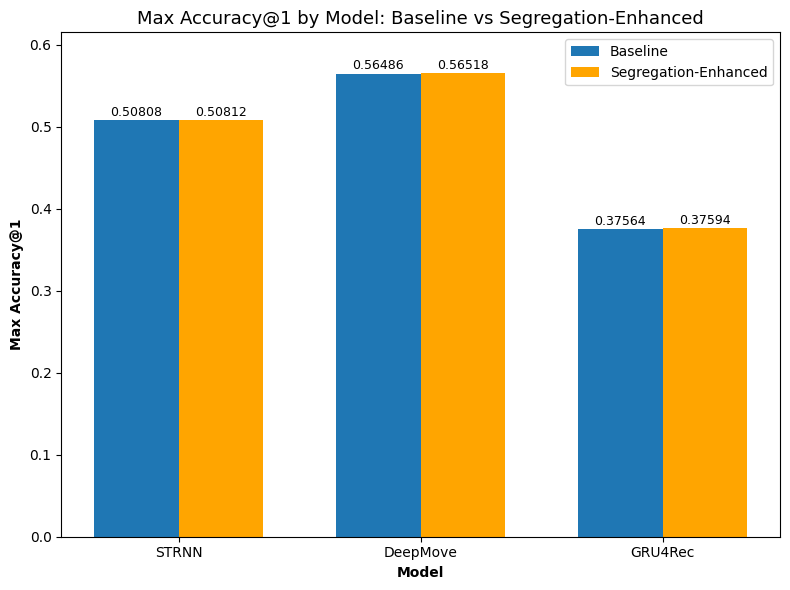

In [ ]:


paths = {
    "STRNN": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_base_training_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_training_history.csv"
    },
    "DeepMove": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_training_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_segregation_training_history.csv"
    },
    "GRU4Rec": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts/gru4rec_compat_full_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts/gru4rec_compat_full_history_segregation.csv"
    }
}


models = []
baseline_acc = []
segregation_acc = []

for model_name, files in paths.items():
    df_base = pd.read_csv(files["Baseline"])
    df_segr = pd.read_csv(files["Segregation"])

    models.append(model_name)
    baseline_acc.append(df_base["acc@1"].max())
    segregation_acc.append(df_segr["acc@1"].max())


x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, baseline_acc, width, label="Baseline", color="tab:blue")
bars2 = ax.bar(x + width/2, segregation_acc, width, label="Segregation-Enhanced", color="orange")

ax.set_ylabel("Max Accuracy@1", fontweight="bold")
ax.set_xlabel("Model", fontweight="bold")
ax.set_title("Max Accuracy@1 by Model: Baseline vs Segregation-Enhanced", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(baseline_acc + segregation_acc) + 0.05)
ax.legend()


for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.5f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


The results depicted in the line plots offer a nuanced understanding of how different sequential models respond to the integration of segregation-aware features in next-location prediction. For STRNN, the segregation-enhanced model initially lags behind the baseline but eventually converges and slightly surpasses it in later epochs, suggesting that while social context may introduce early training instability, it contributes to marginal improvements in long-term performance. DeepMove, on the other hand, shows a more stable and consistent learning trajectory when enhanced with segregation features, outperforming the baseline across several epochs and maintaining a slight lead by the end of training. This consistency highlights the capacity of attention-based architectures to selectively integrate complex contextual signals, making them more robust to heterogeneous mobility data. In contrast, GRU4Rec shows little to no benefit from the additional features. Both its baseline and enhanced versions fluctuate and decline after a few epochs, indicating that simpler RNN structures may lack the representational power needed to effectively utilize social context. Collectively, these results imply that while segregation-informed variables can incrementally enhance model performance, their impact depends heavily on the underlying architecture. Attention-driven models are better equipped to harness such contextual signals, whereas simpler models may require structural modifications to do so.

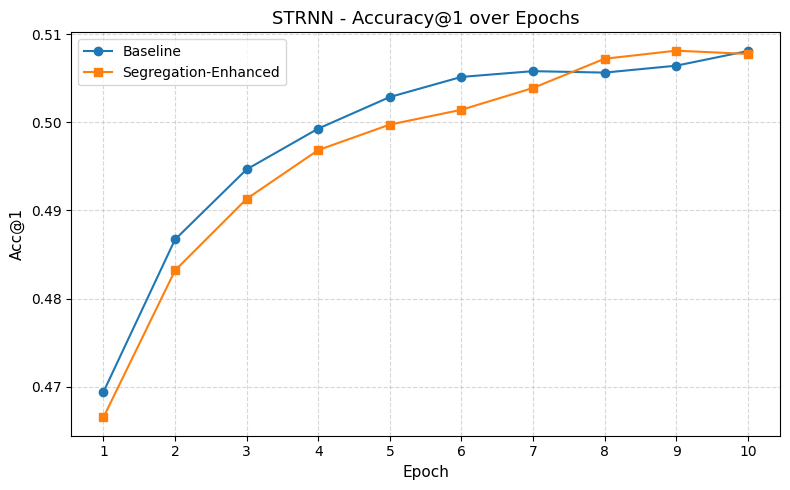

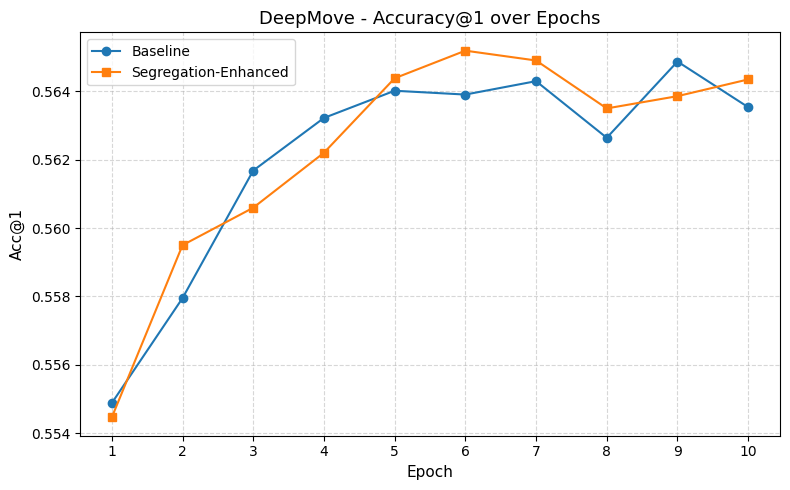

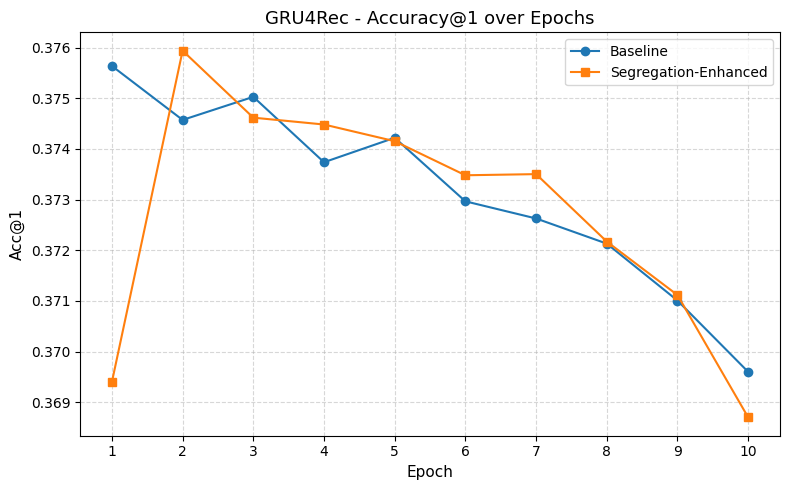

In [ ]:



paths = {
    "STRNN": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_base_training_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/strnn_segregation_training_history.csv"
    },
    "DeepMove": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_training_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/deepmove_segregation_training_history.csv"
    },
    "GRU4Rec": {
        "Baseline": "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts/gru4rec_compat_full_history.csv",
        "Segregation": "/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_ckpts/gru4rec_compat_full_history_segregation.csv"
    }
}


for model_name, files in paths.items():

    df_base = pd.read_csv(files["Baseline"])
    df_segr = pd.read_csv(files["Segregation"])


    if "epoch" not in df_base.columns:
        df_base["epoch"] = range(1, len(df_base) + 1)
    if "epoch" not in df_segr.columns:
        df_segr["epoch"] = range(1, len(df_segr) + 1)


    plt.figure(figsize=(8, 5))
    plt.plot(df_base["epoch"], df_base["acc@1"], label="Baseline", marker="o")
    plt.plot(df_segr["epoch"], df_segr["acc@1"], label="Segregation-Enhanced", marker="s")

    plt.title(f"{model_name} - Accuracy@1 over Epochs", fontsize=14)
    plt.xlabel("Epoch", fontsize=11)
    plt.ylabel("Acc@1", fontsize=11)
    plt.xticks(df_base["epoch"])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# References


Boodidhi, S. (2011). Using smoothing techniques to improve the performance of Hidden Markov’s Model. UNLV Theses, Dissertations, Professional Papers, and Capstones. doi:http://dx.doi.org/10.34917/2349611.

Daniel, J. and Martin, J. (2025). Speech and Language Processing: An Introduction to Natural Language Processing, Computational Linguistics, and Speech Recognition with Language Models, 3rd edition. [online] Available at: https://web.stanford.edu/~jurafsky/slp3.

Feng, J., Li, Y., Zhang, C., Sun, F., Meng, F., Guo, A. and Jin, D. (2018a). DeepMove. [online] GitHub. Available at: https://github.com/vonfeng/DeepMove/blob/master/README.md [Accessed 23 Aug. 2025].

Feng, J., Li, Y., Zhang, C., Sun, F., Meng, F., Guo, A. and Jin, D. (2018b). Deepmove: Predicting human mobility with attentional recurrent networks. Proceedings of the 2018 world wide web conference, pp.1459–1468. doi:https://doi.org/10.1109/tkde.2020.3006048.

Hidasi, B. (2023). Official PyTorch implementation of GRU4Rec. [online] GitHub. Available at: https://github.com/hidasib/GRU4Rec_PyTorch_Official [Accessed 23 Aug. 2025].

Järvinen, A. and Saarinen, E. (2021). POVERTY WATCH POVERTY WATCH REPORT FINLAND 2021. European Anti-Poverty Network Finland EAPN-Fin.

Jeong, J., Leconte, M. and Proutiere, A. (2016). Cluster-aided mobility predictions. IEEE INFOCOM 2016-the 35th annual IEEE international conference on computer communications.

Kang, J. (2025). Spatial Coordination of Electric Vehicle Adoption within the Urban Built Environment Using Machine Learning. Sustainable Futures, 10. doi:https://doi.org/10.1016/j.sftr.2025.100807.

Law, S., Neira, M., Tanu, N., Keel, T., Jie, G., Tang, J. and Hu, D. (2025). Lab Notebook 6: Introduction to Human Mobility Analysis. UCL Department of Geography.

Lin, Y., Xu, Y., Zhao, Z., Park, S., Su, S. and Ren, M. (2023). Understanding changing public transit travel patterns of urban visitors during COVID-19: A multi-stage study. Travel Behaviour and Society, 32. doi:https://doi.org/10.1016/j.tbs.2023.100587.

Liu, Q., Wu, S., Wang, L. and Tan, T. (2017). STRNN. [online] GitHub. Available at: https://github.com/yongqyu/STRNN/blob/master/README.md [Accessed 23 Aug. 2025].

Locomizer (2025). Audience Profiles – Human Location Data Enrichment and Analysis Manual. Locomizer.

Nahhas, R.W. (2025). 5.19 Box-Cox outcome transformation | Introduction to Regression Methods for Public Health Using R. [online] Bookdown.org. Available at: https://www.bookdown.org/rwnahhas/RMPH/mlr-boxcox.html?utm_source=chatgpt.com [Accessed 23 Aug. 2025].

Nezhadettehad, A., Zaslavsky, A., Abdur, R., Shaikh, S.A., Loke, S.W., Huang, G.-L. and Hassani, A. (2025). Predicting Next Useful Location With Context-Awareness: The State-Of-The-Art. ACM Transactions on Intelligent Systems and Technology.

Nilforoshan, H., Looi, W., Pierson, E., Villanueva, B., Fishman, N., Chen, Y., Sholar, J., Redbird, B., Grusky, D. and Leskovec, J. (2023). Human mobility networks reveal increased segregation in large cities. Nature, [online] 624(7992), pp.586–592. doi:https://doi.org/10.1038/s41586-023-06757-3.

OpenAI (2025a). just want to double confirm this is gru4rec_pytorch.py from github "import math import numpy as np import pandas as pd import torch from torch import autograd, nn from torch.autograd import Variable from collections import OrderedDict import time from torch.optim import Optimizer class IndexedAdagradM(Optimizer): def __init__(self, params, lr=0.05, momentum=0.0, eps=1e-6): if lr <= 0.0: raise ValueError("Invalid learning rate: {}".format(lr)) if momentum < 0.0: raise ValueError("Invalid momentum value: {}".format(momentum)). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a0cb1a-13ac-8330-acc5-aa6a9a71566e.

OpenAI (2025b). --- Imports --- import geopandas as gpd import osmnx as ox import networkx as nx import matplotlib.pyplot as plt from shapely.geometry import LineString, Point from collections import defaultdict from matplotlib.lines import Line2D from matplotlib.patches import Rectangle import numpy as np from tqdm import tqdm. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a737b2-0dfc-8332-ad80-10d1318ae304.

OpenAI (2025c). and this is the second part can you fix it? [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025d). can you do this by chunk ‘import pandas as pd import os # Base directory where the CSVs are located base_dir = “/content/drive/My Drive/Thesis/Data/Affinity Scores/Tabular Data” # Input CSVs to combine input_files = [ “scores_july.csv”, “scores_august.csv”, “scores_september.csv”] # Read and collect chunks combined_chunks = [] for file_name in input_files: file_path = os.path.join(base_dir, file_name) try: for chunk in pd.read_csv(file_path, chunksize=100_000): combined_chunks.append(chunk) print(f"✅ Loaded: {file_name}’) except Exception as e: print(f"❌ Failed to load {file_name}: {e}"). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985?src=history_search.

OpenAI (2025e). can you explain this code "import os import numpy as np import pandas as pd import torch import torch.nn as nn import torch.nn.functional as F from torch.utils.data import Dataset, DataLoader from tqdm import tqdm import random USE_EXTRA_FEATURES = False. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686f8bb2-3738-800a-8e91-afa0dd88b1c4.

OpenAI (2025f). can you explain this code "import os, numpy as np, pandas as pd train_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv’ test_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv’ save_dir = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/gru4rec_compat_artifacts’ os.makedirs(save_dir, exist_ok=True). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/g/g-p-686680eabe64819184138339ecc7252a/c/68a4c75b-c1c8-8328-82e7-d225c93698bf.

OpenAI (2025g). can you explain this code "import pandas as pd from tqdm import tqdm train_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv’ test_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv’ train_out = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_deepmove.csv’ test_out = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_deepmove.csv’ user_map_out = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/user_mapping.csv’ loc_map_out = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/loc_mapping.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/g/g-p-686680eabe64819184138339ecc7252a-locomizer-2/c/68a4c75b-c1c8-8328-82e7-d225c93698bf?project_id=g-p-686680eabe64819184138339ecc7252a&owner_user_id=user-kqBegCEM13wWkz7nsNb9IWdx.

OpenAI (2025h). can you fix this "import pandas as pd import numpy as np import matplotlib.pyplot as plt path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv’ chunksize = 100_000 col = ‘row_contacts_total’ total_rows = 0 rows_gt_zero = 0 min_v, max_v = None, None for chunk in pd.read_csv(path, usecols=[col], chunksize=chunksize, low_memory=False): [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a3174b-1e58-8322-a2e4-473d2e09686f.

OpenAI (2025i). Can you help me solve this code "import os import numpy as np import pandas as pd from scipy.spatial import cKDTree from pyproj import Transformer input_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_sorted_by_time.csv’ output_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/g/g-p-686680eabe64819184138339ecc7252a-locomizer-2/c/68b74c20-444c-8323-9be4-8de719c5f0e3.

OpenAI (2025j). can you help me with this code "city_center = (60.1695, 24.9354) center_point = gpd.GeoSeries([Point(city_center[1], city_center[0])], crs=‘EPSG:4326’).to_crs(3857) G = ox.graph_from_point(city_center, dist=5000, network_type=‘all’). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/g/g-p-686680eabe64819184138339ecc7252a-locomizer-2/c/68b74c20-444c-8323-9be4-8de719c5f0e3.

OpenAI (2025k). can you help me with this code ‘city_center = (60.1695, 24.9354) center_point = gpd.GeoSeries([Point(city_center[1], city_center[0])], crs=“EPSG:4326”).to_crs(3857) G = ox.graph_from_point(city_center, dist=5000, network_type=“all”) G_proj = ox.project_graph(G, to_crs=“EPSG:3857”) edges_gdf = ox.graph_to_gdfs(G_proj, nodes=False) routes = gpd.read_file(’/content/drive/My Drive/Thesis/Data/Human Mobility/routes_shortest_path.geojson") routes_web = routes.to_crs(3857) def add_north_arrow(ax, size=2500, xy=(0.1, 0.9)): x0, x1 = ax.get_xlim() y0, y1 = ax.get_ylim() dx = x1 - x0 dy = y1 - y0 x = x0 + dx * xy[0] y = y0 + dy * xy[1] tip = (x, y + size) left = (x - size * 0.4, y) right = (x + size * 0.4, y) arrow = plt.Polygon([tip, left, right], closed=True, color=‘black’, zorder=10) ax.add_patch(arrow). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/g/g-p-686680eabe64819184138339ecc7252a-locomizer-2/c/68b74c20-444c-8323-9be4-8de719c5f0e3.

OpenAI (2025l). can you make my code not crashing. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025m). can you update my code so that it is not based on the 92 days but users who have data at least 10 days on each month. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985.

OpenAI (2025n). from this code ‘import geopandas as gpd socioeconomic_data = pd.read_csv(’/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Income of Inhabitants.csv", encoding=‘ISO-8859-1’) helsinki_shp = gpd.read_file("/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Shapefile/PKS_postinumeroalueet_2023_manner_shp.shp") socioeconomic_data[‘Code’] = socioeconomic_data[‘Code’].astype(str) helsinki_shp[‘Posno’] = helsinki_shp[‘Posno’].astype(str). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985.

OpenAI (2025o). from this code ‘import geopandas as gpd socioeconomic_data = pd.read_csv(’/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Income of Inhabitants.csv", encoding=‘ISO-8859-1’) helsinki_shp = gpd.read_file("/content/drive/My Drive/Thesis/Data/Socioeconomic Data/Helsinki Shapefile/PKS_postinumeroalueet_2023_manner_shp.shp") socioeconomic_data[‘Code’] = socioeconomic_data[‘Code’].astype(str) helsinki_shp[‘Posno’] = helsinki_shp[‘Posno’].astype(str). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985.

OpenAI (2025p). from this file ‘“/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category.csv”’, this is what it looks like "Userid	lat	lon	timestamp	datetime	year. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025q). how to change the x-axis label ‘from matplotlib.ticker import FuncFormatter # --- Plot: Unique Users --- plt.figure(figsize=(10, 5)) plt.bar(labels, user_counts, color=“mediumseagreen”) plt.ylabel(“Number of Unique Users”, fontweight=“bold”) plt.title(“Unique Users per Dataset”, fontsize=14) plt.xticks(rotation=15, ha=“right”) plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f’{int(x):,}")) for i, val in enumerate(user_counts): plt.text(i, val + max(user_counts)*0.01, f"{val:,}", ha=‘center’, va=‘bottom’, fontsize=9) plt.tight_layout() plt.show(). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a3174b-1e58-8322-a2e4-473d2e09686f.

OpenAI (2025r). I forgot to mention that please make sure that userid in affinity dataset to be unique by only choosing the cat_id that have highest sum_scores. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025s). i just want to double confirm this is gru4rec_pytorch.py from github "import math import numpy as np import pandas as pd import torch from torch import autograd, nn from torch.autograd import Variable from collections import OrderedDict import time from torch.optim import Optimizer class IndexedAdagradM(Optimizer): def __init__(self, params, lr=0.05, momentum=0.0, eps=1e-6): if lr <= 0.0: raise ValueError("Invalid learning rate: {}".format(lr)) if momentum < 0.0: raise ValueError("Invalid momentum value: {}".format(momentum)). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a0cb1a-13ac-8330-acc5-aa6a9a71566e.

OpenAI (2025t). I still want to visualize it like this (based on rich/poor) but do it with every affinity profile with subplot of 7×2. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025u). I think i know the problem. so scores_june.csv has these columns only ‘[“cat_id”, “userid”, “sum_scores”]’ while the others have ‘userid cat_id number_of_signals sum_scores score_1 score_2 score_3 score_4 score_5 score_6 ... score_11 score_12 score_13 score_14 score_15 score_16 score_17 score_18 score_19 score_20’. I want the june to have columns like the others even though the file only have ‘cat_id’, ‘userid’, ‘sum_scores’]. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68938bbd-edfc-8320-b164-f1f4fdff5505.

OpenAI (2025v). i want to check the number of users, mobility data/gps points, and poi from each of these train_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv’ test_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/689e0da5-8950-8327-853f-6f29e75e62c8.

OpenAI (2025w). i want to check the number of users, mobility data/gps points, and poi from each of these train_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv’ test_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/689e0da5-8950-8327-853f-6f29e75e62c8.

OpenAI (2025x). I want to combine a text data into a single combined csv file in ‘parametric_score = pd.read_csv(’/content/drive/My Drive/Thesis/Data/PARAMETRIC SCORE/")". Inside PARAMETRIC SCORE, there are two folders of ‘loco_residents’ and ‘loco_workers_2’. Inside these two folders, there are folder 7 to 9, which represent july-september. The text files are inside the 7-9 folders in the format of ‘part-00000’ and I want you to combine all of them in the following directory: ‘/content/drive/My Drive/Thesis/Data/PARAMETRIC SCORE/combined_parametric_score.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985?src=history_search.

OpenAI (2025y). i want to execute this deepmove code "# --- Imports --- import torch import torch.nn as nn import torch.nn.functional as F import numpy as np from tqdm import tqdm import pandas as pd from math import radians, cos, sin, sqrt, atan2 from torch.utils.data import DataLoader, IterableDataset from scipy.spatial import cKDTree. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68921259-be6c-8321-8506-c2f8008987a7.

OpenAI (2025z). i want to execute this deepmove code "# --- Imports --- import torch import torch.nn as nn import torch.nn.functional as F import numpy as np from tqdm import tqdm import pandas as pd from math import radians, cos, sin, sqrt, atan2 from torch.utils.data import DataLoader, IterableDataset from scipy.spatial import cKDTree. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68921259-be6c-8321-8506-c2f8008987a7.

OpenAI (2025aa). i want to join my affinity profile (affinity) data to my mobility data (mobility_data). This is my mobility data ‘Userid	lat	lon	timestamp	datetime	year	month	dow	day	hour	minute	track_type	geometry 0	96b68764-26ff-4f58-a478-c774888a733a	60.255013	24.951094	1.720588e+09	2024/07/10	2024	7	3	10	5	14	cars_highway	POINT (24.951094 60.255013)’ and this is what my affinity profile looks like "userid	cat_id	number_of_signals	sum_scores	. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025ab). I want to load data from a gdrive directory: ‘/content/drive/My Drive/Colab Notebooks/Thesis/POI-20250718T041643Z-1-001/POI’. Inside these directories, there are POIs_2024-07, POIs_2024-08, POIs_2024-09 which represent poi data in helsinki july-sept 2024. inside these three files, there are POIs_for_JCD_Finland_(micodes).csv and POIs_for_JCD_Finland_(brands).csv. I need to combine all these two files from their respective month folders into Combined_POIs_for_JCD_Finland_(micodes).csv and Combined_POIs_for_JCD_Finland_(brands).csv in this directory ‘/content/drive/My Drive/Colab Notebooks/Thesis/POI-20250718T041643Z-1-001/POI/Combined_POI’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/
686f8bb2-3738-800a-8e91-afa0dd88b1c4.

OpenAI (2025ac). is this correct "# --- Install and import --- !pip install osmnx --quiet import pandas as pd import geopandas as gpd import networkx as nx import matplotlib.pyplot as plt import osmnx as ox from shapely.geometry import LineString, Point from shapely.ops import linemerge from tqdm import tqdm import os. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686a53fd-6188-800a-8fac-6668e718abfc.

OpenAI (2025ad). just to give you context, this is how i calculate these additional columns "# ===== Part 2: exposure + features on the sorted file ===== import pandas as pd, numpy as np, os from scipy.spatial import cKDTree from pyproj import Transformer # Inputs / outputs input_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_sorted_by_time.csv’ output_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv’. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68975877-ee34-832c-8235-cf92d3f48f0c.

OpenAI (2025ae). my code "import pandas as pd import numpy as np from tqdm import tqdm import random from math import radians, cos, sin, sqrt, atan2 from scipy.spatial. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/688e0ffe-bcec-832a-8d23-9f3851d21bd9.

OpenAI (2025af). okay can you now explain in details about this code "import pandas as pd import numpy as np from tqdm import tqdm import random from math import radians, cos, sin, sqrt, atan2 from scipy.spatial import cKDTree. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a4c75b-c1c8-8328-82e7-d225c93698bf.

OpenAI (2025ag). okay can you now explain in details about this code "import pandas as pd import numpy as np from tqdm import tqdm import random from math import radians, cos, sin, sqrt, atan2 from scipy.spatial import cKDTree city_center = (60.1695, 24.9354) mobility_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/mobility_with_economic_category_final.csv’ poi_path = ‘/content/drive/My Drive/Thesis/Data/POI/Combined_POI/Combined_POIs_for_JCD_Finland_(micodes).csv’ train_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/train_inductive.csv’ test_path = ‘/content/drive/My Drive/Thesis/Data/Human Mobility/test_inductive.csv’ chunk_size = 100_000. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a4c75b-c1c8-8328-82e7-d225c93698bf.

OpenAI (2025ah). okay its getting better. and now i want the two plots to be closer and the gap between label/bars are increased. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a3174b-1e58-8322-a2e4-473d2e09686f.

OpenAI (2025ai). okay now all the files are in csv format, I want to combine all of them into one single tabular data. starting with Human Mobility data. Can you combine all the csv files in /content/drive/My Drive/Thesis/Data/Human Mobility? inside Human Mobility folder contains July, August, September Folder where inside of them contains date as well. And inside all of these dates, the csv files are stored. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985.

OpenAI (2025aj). okay now from this code "# --- Imports --- import geopandas as gpd import osmnx as ox import networkx as nx import matplotlib.pyplot as plt from shapely.geometry import LineString, Point from collections import defaultdict from matplotlib.lines import Line2D from matplotlib.patches import Rectangle import numpy as np from tqdm import tqdm # ---------- Helpers ---------- def add_north_arrow(ax, size=750, xy=(0.10, 0.90)): ‘“‘Triangle north arrow drawn in DATA coords (EPSG:3857).’”’ x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim(). [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68ab1db3-009c-8326-bdd8-558e92cdb544.

OpenAI (2025ak). Okay the next step is I want to compile all the csv files of affinity profiles in "/content/drive/My Drive/Thesis/Data/Affinity Scores/". inside that directory, there are scores 7, scores 8, scores 9, which represent july, august, september. I want to compile all the csv files per month and also an overall that combines for 3 whole month. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68487cf7-5e84-800a-a95a-dc3693289985.

OpenAI (2025al). okay what should i adjust from this part "import pandas as pd import torch from math import radians, sin, cos, sqrt, atan2 from tqdm import tqdm import os # --- Parameters ---. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68975877-ee34-832c-8235-cf92d3f48f0c.

OpenAI (2025am). so this code sorted my dataset right "# ===== Part 1: write a time-sorted file ===== import pandas as pd, os, glob from datetime import timedelta. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/6894c121-9034-8330-8864-1b87f3866783.

OpenAI (2025an). there are some label that is still have extra space such automative repair and museums. and some ofthe labels are still so close between one another. perhaps you could decrease the font size or increase the gap between labels/bars. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a3174b-1e58-8322-a2e4-473d2e09686f.

OpenAI (2025ao). this is from "#! /usr/bin/env python import os import datetime import math import tqdm import numpy as np import torch import torch.nn as nn import torch.nn.functional as F from torch.autograd import Variable import data_loader # Parameters # ================================================== ftype = torch.cuda.FloatTensor ltype = torch.cuda.LongTensor # Data loading params train_file = ‘./prepro_train_50.txt’ valid_file = ‘./prepro_valid_50.txt’ test_file = ‘./prepro_test_50.txt’ # Model Hyperparameters dim = 13 # dimensionality ww = 360 # winodw width (6h) up_time = 560632.0 # min lw_time = 0. up_dist = 457.335 # km lw_dist = 0. reg_lambda = 0.1. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/686f8bb2-3738-800a-8e91-afa0dd88b1c4.

OpenAI (2025ap). wait i just realized something so i have done this code "!pip install osmnx --quiet import pandas as pd import geopandas as gpd import networkx as nx import matplotlib.pyplot as. [online] ChatGPT (August, 20 2025 Version). Available at: https://chatgpt.com/c/68a5fa71-40e4-832b-aca9-f5998ccda216.

Reifman, A. and Keyton , K. (2012). Encyclopedia of Research Design. Sage Research Methods .

Statistics Finland (2024). Median earnings for regular working hours of full-time wage and salary earners in central government were EUR 4,112 in 2023 | Statistics Finland. [online] Statistics Finland. Available at: https://stat.fi/en/publication/clmklvb9f4yux0cunww2id9hh.

Wang, X. (2025). Into-the-Unknown. [online] GitHub. Available at: https://github.com/xlwang233/Into-the-Unknown/tree/main/calliper/ [Accessed 23 Aug. 2025].

Wang, X., Cheng, T., Law, S., Zeng, Z., Ilyankou, I., Liu, J., Yin, L., Huang, W. and Jongwiriyanura, N. (2025). Into the Unknown: Applying Inductive Spatial-Semantic Location Embeddings for Predicting Individuals’ Mobility Beyond Visited Places. arXiv preprint arXiv:2506.14070.

Wong, D.W. (2008). Ecological Fallacy. In: Encyclopedia of Geographic Information Science. [online] SAGE Publications, Inc. doi:https://doi.org/10.4135/9781412953962.n53.

